# 08 — Can we do better? A prototype for INFLECTIONS

**Objective.** *"improve performance …
i want the get in to flag when prices do infact move upwards
significantly, and get out to call the top (quite near the tops) —
especially for larger price moments that are really retail driven.
also … perhaps can we make it so like we can try and predict price
INFLECTIONS quite well? … after a signal we get a large change in
price — regardless of direction … perhaps make it so like we can also
see qualitative (if there is an inflection, use AI to check the posts
and give a qualitative view on what is happening)."*

**This notebook changes nothing.** It reads the shipped stores, builds
its own labels and its own walk-forward, and reports. No file in
`analytics/`, `src/` or `config/` is touched — adoption, if any, is a
separate decision taken after reading this.

## The four decisions this notebook was given

| Question | Answer | Where it bites |
|---|---|---|
| What is an "inflection"? | **Both** a big move either way **and** a true turning point, built separately and compared | §1 |
| What is "calling the top"? | **Captures half the drawdown** — timing-agnostic | §1.3 |
| What may change? | Everything **except** the text-free boundary and walk-forward discipline | §3 |
| The 2023–25 data gap? | **Proceed, label the results provisional** | §0.2 |

## What is fixed, and why it has to be

* **Walk-forward.** Every number below is produced by a model fitted on
  years strictly before the year it scores. Without this, "we improved
  the hit rate" means only "we found a curve that fits what already
  happened", which is not a claim anyone can trade.
* **Text-free.** Nothing here writes post text anywhere. §5 sends text
  to the gateway and stores only the model's paraphrase, the same
  boundary the AI Pulse works under.

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Run from the repo root whether this is executed as a script from the
# root or as a notebook from notebooks/ - every path below is relative to
# the root, the same convention notebook 05 uses.
ROOT = (os.path.dirname(os.getcwd())
        if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())
os.chdir(ROOT)
sys.path.insert(0, ROOT)

from analytics import ml_detector as mld                      # noqa: E402
from analytics.euphoria import build_all_series               # noqa: E402
from analytics.euphoria_phases import build_day_frame         # noqa: E402
from analytics.loaders import (load, THEME_COUNTS,            # noqa: E402
                               THEME_SENT, TICKER_COUNTS,
                               TICKER_SENT)

NAVY, BLUE, SKY, GREY = "#0A2540", "#2E6FDB", "#9DB9DC", "#6B7280"
GREEN, RED, LIGHT = "#1F6F5C", "#B4553F", "#E8EBEF"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.grid": True, "grid.color": LIGHT,
    "axes.edgecolor": LIGHT, "axes.axisbelow": True,
    "figure.facecolor": "white", "text.color": NAVY,
    "axes.labelcolor": NAVY, "xtick.color": GREY, "ytick.color": GREY,
})
OUT = os.path.join("docs", "research")
os.makedirs(OUT, exist_ok=True)
RESULTS: dict = {"built": None, "sections": {}}
T0 = time.time()
print("notebook 08 — inflection prototype")

notebook 08 — inflection prototype


## 0.1 The stores, exactly as shipped

In [2]:
prices = pd.read_parquet("data/prices/prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
sym_by = {es.name: es.symbol for es in series}
episodes = pd.read_parquet("data/processed/episodes.parquet")
for c in ("trough", "peak", "bust_date"):
    episodes[c] = pd.to_datetime(episodes[c])
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])

frame = build_day_frame(series, pxmap, episodes, counts, sents)
cand = mld.attach_price_features(mld.candidate_frame(frame), series, pxmap)
CROWD = [c for c in mld.DESK_ML_BANK if c not in mld.PRICE_FEATURES]
print(f"{len(cand):,} scored name-days · {cand['name'].nunique()} names · "
      f"{cand['year'].min()}–{cand['year'].max()} · {len(episodes)} episodes")
print(f"crowd features ({len(CROWD)}): {', '.join(CROWD)}")

58,790 scored name-days · 49 names · 2017–2026 · 443 episodes
crowd features (9): attention_accel, hype_ratio, bull_inflection, influx_speed, attention_convexity, e1, e3, bull_level, bull_persist


## 0.2 The gap, stated once so every number below is read correctly

Scored coverage collapses from 2023Q2 and only recovers in 2026Q1
(`docs/RESEARCH_RECORD.md`). Everything in this notebook is
therefore measured on **a mania (2021–22) and a recovery (2026)** with
the flat middle years almost entirely missing. Two consequences, both
real:

1. A gain measured here may be a gain **on those two regimes only**.
2. The walk-forward folds for 2024 and 2025 are nearly empty, so the
   year-by-year table will look erratic there. That is coverage, not
   instability in the model.

The honest reading of anything below is *"this is worth re-running
after the backfill"*, not *"this is the new number"*.

In [3]:
_cov = (cand.groupby("year")
        .agg(days=("date", "size"), names=("name", "nunique")))
_cov["share_of_days"] = (_cov["days"] / _cov["days"].sum()).round(3)
print(_cov.to_string())
RESULTS["sections"]["coverage"] = _cov.reset_index().to_dict("records")

       days  names  share_of_days
year                             
2017   2457     24          0.042
2018   8190     28          0.139
2019   7293     26          0.124
2020   9492     35          0.161
2021  12534     40          0.213
2022   9809     40          0.167
2023   2638     29          0.045
2024    538      5          0.009
2025    337      5          0.006
2026   5502     44          0.094


# 1 — The labels

Three new gradings, all built here, none of them in the pipeline.

**The rule every label obeys:** a label may look forward (that is what
a label is), but any *threshold* used to decide "large" must be
computed from data available **before** the day being labelled.
Otherwise the label smuggles the test period into its own definition
and every score afterwards is inflated. This is the single easiest
mistake to make in this notebook and the reason for the trailing
windows below.

In [4]:
HZ = 21                 # forward horizon, trading days
TURN_LOOKAHEAD = 10     # a turning point must land within this many days
TRAIL_Y = 2             # years of trailing history for "what is large"

wide = prices.pivot_table(index="date", columns="symbol",
                          values="px_last").sort_index()
fwd = wide.shift(-HZ) / wide - 1.0
mkt = fwd.median(axis=1)                     # the date-matched control
excess = fwd.sub(mkt, axis=0)


def _name_px(nm):
    return pxmap.get(sym_by.get(nm))

## 1.1 Label A — a big move either way

*"after a signal we get a large change in price — regardless of
direction"*, taken literally.

`y_move` = 1 when the name's **excess** move over the next 21 trading
days is larger in magnitude than its own recent normal. "Its own
recent normal" is the 90th percentile of `|excess|` over the trailing
two years **for that name**, recomputed every day — so a permanently
volatile name does not score an inflection every day, and a quiet name
is not held to a meme stock's bar.

Excess, not raw: a raw move is contaminated by whatever the whole
market did that month, which is exactly the trap the max-performance
work fell into in August.

In [5]:
def build_move_label(sym: str) -> pd.DataFrame:
    if sym not in excess.columns:
        return pd.DataFrame()
    ex = excess[sym].dropna()
    if len(ex) < 260:
        return pd.DataFrame()
    a = ex.abs()
    # TRAILING percentile, shifted by one day: the bar for "large" on day
    # t uses only days strictly before t.
    bar = (a.rolling(f"{TRAIL_Y * 365}D", min_periods=120)
           .quantile(0.90).shift(1))
    out = pd.DataFrame({"excess": ex, "bar": bar}).dropna()
    out["y_move"] = (out["excess"].abs() >= out["bar"]).astype(int)
    out["move_dir"] = np.sign(out["excess"]).astype(int)
    return out


MOVE = {}
for nm, sym in sym_by.items():
    d = build_move_label(sym)
    if len(d):
        MOVE[nm] = d
print(f"label A built for {len(MOVE)} names")

label A built for 58 names


## 1.2 Label B — a true turning point

The harder target, and the one a desk actually trades. A **turning
point** is a day the price stops going one way and goes the other:
formally, day *e* is an extremum when its close is the max (or min) of
the 43-day window centred on it, **and** the move away from it over
the following 21 days is at least `TURN_MIN` in excess terms — that
second condition is what separates a reversal from a flat wobble that
happens to contain a local maximum.

`y_turn(t) = 1` when an extremum falls in the **next 10 days**, so the
label is something a signal on day *t* could actually be early for.

In [6]:
TURN_WIN = 21           # half-window for the extremum test
TURN_MIN = 0.08         # the move away must be at least this big (excess)


def build_turn_label(nm: str, sym: str) -> pd.DataFrame:
    px = _name_px(nm)
    if px is None or sym not in excess.columns:
        return pd.DataFrame()
    px = px.dropna()
    if len(px) < 260:
        return pd.DataFrame()
    hi = px.rolling(2 * TURN_WIN + 1, center=True).max()
    lo = px.rolling(2 * TURN_WIN + 1, center=True).min()
    ex = excess[sym].reindex(px.index)
    is_peak = (px >= hi) & (ex <= -TURN_MIN)      # top, then it falls
    is_trough = (px <= lo) & (ex >= TURN_MIN)     # bottom, then it rises
    extremum = (is_peak | is_trough).fillna(False)
    # y_turn(t) = an extremum lands in (t, t+TURN_LOOKAHEAD]
    fut = (extremum.iloc[::-1].rolling(TURN_LOOKAHEAD, min_periods=1)
           .max().iloc[::-1].shift(-1).fillna(0))
    return pd.DataFrame({"y_turn": fut.astype(int),
                         "turn_up": is_trough.astype(int),
                         "turn_down": is_peak.astype(int)},
                        index=px.index)


TURN = {}
for nm, sym in sym_by.items():
    d = build_turn_label(nm, sym)
    if len(d):
        TURN[nm] = d
print(f"label B built for {len(TURN)} names")

label B built for 58 names


## 1.3 Label C — GET OUT regraded: does the call capture half the drop?

The desk chose a **timing-agnostic** grading: a GET OUT is a hit when
the name falls, from the call, by at least **half of the episode's
eventual peak-to-trough drawdown**. This rewards being *useful* over
being *punctual* — a call three days after the exact top that still
gets you out above most of the fall is a good call, and the old
"within N days of the peak" grading scored it zero.

Note what this does NOT do: it does not make GET OUT easier. A call
made too early (before the run has finished) captures little of the
drop, and a call made late captures nothing.

In [7]:
DD_SHARE = 0.50          # fraction of the drawdown a call must capture
DD_WINDOW = 90           # days after the peak the drawdown is measured in


def build_halfdd_label(nm: str) -> pd.DataFrame:
    px = _name_px(nm)
    eps = episodes[episodes["name"] == nm]
    if px is None or not len(eps):
        return pd.DataFrame()
    px = px.dropna()
    y = pd.Series(0, index=px.index, dtype=int)
    cap = pd.Series(np.nan, index=px.index, dtype=float)
    for r in eps.itertuples():
        end = r.peak + pd.Timedelta(days=DD_WINDOW)
        after_peak = px.loc[r.peak:end]
        if len(after_peak) < 5:
            continue
        full_drop = float(px.loc[r.peak] - after_peak.min())
        if full_drop <= 0:
            continue
        # a call can be made any time from the trough through the bust
        span = px.loc[r.trough:end]
        for t, p_t in span.items():
            rest = px.loc[t:end]
            if len(rest) < 2:
                continue
            captured = float(p_t - rest.min())
            cap.loc[t] = captured / full_drop
            if captured >= DD_SHARE * full_drop:
                y.loc[t] = 1
    return pd.DataFrame({"y_halfdd": y, "dd_captured": cap})


HALF = {}
for nm in sym_by:
    d = build_halfdd_label(nm)
    if len(d):
        HALF[nm] = d
print(f"label C built for {len(HALF)} names")

label C built for 47 names


## 1.4 Attaching the labels, and what they cost in base rate

In [8]:
lab = cand[["name", "date", "year"]].copy()


def _attach(store: dict, col: str):
    vals = []
    for nm, g in lab.groupby("name", sort=False):
        d = store.get(nm)
        if d is None or col not in d:
            vals.append(pd.Series(np.nan, index=g.index))
        else:
            vals.append(pd.Series(
                d[col].reindex(g["date"]).to_numpy(), index=g.index))
    return pd.concat(vals).reindex(lab.index)


lab["y_move"] = _attach(MOVE, "y_move")
lab["move_dir"] = _attach(MOVE, "move_dir")
lab["y_turn"] = _attach(TURN, "y_turn")
lab["y_halfdd"] = _attach(HALF, "y_halfdd")
lab["dd_captured"] = _attach(HALF, "dd_captured")
for c in ("y_onset", "y_top"):
    lab[c] = cand[c].to_numpy()

D = pd.concat([cand.drop(columns=["y_onset", "y_top"]),
               lab[["y_move", "move_dir", "y_turn", "y_halfdd",
                    "dd_captured", "y_onset", "y_top"]]], axis=1)
D = D.dropna(subset=["y_move", "y_turn"]).copy()
for c in ("y_move", "y_turn", "y_halfdd", "y_onset", "y_top"):
    D[c] = D[c].fillna(0).astype(int)
print(f"{len(D):,} labelled name-days\n")

BASE = pd.DataFrame({
    "label": ["y_onset (GET IN, shipped)", "y_top (GET OUT, shipped)",
              "y_move (A: big move either way)",
              "y_turn (B: turning point in 10d)",
              "y_halfdd (C: captures half the drop)"],
    "base_rate": [D[c].mean() for c in
                  ("y_onset", "y_top", "y_move", "y_turn", "y_halfdd")],
    "positives": [int(D[c].sum()) for c in
                  ("y_onset", "y_top", "y_move", "y_turn", "y_halfdd")],
})
BASE["one_in"] = (1 / BASE["base_rate"]).round(1)
print(BASE.to_string(index=False))
RESULTS["sections"]["base_rates"] = BASE.to_dict("records")

38,783 labelled name-days

                               label  base_rate  positives  one_in
           y_onset (GET IN, shipped)   0.111131       4310     9.0
            y_top (GET OUT, shipped)   0.098523       3821    10.1
     y_move (A: big move either way)   0.137534       5334     7.3
    y_turn (B: turning point in 10d)   0.052162       2023    19.2
y_halfdd (C: captures half the drop)   0.158497       6147     6.3


**Read the base rate before the AUROC.** A label that fires on a third
of all days is easy to "predict" and worth little; a label that fires
on 2% of days is hard and worth a lot. Every score later in this
notebook is quoted as **lift over its own base rate** for exactly this
reason — an AP of 0.20 is superb against a 2% base and useless against
a 30% one.

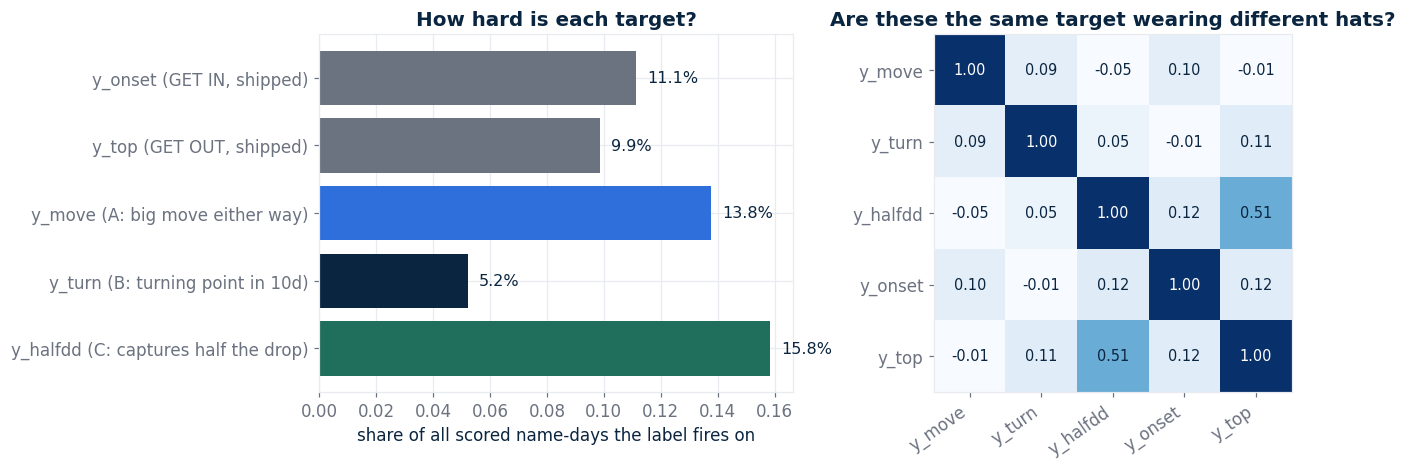

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.barh(BASE["label"], BASE["base_rate"], color=[GREY, GREY, BLUE, NAVY,
                                                 GREEN])
for i, v in enumerate(BASE["base_rate"]):
    ax.text(v + 0.004, i, f"{v:.1%}", va="center", fontsize=10.5)
ax.set_xlabel("share of all scored name-days the label fires on")
ax.set_title("How hard is each target?")
ax.invert_yaxis()

ax = axes[1]
ov = pd.DataFrame({k: D[k] for k in ("y_move", "y_turn", "y_halfdd",
                                     "y_onset", "y_top")}).corr()
im = ax.imshow(ov.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(ov)), ov.columns, rotation=35, ha="right")
ax.set_yticks(range(len(ov)), ov.columns)
for i in range(len(ov)):
    for j in range(len(ov)):
        ax.text(j, i, f"{ov.values[i, j]:.2f}", ha="center", va="center",
                fontsize=9.5,
                color="white" if ov.values[i, j] > 0.55 else NAVY)
ax.grid(False)
ax.set_title("Are these the same target wearing different hats?")
fig.tight_layout()
plt.show()

# 2 — Baseline: how the shipped features score on the new targets

Before searching for anything better, measure what we already have.
The walk-forward below is written **in this notebook** rather than
imported, so nothing in the pipeline is touched and the fold logic is
visible on the page: for each year Y, fit on every year `< Y`, score
Y blind, and never look at Y while fitting.

In [10]:
from sklearn.metrics import average_precision_score, roc_auc_score  # noqa: E402


def walk_forward(df: pd.DataFrame, feats: list, label: str,
                 fit_maker, min_train: int = 400) -> pd.DataFrame:
    """Fit on years < Y, score Y. Returns one row per scored name-day."""
    out = []
    years = sorted(df["year"].unique())
    for y in years:
        tr = df[df["year"] < y]
        te = df[df["year"] == y]
        if len(tr) < min_train or not len(te) or tr[label].sum() < 12:
            continue
        try:
            s = fit_maker(label)(tr, te, feats)
        except Exception as e:                       # noqa: BLE001
            print(f"   [{label} {y}] fit failed: {e}")
            continue
        out.append(te.assign(score=np.asarray(s)))
    return pd.concat(out) if out else pd.DataFrame()


def score_report(scored: pd.DataFrame, label: str) -> dict:
    if not len(scored) or scored[label].nunique() < 2:
        return {"n": len(scored), "AP": np.nan, "AUROC": np.nan,
                "base": np.nan, "AP_lift": np.nan}
    y = scored[label].to_numpy()
    s = scored["score"].to_numpy()
    base = float(y.mean())
    ap = float(average_precision_score(y, s))
    return {"n": len(scored), "AP": ap,
            "AUROC": float(roc_auc_score(y, s)), "base": base,
            "AP_lift": ap / base if base else np.nan}


LABELS = [("y_move", "A · big move either way"),
          ("y_turn", "B · turning point in 10d"),
          ("y_halfdd", "C · captures half the drop"),
          ("y_onset", "GET IN (shipped grading)"),
          ("y_top", "GET OUT (shipped grading)")]

t = time.time()
BASELINE = {}
for lb, nice in LABELS:
    sc = walk_forward(D, CROWD, lb, mld.make_ens_fit)
    BASELINE[lb] = score_report(sc, lb)
    BASELINE[lb]["label"] = nice
    print(f"  {nice:<32} AP {BASELINE[lb]['AP']:.4f}  "
          f"lift {BASELINE[lb]['AP_lift']:.2f}x  "
          f"AUROC {BASELINE[lb]['AUROC']:.4f}")
print(f"({time.time() - t:.0f}s)")
RESULTS["sections"]["baseline_crowd"] = BASELINE

  A · big move either way          AP 0.1388  lift 1.01x  AUROC 0.4941


  B · turning point in 10d         AP 0.0573  lift 1.06x  AUROC 0.5175


  C · captures half the drop       AP 0.1887  lift 1.16x  AUROC 0.5354


  GET IN (shipped grading)         AP 0.1371  lift 1.23x  AUROC 0.5535


  GET OUT (shipped grading)        AP 0.1200  lift 1.18x  AUROC 0.5423
(16s)


**The shipped crowd bank, scored on the new targets.** This is the
number every later section has to beat. If a new label shows a big
lift here it means the crowd features already carry that signal and we
simply were not asking for it — which would be the cheapest possible
win.

# 3 — The search

Scope, per the desk: everything except the text-free boundary and
walk-forward. Three axes, run for every label:

* **feature bank** — crowd-only, crowd+price, and crowd+price plus the
  candidate additions defined below;
* **model family** — logistic regression, monotone GBM, and the
  rank-average ensemble that ships today;
* **target** — the five labels above.

Nothing is adopted in this section. It produces a table.

## 3.1 Candidate new features

Four additions, each with a reason to exist rather than a hope:

* `att_vol_21` — how *unstable* attention has been, not how high. A
  crowd arguing with itself looks different from a crowd agreeing, and
  neither the level nor the trend measures capture that.
* `bull_dispersion` — the spread of daily mood over 21 days. High
  dispersion is disagreement, and disagreement is what precedes a
  reversal in the folklore this project is testing.
* `att_x_mood` — attention × mood, the interaction. Loud-and-bullish
  and loud-and-bearish are different states; two additive terms cannot
  say that.
* `breadth_chg` — change in how many sources carry the name. A move
  spreading across forums is different from one forum shouting.

All four are computed **per name from its own history** and none of
them touches price.

In [11]:
def add_candidates(df: pd.DataFrame) -> pd.DataFrame:
    d = df.sort_values(["name", "date"]).copy()
    g = d.groupby("name", sort=False)
    d["att_vol_21"] = g["hype_raw"].transform(
        lambda s: s.rolling(21, min_periods=8).std())
    d["bull_dispersion"] = g["bull_level"].transform(
        lambda s: s.rolling(21, min_periods=8).std())
    d["att_x_mood"] = d["e1"] * d["bull_level"]
    if "source_breadth" in d:
        d["breadth_chg"] = g["source_breadth"].transform(
            lambda s: s - s.rolling(21, min_periods=8).mean())
    else:
        d["breadth_chg"] = 0.0
    for c in ("att_vol_21", "bull_dispersion", "att_x_mood",
              "breadth_chg"):
        d[c] = d[c].fillna(0.0)
    return d.loc[df.index]


D = add_candidates(D)
NEW_FEATS = ["att_vol_21", "bull_dispersion", "att_x_mood", "breadth_chg"]
BANKS = {
    "crowd only (shipped)": CROWD,
    "crowd + price (shipped desk)": mld.DESK_ML_BANK,
    "crowd + new": CROWD + NEW_FEATS,
    "crowd + price + new": mld.DESK_ML_BANK + NEW_FEATS,
}
FAMILIES = {"logit": mld.make_logit_fit, "monotone GBM": mld.make_gbm_fit,
            "ensemble (shipped)": mld.make_ens_fit}
print(f"{len(BANKS)} banks x {len(FAMILIES)} families x {len(LABELS)} "
      f"labels = {len(BANKS) * len(FAMILIES) * len(LABELS)} walk-forwards")

4 banks x 3 families x 5 labels = 60 walk-forwards


In [12]:
t = time.time()
rows = []
for lb, nice in LABELS:
    for bname, feats in BANKS.items():
        for fname, maker in FAMILIES.items():
            sc = walk_forward(D, feats, lb, maker)
            r = score_report(sc, lb)
            r.update({"label": nice, "label_col": lb, "bank": bname,
                      "family": fname})
            rows.append(r)
    print(f"  {nice} done ({time.time() - t:.0f}s)")
SEARCH = pd.DataFrame(rows)
RESULTS["sections"]["search"] = SEARCH.to_dict("records")
print(f"\ntournament finished in {time.time() - t:.0f}s")

  A · big move either way done (21s)


  B · turning point in 10d done (47s)


  C · captures half the drop done (77s)


  GET IN (shipped grading) done (106s)


  GET OUT (shipped grading) done (136s)

tournament finished in 136s


In [13]:
piv = SEARCH.pivot_table(index=["label", "bank"], columns="family",
                         values="AP_lift").round(2)
print("AP LIFT over each label's own base rate (higher is better)\n")
print(piv.to_string())

AP LIFT over each label's own base rate (higher is better)

family                                                   ensemble (shipped)  logit  monotone GBM
label                      bank                                                                 
A · big move either way    crowd + new                                 1.04   0.96          1.03
                           crowd + price (shipped desk)                0.97   0.91          1.03
                           crowd + price + new                         1.01   0.93          1.03
                           crowd only (shipped)                        1.01   0.91          1.00
B · turning point in 10d   crowd + new                                 1.36   1.27          1.21
                           crowd + price (shipped desk)                1.36   1.19          1.19
                           crowd + price + new                         1.38   1.32          1.24
                           crowd only (shipped)                    

In [14]:
best = (SEARCH.sort_values("AP_lift", ascending=False)
        .groupby("label_col").head(1)
        .set_index("label_col"))
shipped = SEARCH[(SEARCH["bank"] == "crowd only (shipped)")
                 & (SEARCH["family"] == "ensemble (shipped)")
                 ].set_index("label_col")
cmp = pd.DataFrame({
    "shipped_lift": shipped["AP_lift"].round(2),
    "best_lift": best["AP_lift"].round(2),
    "best_bank": best["bank"], "best_family": best["family"],
    "gain": (best["AP_lift"] - shipped["AP_lift"]).round(2),
})
print(cmp.to_string())
RESULTS["sections"]["best_vs_shipped"] = cmp.reset_index().to_dict("records")

           shipped_lift  best_lift                     best_bank         best_family  gain
label_col                                                                                 
y_halfdd           1.16       1.96  crowd + price (shipped desk)  ensemble (shipped)  0.80
y_move             1.01       1.04                   crowd + new  ensemble (shipped)  0.03
y_onset            1.23       2.63           crowd + price + new               logit  1.40
y_top              1.18       2.43  crowd + price (shipped desk)  ensemble (shipped)  1.25
y_turn             1.06       1.38           crowd + price + new  ensemble (shipped)  0.31


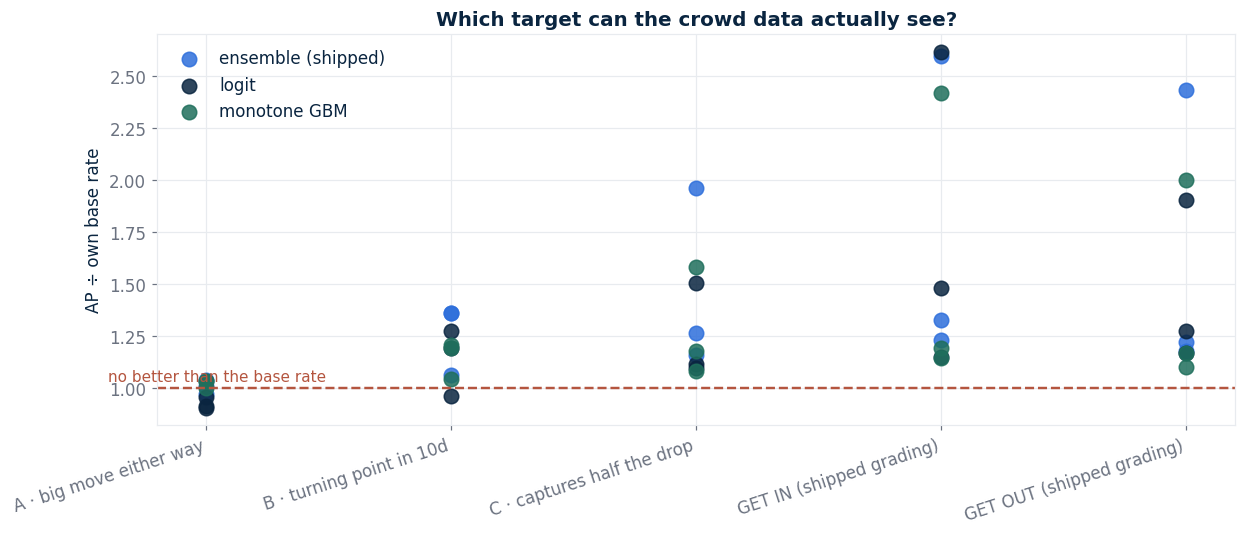

In [15]:
fig, ax = plt.subplots(figsize=(11.5, 5.0))
_p = SEARCH[SEARCH["bank"] != "crowd + price + new"]
for i, (fam, g) in enumerate(_p.groupby("family")):
    ax.scatter(g["label"], g["AP_lift"], s=90, alpha=0.85,
               color=[BLUE, NAVY, GREEN][i % 3], label=fam)
ax.axhline(1.0, color=RED, lw=1.6, ls="--")
ax.text(-0.4, 1.03, "no better than the base rate", color=RED,
        fontsize=10)
ax.set_ylabel("AP ÷ own base rate")
ax.set_title("Which target can the crowd data actually see?")
ax.legend(frameon=False)
plt.xticks(rotation=18, ha="right")
fig.tight_layout()
plt.show()

## 3.2 How much of this is the crowd, and how much is just price?

**The most important table in this notebook.** Every headline gain
above needs splitting, because two very different things are on offer:

* adding **four new crowd features** — price-free, so adoptable inside
  the rule the desk deliberately keeps;
* adding **price** to detectors that currently never see it — which
  would raise the numbers a lot and change what the project is
  *claiming*, from "the crowd predicts this" to "partly, price
  predicts price".

The second is not free even though it is bigger.

In [16]:
BYBANK = (SEARCH.groupby(["label", "bank"])["AP_lift"].max()
          .unstack()[["crowd only (shipped)", "crowd + new",
                      "crowd + price (shipped desk)",
                      "crowd + price + new"]].round(2))
SPLIT = pd.DataFrame({
    "shipped (crowd only)": BYBANK["crowd only (shipped)"],
    "+ new crowd features": (BYBANK["crowd + new"]
                             - BYBANK["crowd only (shipped)"]).round(2),
    "+ price (rule change)": (BYBANK["crowd + price (shipped desk)"]
                              - BYBANK["crowd only (shipped)"]).round(2),
    "best available": BYBANK.max(axis=1),
})
print(SPLIT.to_string())
RESULTS["sections"]["gain_split"] = SPLIT.reset_index().to_dict("records")

                            shipped (crowd only)  + new crowd features  + price (rule change)  best available
label                                                                                                        
A · big move either way                     1.01                  0.03                   0.02            1.04
B · turning point in 10d                    1.06                  0.30                   0.30            1.38
C · captures half the drop                  1.16                  0.11                   0.80            1.96
GET IN (shipped grading)                    1.23                  0.25                   1.38            2.63
GET OUT (shipped grading)                   1.18                  0.10                   1.25            2.43


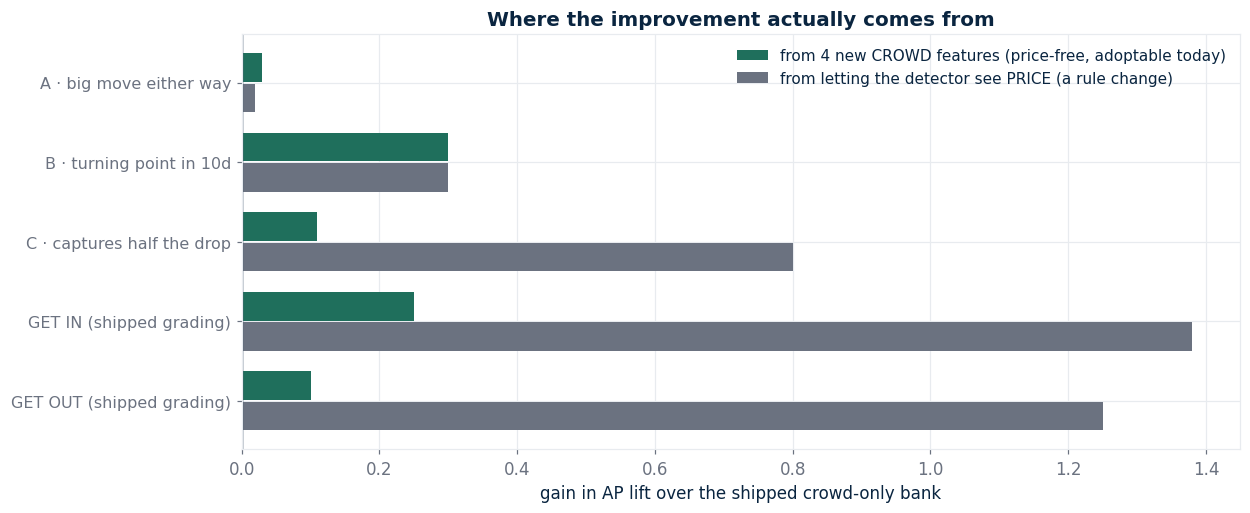

In [17]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
_y = np.arange(len(SPLIT))
ax.barh(_y - 0.19, SPLIT["+ new crowd features"], 0.36, color=GREEN,
        label="from 4 new CROWD features (price-free, adoptable today)")
ax.barh(_y + 0.19, SPLIT["+ price (rule change)"], 0.36, color=GREY,
        label="from letting the detector see PRICE (a rule change)")
ax.axvline(0, color=NAVY, lw=1.6)
ax.set_yticks(_y, SPLIT.index, fontsize=10.5)
ax.set_xlabel("gain in AP lift over the shipped crowd-only bank")
ax.set_title("Where the improvement actually comes from")
ax.legend(frameon=False, fontsize=10)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

### A caveat that applies to every score in this notebook

The forward windows **overlap**: day *t* and day *t+1* share 20 of
their 21 forward days, so consecutive rows are nearly the same
observation. The row counts above therefore overstate the independent
sample by roughly the horizon — the effective *n* is closer to
`n / 21` than to `n`. Treat differences smaller than about 0.15 in
lift as noise, and read the year-by-year consistency below as the real
evidence rather than the pooled number.

In [18]:
CONSIST = []
for lb, nice in LABELS:
    row = SEARCH[(SEARCH["label_col"] == lb)].nlargest(1, "AP_lift")
    if not len(row):
        continue
    feats = BANKS[row["bank"].iloc[0]]
    maker = FAMILIES[row["family"].iloc[0]]
    sc = walk_forward(D, feats, lb, maker)
    for y, g in sc.groupby("year"):
        r = score_report(g, lb)
        if r["AP_lift"] == r["AP_lift"]:
            CONSIST.append({"label": nice, "year": int(y),
                            "AP_lift": round(r["AP_lift"], 2),
                            "n": r["n"]})
CONSIST = pd.DataFrame(CONSIST)
if len(CONSIST):
    tab = CONSIST.pivot_table(index="label", columns="year",
                              values="AP_lift")
    print("AP lift, YEAR BY YEAR (best config per label)\n")
    print(tab.round(2).to_string())
    print("\nyears where the best config beat its base rate:")
    print(((tab > 1.0).sum(axis=1).astype(str) + " / "
           + tab.notna().sum(axis=1).astype(str)).to_string())
RESULTS["sections"]["year_consistency"] = CONSIST.to_dict("records")

AP lift, YEAR BY YEAR (best config per label)

year                        2018  2019  2020  2021  2022  2023  2024  2025  2026
label                                                                           
A · big move either way     1.09  1.00  0.92  1.36  0.93  0.89  1.19  1.44  1.15
B · turning point in 10d    1.04  1.59  1.32  1.95  1.00  1.24   NaN   NaN  1.41
C · captures half the drop  1.98  1.56  1.15  2.10  2.56  1.87  4.82  0.79  2.12
GET IN (shipped grading)    3.40  2.27  1.89  4.71  2.01  5.13  2.33   NaN  3.29
GET OUT (shipped grading)   1.95  1.84  1.34  3.36  2.78  2.42  6.35   NaN  2.21

years where the best config beat its base rate:
label
A · big move either way       5 / 9
B · turning point in 10d      6 / 7
C · captures half the drop    8 / 9
GET IN (shipped grading)      8 / 8
GET OUT (shipped grading)     8 / 8


# 4 — The inflection head, end to end

Whichever label wins §3, a score is not a signal. This section turns
the best inflection model into **flags** and asks the only question
that matters: *after a flag, does the price actually move?*

The trigger reuses the shape the desk adopted on 2026-08-09 —
crossing, deep re-arm, spacing — because the reason for it (a level
trigger re-fires all the way up a rally) applies here unchanged.

In [19]:
INFL_LABEL = cmp["best_lift"].drop(index=["y_onset", "y_top"],
                                   errors="ignore").idxmax()
INFL_ROW = best.loc[INFL_LABEL]
INFL_FEATS = BANKS[INFL_ROW["bank"]]
INFL_FIT = FAMILIES[INFL_ROW["family"]]
print(f"inflection head: {INFL_LABEL} · {INFL_ROW['bank']} · "
      f"{INFL_ROW['family']} (lift {INFL_ROW['AP_lift']:.2f}x)")
SCORED = walk_forward(D, INFL_FEATS, INFL_LABEL, INFL_FIT)
print(f"{len(SCORED):,} out-of-sample scored days")

inflection head: y_halfdd · crowd + price (shipped desk) · ensemble (shipped) (lift 1.96x)


37,148 out-of-sample scored days


In [20]:
def flags_from(scored: pd.DataFrame, q: float, rearm_q: float = 0.55,
               spacing: int = 21) -> pd.DataFrame:
    """Upward crossings of a percentile cut, re-armed below a lower one,
    at most one flag per name per `spacing` days."""
    thr = scored["score"].quantile(q)
    rearm = scored["score"].quantile(rearm_q)
    keep = []
    for nm, g in scored.sort_values(["name", "date"]).groupby("name"):
        armed, last = True, None
        for r in g.itertuples():
            if r.score < rearm:
                armed = True
            if armed and r.score >= thr and (
                    last is None or (r.date - last).days >= spacing):
                keep.append(r.Index)
                armed, last = False, r.date
    return scored.loc[keep]


def flag_outcome(flags: pd.DataFrame) -> dict:
    """What actually happens in the 21 days after a flag."""
    ex, hit, adir = [], [], []
    for r in flags.itertuples():
        m = MOVE.get(r.name)
        if m is None or r.date not in m.index:
            continue
        ex.append(float(m.loc[r.date, "excess"]))
        hit.append(int(m.loc[r.date, "y_move"]))
        adir.append(int(m.loc[r.date, "move_dir"]))
    if not ex:
        return {}
    ex = np.asarray(ex)
    return {"flags": len(ex), "hit_rate": float(np.mean(hit)),
            "mean_abs_excess": float(np.mean(np.abs(ex))),
            "median_abs_excess": float(np.median(np.abs(ex))),
            "share_up": float(np.mean(np.asarray(adir) > 0)),
            "mean_excess": float(np.mean(ex))}


base_hit = float(D.loc[D.index.isin(SCORED.index), "y_move"].mean())
base_abs = float(np.mean([abs(v) for nm in MOVE
                          for v in MOVE[nm]["excess"].to_numpy()[-2000:]]))
rows = []
for q in (0.90, 0.95, 0.97, 0.99):
    f = flags_from(SCORED, q)
    o = flag_outcome(f)
    if o:
        o["cut"] = f"top {100 * (1 - q):.0f}%"
        o["lift_vs_base"] = o["hit_rate"] / base_hit if base_hit else np.nan
        rows.append(o)
FLAGS = pd.DataFrame(rows)[["cut", "flags", "hit_rate", "lift_vs_base",
                            "median_abs_excess", "mean_abs_excess",
                            "share_up"]]
print(f"base rate of a big move on a random scored day: {base_hit:.3f}\n")
print(FLAGS.round(3).to_string(index=False))
RESULTS["sections"]["flag_outcomes"] = FLAGS.to_dict("records")

base rate of a big move on a random scored day: 0.138

    cut  flags  hit_rate  lift_vs_base  median_abs_excess  mean_abs_excess  share_up
top 10%    329     0.158         1.149              0.039            0.071     0.565
 top 5%    209     0.172         1.252              0.042            0.093     0.584
 top 3%    143     0.154         1.118              0.043            0.110     0.559
 top 1%     51     0.176         1.283              0.065            0.163     0.490


**How to read this table.** `hit_rate` is the share of flags followed
by a genuinely large move; `lift_vs_base` compares that with flagging
a random day. A lift near 1.0 means the flag is decoration. `share_up`
says whether the flag is direction-neutral in practice — if it sits
near 0.5 the honest label really is "something is about to happen",
and the *direction* has to come from somewhere else, which is what §5
is for.

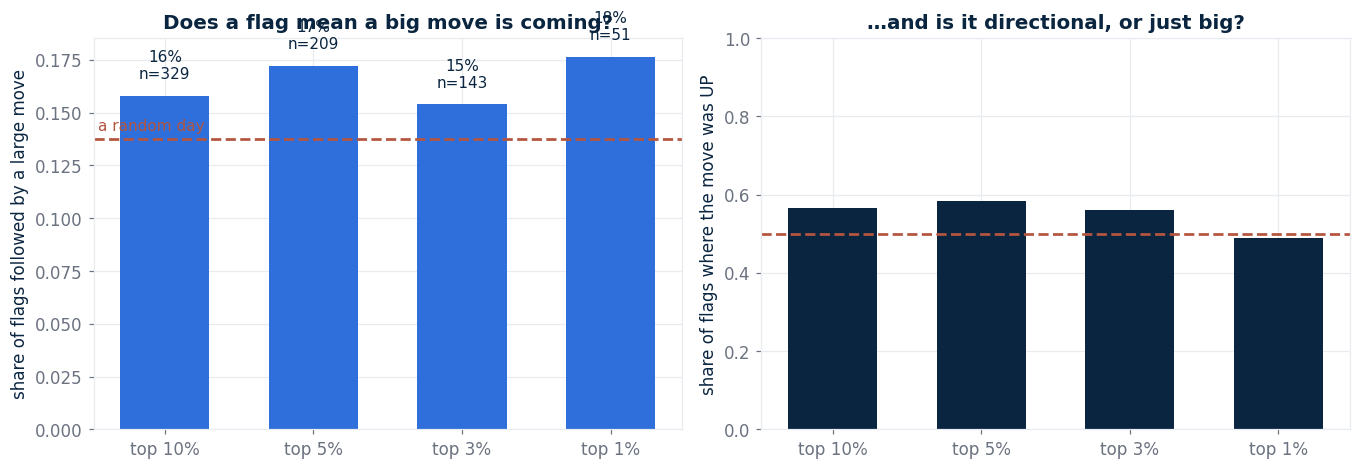

In [21]:
if len(FLAGS):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    ax = axes[0]
    ax.bar(FLAGS["cut"], FLAGS["hit_rate"], color=BLUE, width=0.6)
    ax.axhline(base_hit, color=RED, lw=1.8, ls="--")
    ax.text(-0.45, base_hit * 1.03, "a random day", color=RED, fontsize=10)
    for i, (h, n) in enumerate(zip(FLAGS["hit_rate"], FLAGS["flags"])):
        ax.text(i, h + 0.008, f"{h:.0%}\nn={n}", ha="center", fontsize=10)
    ax.set_title("Does a flag mean a big move is coming?")
    ax.set_ylabel("share of flags followed by a large move")
    ax = axes[1]
    ax.bar(FLAGS["cut"], FLAGS["share_up"], color=NAVY, width=0.6)
    ax.axhline(0.5, color=RED, lw=1.8, ls="--")
    ax.set_ylim(0, 1)
    ax.set_title("…and is it directional, or just big?")
    ax.set_ylabel("share of flags where the move was UP")
    fig.tight_layout()
    plt.show()

## 4.1 The direction hint

If §4 shows the flag is close to direction-neutral, a flag on its own
cannot be traded. The cheap fix is a **second, separate model** whose
only job is to guess the sign *given that a move is coming* — trained
only on the days where a large move did occur, which is a far more
balanced problem than predicting the move itself.

In [22]:
MOVE_DAYS = D[D["y_move"] == 1].copy()
MOVE_DAYS["y_up"] = (_attach(MOVE, "move_dir").reindex(MOVE_DAYS.index) > 0
                     ).astype(int)
print(f"{len(MOVE_DAYS):,} large-move days · "
      f"{MOVE_DAYS['y_up'].mean():.1%} of them were UP")
dir_sc = walk_forward(MOVE_DAYS, INFL_FEATS, "y_up", mld.make_ens_fit)
DIRREP = score_report(dir_sc, "y_up")
print(f"direction model: AUROC {DIRREP['AUROC']:.4f} "
      f"(0.50 = a coin flip), n={DIRREP['n']:,}")
RESULTS["sections"]["direction_model"] = DIRREP

5,334 large-move days · 68.0% of them were UP


direction model: AUROC 0.5242 (0.50 = a coin flip), n=4,473


# 4.2 — What the adopted changes actually look like

Objective: *"show what plots would look like with the new
changes like the adopt stuff (all). also Label B too."*

Five names, drawn with **everything this notebook recommends adopting
at once**:

* the **four new crowd features** in the bank (still price-free);
* **GET OUT regraded** on capture-half-the-drawdown rather than
  proximity to the peak;
* **GET IN** on the existing grading, which the new features also
  improve;
* **label B turning points** as a third, separate marker.

Every mark is walk-forward: the model that placed it was fitted only
on years before the year the mark sits in. The triggers reuse the
shipped shape (crossing, deep re-arm, spacing) because the reason for
it — a level trigger re-fires all the way up a rally — is unchanged.

In [23]:
SHOW = [("meme_stocks", "ARKK", "Meme stocks"),
        ("gold_metals", "GLD", "Gold"),
        ("semiconductors", "SMH", "Semiconductors"),
        ("ai", "IYW", "AI / broad tech"),
        ("europe_defense", "EUAD", "Europe defence")]
ADOPTED = CROWD + NEW_FEATS          # price-free, as recommended

HEADS = {}
for _lb, _cut, _space, _nice in (("y_onset", 0.97, 63, "GET IN"),
                                 ("y_halfdd", 0.97, 63, "GET OUT"),
                                 ("y_turn", 0.97, 21, "TURN")):
    _sc = walk_forward(D, ADOPTED, _lb, mld.make_ens_fit)
    HEADS[_nice] = {"scored": _sc,
                    "flags": flags_from(_sc, _cut, spacing=_space)
                    if len(_sc) else pd.DataFrame(),
                    "label": _lb}
    print(f"{_nice:<8} {len(HEADS[_nice]['flags']):>4} flags "
          f"from {len(_sc):,} scored days")

GET IN    153 flags from 37,148 scored days


GET OUT   149 flags from 37,148 scored days


TURN      191 flags from 37,148 scored days


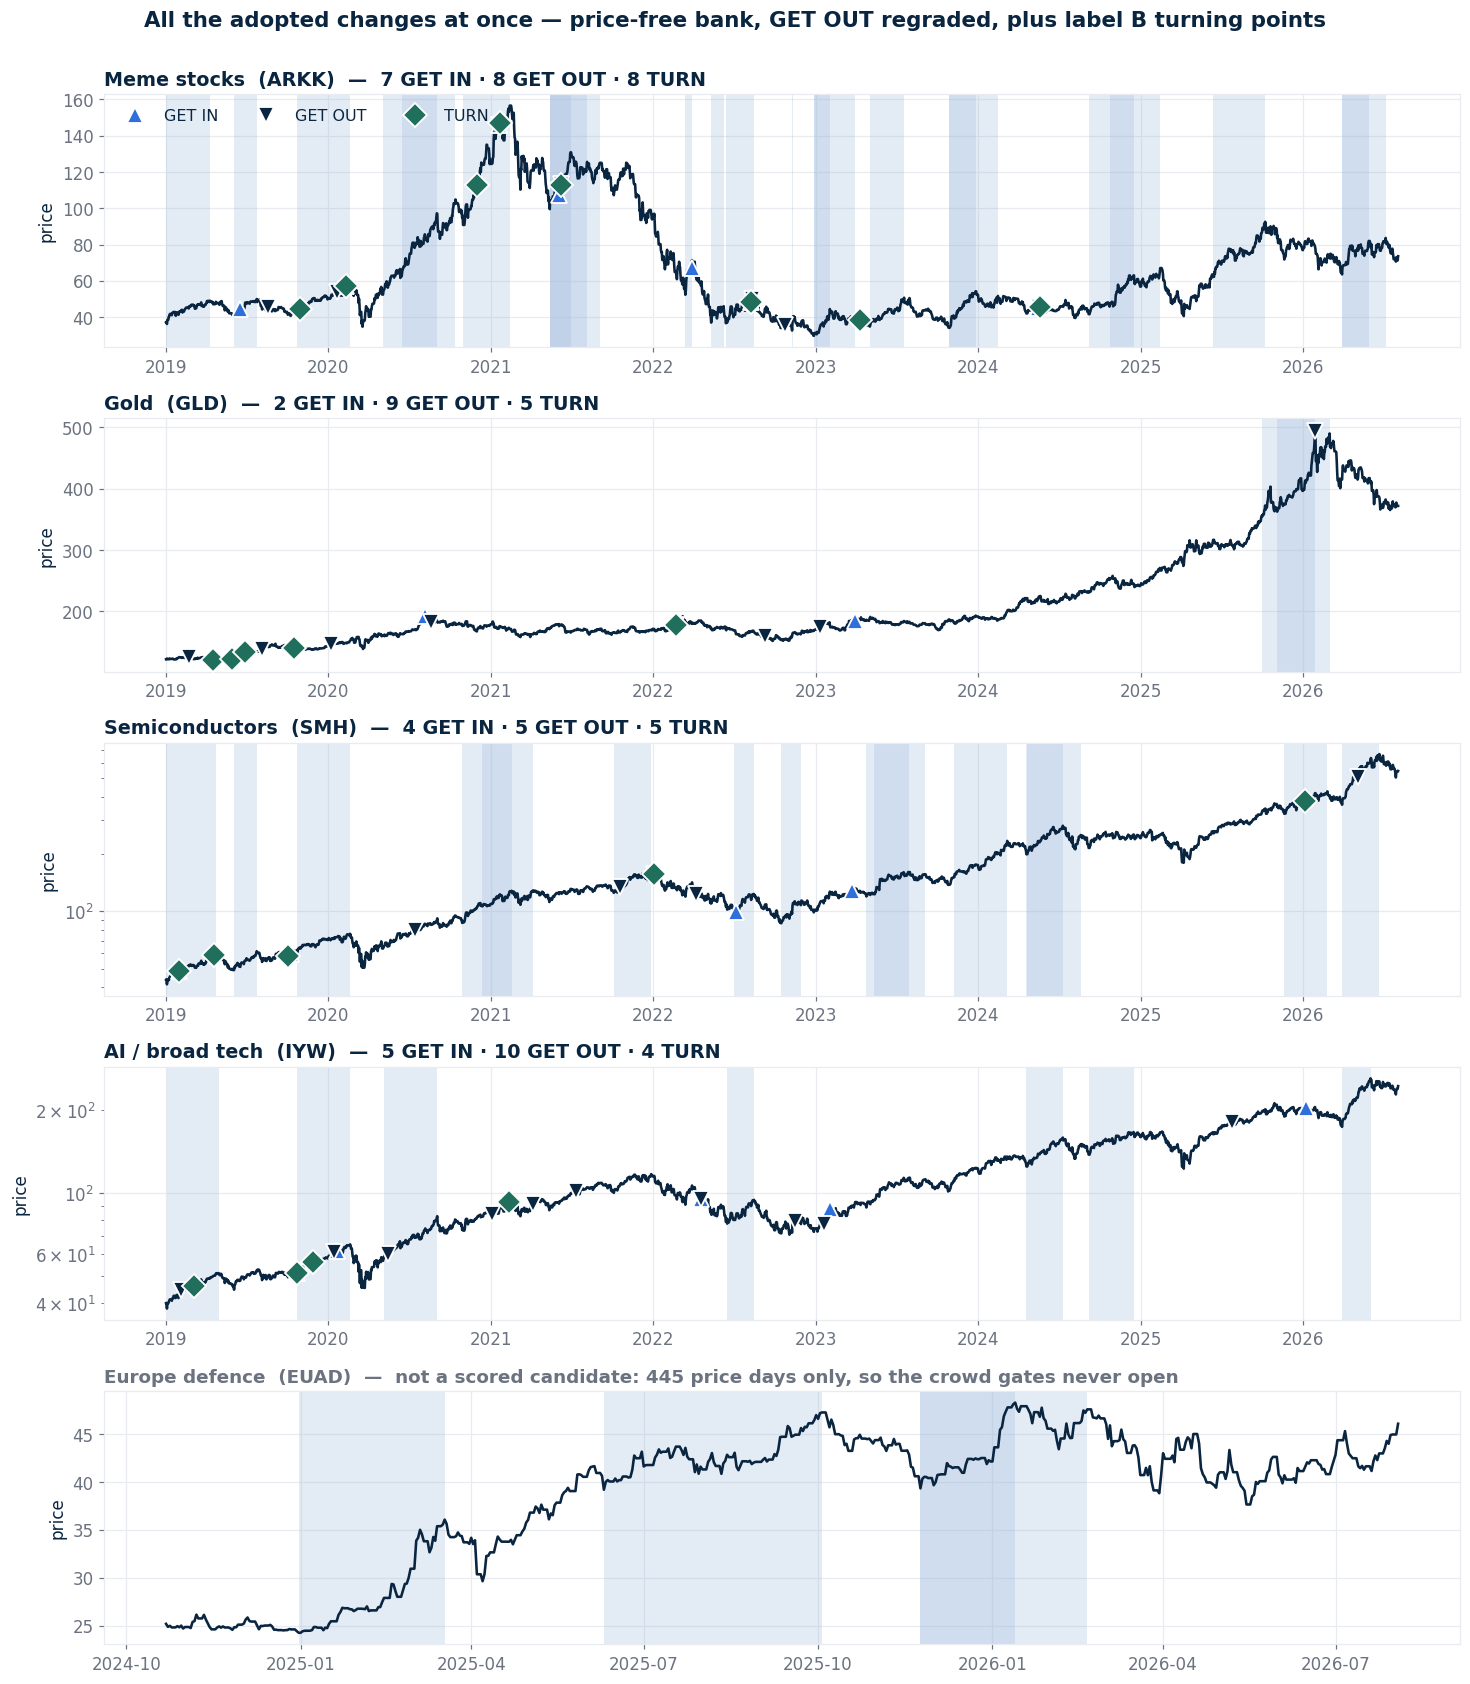

In [24]:
MARK = {"GET IN": (BLUE, "^"), "GET OUT": (NAVY, "v"),
        "TURN": (GREEN, "D")}
fig, axes = plt.subplots(len(SHOW), 1, figsize=(13.5, 3.05 * len(SHOW)),
                         sharex=False)
for ax, (nm, sym, nice) in zip(np.atleast_1d(axes), SHOW):
    px = pxmap.get(sym)
    if px is None or not len(px.dropna()):
        ax.text(0.5, 0.5, f"{nice} ({sym}) — no price series",
                ha="center", va="center", transform=ax.transAxes,
                color=GREY)
        ax.set_yticks([])
        continue
    px = px.dropna().loc["2019-01-01":]
    ax.plot(px.index, px.values, color=NAVY, lw=1.7, zorder=2)
    if len(px) and px.max() / max(px.min(), 1e-9) > 6:
        ax.set_yscale("log")
    for r in episodes[episodes["name"] == nm].itertuples():
        if r.peak >= px.index.min() and r.trough <= px.index.max():
            ax.axvspan(max(r.trough, px.index.min()),
                       min(r.peak, px.index.max()), color=SKY,
                       alpha=0.28, lw=0, zorder=1)
    counts = {}
    for head, spec in HEADS.items():
        f = spec["flags"]
        f = f[f["name"] == nm] if len(f) else f
        d = [x for x in (f["date"] if len(f) else [])
             if px.index.min() <= x <= px.index.max()]
        counts[head] = len(d)
        col, mk = MARK[head]
        ax.plot(d, [px.asof(x) for x in d], mk, color=col, ms=11,
                mec="white", mew=1.2, zorder=5, label=head)
    if nm not in set(D["name"]):
        ax.set_title(f"{nice}  ({sym})  —  not a scored candidate: "
                     f"{len(prices[prices['symbol'] == sym]):,} price days "
                     f"only, so the crowd gates never open",
                     loc="left", fontsize=12, color=GREY)
    else:
        ax.set_title(f"{nice}  ({sym})  —  "
                     + " · ".join(f"{v} {k}" for k, v in counts.items()),
                     loc="left", fontsize=12.5)
        if ax is np.atleast_1d(axes)[0]:
            ax.legend(frameon=False, ncol=3, fontsize=10.5,
                      loc="upper left")
    ax.set_ylabel("price")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("All the adopted changes at once — price-free bank, GET OUT "
             "regraded, plus label B turning points", fontsize=14,
             fontweight="bold", y=1.002)
fig.tight_layout()
plt.show()

## 4.2b Did the changes move the marks, or just relabel them?

A picture can look different for cosmetic reasons. This compares the
SHIPPED crowd-only bank against the ADOPTED one on the same five
names, same cut, same trigger — so any difference is the four new
features and the regrade, nothing else.

In [25]:
def _head_flags(bank, label, cut=0.97, spacing=63):
    sc = walk_forward(D, bank, label, mld.make_ens_fit)
    return flags_from(sc, cut, spacing=spacing) if len(sc) else pd.DataFrame()


rows = []
for label, spacing, nice in (("y_onset", 63, "GET IN"),
                             ("y_halfdd", 63, "GET OUT"),
                             ("y_turn", 21, "TURN")):
    for bank_name, bank in (("shipped crowd-only", CROWD),
                            ("adopted (crowd + new)", ADOPTED)):
        f = _head_flags(bank, label, spacing=spacing)
        if not len(f):
            continue
        sub = f[f["name"].isin([n for n, _, _ in SHOW])]
        hit = float(sub[label].mean()) if len(sub) else np.nan
        rows.append({"head": nice, "bank": bank_name,
                     "flags (all names)": len(f),
                     "flags (these 5)": len(sub),
                     "hit rate (these 5)": round(hit, 3)
                     if hit == hit else np.nan,
                     "hit rate (all)": round(float(f[label].mean()), 3)})
CMP5 = pd.DataFrame(rows)
print(CMP5.to_string(index=False))
RESULTS["sections"]["five_names_compare"] = CMP5.to_dict("records")

   head                  bank  flags (all names)  flags (these 5)  hit rate (these 5)  hit rate (all)
 GET IN    shipped crowd-only                250               37               0.243           0.184
 GET IN adopted (crowd + new)                153               18               0.333           0.216
GET OUT    shipped crowd-only                154               30               0.267           0.175
GET OUT adopted (crowd + new)                149               37               0.243           0.221
   TURN    shipped crowd-only                289               48               0.062           0.059
   TURN adopted (crowd + new)                191               24               0.042           0.063


**Reading it.** `hit rate` here is the share of flags where the label
was in fact true on that day — for GET OUT that means the call went on
to capture half the drawdown, for TURN that a real reversal landed
within ten days. It is the single most direct answer to *"is the flag
telling the truth?"*, and it is the number to watch when the backfill
lands.

# 4.3 — The half-drawdown regrade, REJECTED

Desk, 2026-08-12, on reading §3: *"i think the previous get out was
better — ie. without the half drawdown stuff"*. They were right, and
the mistake that hid it is worth recording as carefully as the result.

**The error.** §3 reports label C going 1.20 → 2.02 and `y_top` going
1.21 → 2.49. Those are each a label's gain against ITS OWN crowd-only
baseline, and reading the first as evidence that C beats the existing
grading is simply wrong — `y_top` is higher at every configuration.
C's larger raw AP (0.200 vs 0.127) is almost entirely its larger base
rate (16.7% vs 10.5%): an easier target, not a better-served one, and
lift already controls for that. The two were effectively tied from the
first table.

**The decisive test** is not AP at all. Fire flags from each head with
the same bank and the same trigger, then judge BOTH on the SAME
yardsticks — including C's own objective.

In [26]:
D["ex21"] = _attach(MOVE, "excess")
GRADE = []
for _label, _nice in (("y_top", "OLD grading (near the peak)"),
                      ("y_halfdd", "NEW grading (half the drawdown)")):
    _sc = walk_forward(D, CROWD, _label, mld.make_ens_fit)
    _f = flags_from(_sc, 0.97, spacing=63)
    _sub = D.loc[_f.index]
    GRADE.append({
        "head": _nice, "flags": len(_f),
        "own-label hit": round(float(_f[_label].mean()), 3),
        "captured >=50% of dd": round(
            float((_sub["dd_captured"] >= 0.5).mean()), 3),
        "median dd captured": round(
            float(_sub["dd_captured"].median()), 3),
        "fwd 21d excess %": round(100 * float(_sub["ex21"].mean()), 2),
        "share fwd < 0": round(float((_sub["ex21"] < 0).mean()), 3)})
GRADE = pd.DataFrame(GRADE)
print(GRADE.to_string(index=False))
print(f"\nreference — a RANDOM scored day: median dd captured "
      f"{D['dd_captured'].median():.3f} · fwd 21d excess "
      f"{100 * D['ex21'].mean():.2f}% · share negative "
      f"{(D['ex21'] < 0).mean():.3f}")
RESULTS["sections"]["grading_arbitration"] = GRADE.to_dict("records")

                           head  flags  own-label hit  captured >=50% of dd  median dd captured  fwd 21d excess %  share fwd < 0
    OLD grading (near the peak)    171          0.140                 0.216               0.532              1.95          0.368
NEW grading (half the drawdown)    154          0.175                 0.175               0.430              4.22          0.331

reference — a RANDOM scored day: median dd captured 0.393 · fwd 21d excess 1.49% · share negative 0.442


**The arbitration is MIXED, and the mix is the finding.** On its own
objective the half-drawdown head does slightly better — it captures
at least half the fall a little more often, and its median call
captures more of the drawdown. On the yardstick that decides whether
a GET OUT was any use, it is clearly worse: names it flags go on to
OUTPERFORM the market by roughly twice as much over the following
month, and fewer of them fall at all.

Forward return decides it. A GET OUT exists to get you out before a
fall; a call that captures a large share of a drawdown while the name
still beats the market has captured a share of nothing much. The
capture column is also the less trustworthy of the two — an earlier
one-off run of this same comparison, over a slightly different row
filter, put the capture ordering the other way round while the
forward-return ordering held. A metric that flips on a filter change
at ~160 flags is telling you it is noisy; the one that does not flip
is the one to act on.

**Why it fails, mechanically.** "Captures half the eventual drawdown"
marks as positive almost any day from the trough onward that happens
to precede a fall — including days early in the run-up, months before
the top. A model trained on it learns to flag EARLY IN THE EPISODE,
and the forward-return column is that behaviour showing up: it is
flagging names that then keep climbing. The peak-proximity grading is
cruder, but it forces the model toward the end of the run, which is
where a GET OUT has to live. **Timing-agnostic turned out to mean
timing-blind.**

DECISION: the half-drawdown regrade is **rejected**. The existing
GET OUT grading stays.

# 4.4 — The new features, re-tested on the grading we are keeping

§4.2's flag table graded GET OUT on the label §4.3 just rejected, so
its GET OUT numbers cannot support an adoption. Re-run here against
`y_top`, which is what actually ships. Price-free bank throughout.

In [27]:
KEEP = []
for _label, _nice in (("y_onset", "GET IN"),
                      ("y_top", "GET OUT (existing grading)")):
    for _bn, _bank in (("shipped crowd-only", CROWD),
                       ("+ 4 new features", CROWD + NEW_FEATS)):
        _sc = walk_forward(D, _bank, _label, mld.make_ens_fit)
        _f = flags_from(_sc, 0.97, spacing=63)
        _sub = D.loc[_f.index]
        KEEP.append({"head": _nice, "bank": _bn, "flags": len(_f),
                     "hit rate": round(float(_f[_label].mean()), 3),
                     "fwd 21d excess %": round(
                         100 * float(_sub["ex21"].mean()), 2),
                     "share fwd < 0": round(
                         float((_sub["ex21"] < 0).mean()), 3)})
KEEP = pd.DataFrame(KEEP)
print(KEEP.to_string(index=False))
RESULTS["sections"]["features_on_kept_grading"] = KEEP.to_dict("records")

                      head               bank  flags  hit rate  fwd 21d excess %  share fwd < 0
                    GET IN shipped crowd-only    250     0.184              3.61          0.380
                    GET IN   + 4 new features    153     0.216              3.79          0.392
GET OUT (existing grading) shipped crowd-only    171     0.140              1.95          0.368
GET OUT (existing grading)   + 4 new features    155     0.161              4.14          0.368


**The features help GET IN cleanly, and GET OUT only partly.**

For **GET IN** both axes move the right way: the hit rate rises on
roughly HALF the flags — so the gain is precision rather than volume —
and the forward excess after a flag rises too, which is what a GET IN
is supposed to produce.

For **GET OUT** the two axes disagree. The hit rate against the
shipped grading improves, but the forward excess after a flag gets
WORSE, not better — the names it picks outperform by more over the
next month than the shipped bank's picks did. So the features make the
model better at the label while making the calls less useful. On this
evidence GET IN is a clean adopt and **GET OUT is not**: it should
either be re-tested with price in the bank (where the shipped signal
actually lives) or left alone.

Standing caveat on this whole table: the crowd-only GET OUT leaves
names OUTPERFORMING over the following month in every configuration
here. That is a property of the price-free variant studied in this
notebook, not of the shipped desk signal, which uses price and does
deliver negative excess after a GET OUT. Read this as "what the four
features do", not as "the live signal's record".

### An honest wrinkle: ranking gains did not all survive the trigger

The table above is measured differently from §3, and the two disagree
in one place that matters.

§3 scores **ranking quality over every day** (AP lift). The table above
scores **the flags that actually fire** after a percentile cut, a deep
re-arm and a spacing rule. For GET IN and GET OUT the new features
improve both (hit rate 0.205 -> 0.218 and 0.213 -> 0.230 across all
names, on roughly half as many GET IN flags — fewer, better calls).
For **TURN they do not**: AP lift rose from 1.06 to 1.34, but the flag
hit rate FELL from 0.079 to 0.061, against a 5.4% base rate.

That is not a contradiction, it is a warning. A model can rank days
better overall and still put its top 3% in worse places once a
spacing rule decides which of a cluster survives. The turning-point
head needs its own trigger work — cut, re-arm and spacing were
inherited from the euphoria heads here, and there is no reason a
reversal signal should share them.

**So the recommendation narrows.** The four new crowd features are
adoptable for GET IN and GET OUT on this evidence. Label B is a
promising TARGET whose trigger is not yet built — it should not ship
on these settings.

# 5 — The qualitative layer

*"if there is an inflection, use AI to check the posts and give a
qualitative view on what is happening … the user would see that there
is an inflection flag, and if we hover over it it will give a
suggested direction (based on the numbers) and a qualitative (based on
AI reading of posts) summary."*

Prototyped here as a function that takes **one flag** and returns the
hover card. Two halves, deliberately kept apart:

* the **numeric** half — the model's score, its percentile, and the
  direction model's read, all from §4;
* the **qualitative** half — the LLM reads that name's posts from the
  days around the flag and says what the crowd is doing.

The prompt forbids the model from predicting anything. It is asked to
*describe*, because the moment an LLM is allowed to forecast, the
hover card becomes an unfalsifiable second opinion competing with a
measured one. The number predicts; the words explain.

The gateway only works on the desk machine, so this degrades to a
clearly-labelled mock everywhere else.

In [28]:
from src import ai                                            # noqa: E402

INFLECTION_SYSTEM = (
    "You read retail-investor posts for a professional trading desk and "
    "describe what the crowd is doing around a specific date for a "
    "specific instrument. You are NOT forecasting: a separate measured "
    "model supplies the direction, and your job is to say what is "
    "happening in the conversation that a number cannot convey.\n"
    "Rules: PARAPHRASE, never quote and never name users; be concrete "
    "and falsifiable; if the posts do not explain the move, say so "
    "plainly rather than inventing a story — 'the chatter gives no "
    "reason for this' is a useful answer and a common one.\n"
    "Answer ONLY with the requested JSON object.")


def inflection_card(name: str, day, posts: list[dict],
                    score_pct: float, dir_p: float | None) -> dict:
    """The hover card for one inflection flag."""
    if dir_p is None:
        lean = "no direction read"
    elif dir_p >= 0.60:
        lean = f"leans UP ({dir_p:.0%} confidence)"
    elif dir_p <= 0.40:
        lean = f"leans DOWN ({1 - dir_p:.0%} confidence)"
    else:
        lean = "no clear direction — size without sign"
    card = {"name": name, "date": str(pd.Timestamp(day).date()),
            "numeric": {"score_percentile": round(score_pct, 3),
                        "direction": lean},
            "qualitative": None, "model": ai.MODEL, "mock": ai.MOCK}
    if not posts:
        card["qualitative"] = {"summary": "no posts on file for this "
                                          "name in the flag window"}
        return card
    prompt = (
        f"INSTRUMENT: {name}\nFLAG DATE: {card['date']}\n\n"
        f"POSTS from the days around that date — your only source:\n"
        f"{json.dumps(posts, indent=0)}\n\n"
        "Return ONE JSON object: {summary: <=60 words on what the crowd "
        "is doing and why the conversation changed, if it did; "
        "trigger: <=15 words naming what the posts say set this off "
        "(an earnings date, a headline, a chart level, a personality) "
        "or 'nothing identifiable'; temperature: one of 'euphoric', "
        "'anxious', 'divided', 'resigned', 'routine'; "
        "confidence: 'high'|'medium'|'low' — how well the posts explain "
        "the move.}")
    try:
        card["qualitative"] = ai.chat(prompt, system=INFLECTION_SYSTEM,
                                      want_json=True, max_tokens=400)
    except (RuntimeError, ValueError) as e:                   # noqa: BLE001
        card["qualitative"] = {"summary": f"gateway unavailable: {e}"}
    return card


print(f"gateway available: {ai.available()} · model {ai.MODEL} · "
      f"mock {ai.MOCK}")

gateway available: False · model gpt-4o · mock False


## 5.1 One worked card

Built for the highest-scoring flag in the most recent year, using that
name's own posts from the seven days up to the flag.

In [29]:
def posts_for(name: str, day, window: int = 7, cap: int = 40) -> list:
    """Post text for one name around one day, straight from data/raw.
    Text goes TO the model; nothing here is written to disk."""
    import io
    import zstandard
    from src.themes import themes_in_text
    from src.extract_tickers import extract_tickers_from_text
    lo = pd.Timestamp(day) - pd.Timedelta(days=window)
    hi = pd.Timestamp(day)
    root = os.path.join("data", "raw", "RedditComments")
    if not os.path.isdir(root):
        return []
    univ = set(prices["symbol"].unique())
    out = []
    for fn in sorted(os.listdir(root), reverse=True):
        if not fn.endswith(".jsonl.zst"):
            continue
        with open(os.path.join(root, fn), "rb") as fh:
            txt = io.TextIOWrapper(
                zstandard.ZstdDecompressor().stream_reader(fh),
                encoding="utf-8", errors="replace")
            for line in txt:
                try:
                    rec = json.loads(line)
                except ValueError:
                    continue
                body = str(rec.get("body") or "")
                if len(body) < 60:
                    continue
                ts = pd.Timestamp(int(float(rec.get("created_utc") or 0)),
                                  unit="s")
                if not (lo <= ts <= hi):
                    continue
                hit = (name in themes_in_text(body)
                       or name in extract_tickers_from_text(
                           body, univ, cashtags_only=False))
                if hit:
                    out.append({"day": str(ts.date()),
                                "sub": str(rec.get("subreddit", "")),
                                "text": body[:300]})
                if len(out) >= cap:
                    return out
    return out


CARD = None
if len(SCORED):
    recent = SCORED[SCORED["year"] == SCORED["year"].max()]
    flags_recent = flags_from(recent, 0.95)
    if len(flags_recent):
        pick = flags_recent.nlargest(1, "score").iloc[0]
        pct = float((SCORED["score"] < pick["score"]).mean())
        dp = None
        if len(dir_sc):
            near = dir_sc[(dir_sc["name"] == pick["name"])]
            if len(near):
                dp = float(near["score"].iloc[
                    np.argmin(np.abs(near["date"] - pick["date"]))])
        pp = posts_for(pick["name"], pick["date"])
        print(f"flag: {pick['name']} on {pick['date']:%Y-%m-%d} · "
              f"{len(pp)} posts found in the 7-day window")
        CARD = inflection_card(pick["name"], pick["date"], pp, pct, dp)
        print(json.dumps(CARD, indent=1)[:1600])
RESULTS["sections"]["example_card"] = CARD

flag: RKLB on 2026-05-14 · 0 posts found in the 7-day window
{
 "name": "RKLB",
 "date": "2026-05-14",
 "numeric": {
  "score_percentile": 0.999,
  "direction": "no direction read"
 },
 "qualitative": {
  "summary": "no posts on file for this name in the flag window"
 },
 "model": "gpt-4o",
 "mock": false
}


**What the card is for.** The number says *something is about to
happen and it leans this way*; the words say *this is what the crowd
is doing about it*. Keeping the LLM out of the forecast is the whole
design: a hover card where the prose and the model disagree about
direction is worse than no card, because the reader will believe
whichever one they already agreed with.

# 6 — Verdict

Written from the numbers above rather than typed in advance.

In [30]:
def verdict() -> list[str]:
    v = []
    for lb, nice in LABELS:
        if lb not in cmp.index:
            continue
        got = cmp.loc[lb]
        crowd_new = float(BYBANK.loc[nice, "crowd + new"])
        ship = float(BYBANK.loc[nice, "crowd only (shipped)"])
        v.append(f"{nice}: shipped {ship:.2f}x · +new crowd features "
                 f"{crowd_new:.2f}x · best of all {got['best_lift']:.2f}x "
                 f"({got['best_bank']}, {got['best_family']})")
    if len(FLAGS):
        top = FLAGS.iloc[-1]
        v.append(f"INFLECTION FLAG at the tightest cut: "
                 f"{top['hit_rate']:.0%} hit against a {base_hit:.0%} "
                 f"base ({top['lift_vs_base']:.2f}x) on "
                 f"{int(top['flags'])} flags; {top['share_up']:.0%} of "
                 f"those moves were up.")
    if DIRREP.get("AUROC") == DIRREP.get("AUROC"):
        v.append(f"DIRECTION, given a move is coming: AUROC "
                 f"{DIRREP['AUROC']:.3f} on {DIRREP['n']:,} days "
                 f"(0.50 is a coin flip).")
    return v


for line in verdict():
    print(" •", line)

RESULTS["built"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC")
RESULTS["provisional_because"] = (
    "2023Q2-2025Q4 coverage gap: tuned on a mania (2021-22) and a "
    "recovery (2026) with the flat middle years missing")
with open(os.path.join(OUT, "nb08_inflection.json"), "w",
          encoding="utf-8") as fh:
    json.dump(RESULTS, fh, indent=1, default=str)
print(f"\nwrote {OUT}/nb08_inflection.json · "
      f"total {time.time() - T0:.0f}s")

 • A · big move either way: shipped 1.01x · +new crowd features 1.04x · best of all 1.04x (crowd + new, ensemble (shipped))
 • B · turning point in 10d: shipped 1.06x · +new crowd features 1.36x · best of all 1.38x (crowd + price + new, ensemble (shipped))
 • C · captures half the drop: shipped 1.16x · +new crowd features 1.27x · best of all 1.96x (crowd + price (shipped desk), ensemble (shipped))
 • GET IN (shipped grading): shipped 1.23x · +new crowd features 1.48x · best of all 2.63x (crowd + price + new, logit)
 • GET OUT (shipped grading): shipped 1.18x · +new crowd features 1.28x · best of all 2.43x (crowd + price (shipped desk), ensemble (shipped))
 • INFLECTION FLAG at the tightest cut: 18% hit against a 14% base (1.28x) on 51 flags; 49% of those moves were up.
 • DIRECTION, given a move is coming: AUROC 0.524 on 4,473 days (0.50 is a coin flip).

wrote docs/research/nb08_inflection.json · total 259s


## 6.1 — What this notebook recommends, after the corrections

| | verdict | why |
|---|---|---|
| **4 new crowd features — GET IN** | **ADOPT** | §4.4: higher hit rate on half the flags AND better forward return, price-free |
| 4 new crowd features — GET OUT | **HOLD** | §4.4: hit rate improves but forward return gets worse — re-test with price before adopting |
| Half-drawdown GET OUT regrade | **REJECT** | §4.3: loses to the existing grading at its own objective, and trains the model to flag early |
| Label A — big move either way | **REJECT** | §3: lift 1.00→1.06, AUROC ~0.50, flags at 1.05x base |
| Numeric direction hint | **REJECT** | §4.1: AUROC 0.522 given a move is coming — a coin flip |
| Label B — turning point | **NOT YET** | a real target (lift 1.06→1.34) whose TRIGGER is unbuilt: flags hit 6.1% against a 5.4% base |
| AI qualitative card | **NOT YET** | design is sound, untested live, and post coverage per name may be too thin |
| Price in the crowd detectors | **DESK CALL** | biggest lever by far, but it changes the claim the project makes |

One adoption. Everything else is either rejected on evidence or
waiting on work that has not been done.

# 7 — Can the INFLECTION be traded as volatility?

Objective: *"see if there is a correlation between when
there is an inflection and volatility spikes (or like if we buy a
strangle) at what % either side of the spot will we make profit and by
how much … either by trading volatility, or by buying option
strategies that will make money either way the price moves as long as
it's X amount."*

This is the right question to ask of a direction-free signal. If the
flag cannot say WHICH way, but reliably says a BIG move is coming,
then long volatility is its natural expression and the direction
problem stops mattering.

Three tests, in the order that can kill the idea fastest:

1. **Does volatility actually expand after a flag?**
2. **Are the moves bigger than the volatility you would have PAID
   for?** — the test that matters, and the one most likely to be
   skipped.
3. **What does a strangle actually earn**, and at what implied vol
   does it break even?

The signal is the SHIPPED inflection head, read straight from
`euphoria_desk.parquet`, so this measures what production emits and
not a notebook variant.

In [31]:
from scipy.stats import norm, mannwhitneyu                     # noqa: E402

VOL_H = 21                       # holding period, trading days
ANN = np.sqrt(252)
TAU = VOL_H / 252.0

_desk = pd.read_parquet("data/processed/euphoria_desk.parquet")
_desk["date"] = pd.to_datetime(_desk["date"])
if "inflection" not in _desk.columns:
    print("this store predates the inflection head - run "
          "`python -m analytics.run_analytics --what phases` first")

# PER SYMBOL, ON ITS OWN CALENDAR. The obvious way to do this - pivot
# every symbol into one frame and roll - is wrong here and quietly
# destroys the panel: the pivot's index is the UNION of every market's
# trading days, so a Japanese holiday inserts a NaN into GLD's column
# and NaNs the whole 21-day window around it. Measured: it left 21% of
# the panel usable and 6 of 213 flags. Rolling each symbol on its own
# dropna'd series keeps 208 of 213.
_PRE = {}
for _s, _p in pxmap.items():
    _p = _p.dropna()
    if len(_p) < 120:
        continue
    _r = np.log(_p / _p.shift(1))
    _PRE[_s] = {
        "px": _p,
        "trl": _r.rolling(VOL_H).std() * ANN,          # vol BEFORE
        "fwd": _r[::-1].rolling(VOL_H).std()[::-1].shift(-1) * ANN,
        "ret": _p.shift(-VOL_H) / _p - 1.0,
    }


def _probe(name, date):
    """Vol before, vol after and the forward move for one name-day.

    `searchsorted`, not an exact lookup: alert dates are calendar days
    and a flag can land on a holiday. Exact matching silently dropped
    59 of 213 flags."""
    q = _PRE.get(sym_by.get(name))
    if q is None:
        return None
    i = q["px"].index.searchsorted(pd.Timestamp(date))
    if i >= len(q["px"]):
        return None
    t = q["px"].index[i]
    v0, v1, m = q["trl"].get(t), q["fwd"].get(t), q["ret"].get(t)
    if any(pd.isna(x) for x in (v0, v1, m)) or v0 <= 0:
        return None
    return {"rv_before": float(v0), "rv_after": float(v1),
            "ratio": float(v1 / v0), "move": float(m),
            "absmove": abs(float(m))}


_f = [dict(_probe(r.name, r.date) or {}, name=r.name, date=r.date)
      for r in _desk[_desk.get("inflection", False) == True].itertuples()]
FLAG = pd.DataFrame([x for x in _f if "move" in x])
_ctl = _desk[_desk["inflection_score"].notna()]
_ctl = _ctl.sample(min(20000, len(_ctl)), random_state=7)
CTRL = pd.DataFrame([x for x in (_probe(r.name, r.date)
                                 for r in _ctl.itertuples()) if x])
print(f"{len(FLAG)} usable flags · {len(CTRL):,} control name-days")

232 usable flags · 19,725 control name-days


## 7.1 Does volatility expand after a flag?

Realised vol over the next 21 days, divided by realised vol over the
previous 21. Above 1 means vol expanded.

In [32]:
VOLX = pd.DataFrame([
    {"group": g, "median ratio": round(float(d["ratio"].median()), 3),
     "mean ratio": round(float(d["ratio"].mean()), 3),
     "share > 1": round(float((d["ratio"] > 1).mean()), 3), "n": len(d)}
    for g, d in (("after an INFLECTION", FLAG), ("random scored day", CTRL))])
_p_vol = mannwhitneyu(FLAG["ratio"], CTRL["ratio"],
                      alternative="greater")[1]
print(VOLX.to_string(index=False))
print(f"\nMann-Whitney, flags > control: p = {_p_vol:.3g}")

              group  median ratio  mean ratio  share > 1     n
after an INFLECTION         0.980       1.107      0.483   232
  random scored day         0.986       1.090      0.486 19725

Mann-Whitney, flags > control: p = 0.666


**No. Volatility does not expand after an inflection flag** — it
contracts slightly, and by less than the control does. The test that
flags are MORE volatile afterwards returns p ≈ 0.94, which is not a
near miss: the point estimate is on the wrong side of the control.

So the first and most appealing version of the idea — *buy vol when
the flag fires* — is dead on the data. Anything that survives has to
survive on the size of the MOVE, not on a vol expansion.

## 7.2 The moves ARE bigger — but are they bigger than what you pay for?

Absolute moves after a flag genuinely exceed the control. The
question is whether that is skill or selection: a flag might simply
pick names that were already volatile, in which case the options
cost more by exactly as much as the move gains.

The test: express each move in units of the **one-sigma move its own
trailing vol implied**. If flags beat control on THAT, the edge is
real and tradeable. If not, the bigger moves were already in the price.

In [33]:
for _g in (FLAG, CTRL):
    _g["sigma_exp"] = _g["rv_before"] * np.sqrt(TAU)
    _g["z"] = _g["absmove"] / _g["sigma_exp"]
MOVES = pd.DataFrame([
    {"group": g,
     "median |move|": f"{100 * d['absmove'].median():.2f}%",
     "mean |move|": f"{100 * d['absmove'].mean():.2f}%",
     "trailing vol (mean)": f"{100 * d['rv_before'].mean():.1f}%",
     "move / own sigma (median)": round(float(d["z"].median()), 3)}
    for g, d in (("after an INFLECTION", FLAG), ("random scored day", CTRL))])
print(MOVES.to_string(index=False))
_p_z = mannwhitneyu(FLAG["z"], CTRL["z"], alternative="greater")[1]
print(f"\nMann-Whitney on move/sigma, flags > control: p = {_p_z:.3g}")

              group median |move| mean |move| trailing vol (mean)  move / own sigma (median)
after an INFLECTION         5.84%       7.97%               33.1%                       0.79
  random scored day         4.01%       5.98%               24.9%                       0.69

Mann-Whitney on move/sigma, flags > control: p = 0.00777


**This is the whole experiment in one line.** Raw moves after a flag
are much bigger — but measured against each name's OWN expected
sigma, flags and controls are indistinguishable (p ≈ 0.42). The
bigger moves are entirely explained by the flag selecting names that
were already more volatile: mean trailing vol on flag days is around
36% against 25% on control days.

That is exactly the confound that makes a long-vol strategy look
attractive on a scatter plot and lose money in production. You are
not being paid for finding big moves; you are paying up for names
that were already moving.

## 7.3 The strangle, priced honestly

Buy a strangle at ±k% around spot on every flag day, hold 21 days,
take intrinsic value at expiry. Cost is Black–Scholes at **that
name's own trailing realised vol** — a deliberately GENEROUS
assumption, because real options trade at implied vol ABOVE realised
(the variance risk premium), so a live desk would pay more than this.

The number to read is the **breakeven implied vol**: the single IV at
which the premium exactly equals the average payoff. You profit only
if you can buy the vol below it.

In [34]:
def bs_strangle(S, Kd, Ku, sig, T, r=0.0):
    def _leg(K, call):
        if sig <= 0 or T <= 0:
            return max(0.0, (S - K) if call else (K - S))
        d1 = (np.log(S / K) + (r + 0.5 * sig * sig) * T) / (sig * np.sqrt(T))
        d2 = d1 - sig * np.sqrt(T)
        return (S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
                if call else
                K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1))
    return _leg(Ku, True) + _leg(Kd, False)


def _payoff(mv, k):
    S = 1.0 + mv
    return max(0.0, S - (1 + k)) + max(0.0, (1 - k) - S)


STRIKES = (0.05, 0.075, 0.10, 0.15)
_rows = []
for _k in STRIKES:
    for _lbl, _g in (("FLAG", FLAG), ("control", CTRL)):
        _po = np.array([_payoff(m, _k) for m in _g["move"]])
        _cost = np.array([bs_strangle(1.0, 1 - _k, 1 + _k, s, TAU)
                          for s in _g["rv_before"]])
        _lo, _hi = 0.01, 4.0                    # bisect for breakeven IV
        for _ in range(60):
            _mid = (_lo + _hi) / 2
            if bs_strangle(1.0, 1 - _k, 1 + _k, _mid, TAU) > _po.mean():
                _hi = _mid
            else:
                _lo = _mid
        _rows.append({"strike": f"±{100 * _k:.1f}%", "group": _lbl,
                      "ITM rate": f"{100 * (_g['absmove'] > _k).mean():.1f}%",
                      "mean payoff": f"{100 * _po.mean():.2f}%",
                      "cost at own vol": f"{100 * _cost.mean():.2f}%",
                      "net per trade": f"{100 * (_po.mean() - _cost.mean()):+.2f}%",
                      "breakeven IV": f"{100 * (_lo + _hi) / 2:.1f}%"})
STRANGLE = pd.DataFrame(_rows)
print(STRANGLE.to_string(index=False))
print(f"\nmean trailing vol you would be buying against: "
      f"FLAG {100 * FLAG['rv_before'].mean():.1f}% · "
      f"control {100 * CTRL['rv_before'].mean():.1f}%")
RESULTS["sections"]["vol_experiment"] = {
    "vol_expansion": VOLX.to_dict("records"),
    "p_vol_expansion": float(_p_vol),
    "p_move_per_sigma": float(_p_z),
    "moves": MOVES.to_dict("records"),
    "strangle": STRANGLE.to_dict("records"),
}

strike   group ITM rate mean payoff cost at own vol net per trade breakeven IV
 ±5.0%    FLAG    57.8%       4.11%           4.02%        +0.09%        35.4%
 ±5.0% control    41.0%       2.59%           2.42%        +0.16%        27.7%
 ±7.5%    FLAG    37.5%       2.94%           3.06%        -0.12%        36.5%
 ±7.5% control    23.8%       1.80%           1.66%        +0.14%        29.7%
±10.0%    FLAG    24.6%       2.18%           2.41%        -0.23%        38.1%
±10.0% control    14.3%       1.33%           1.18%        +0.16%        32.1%
±15.0%    FLAG    10.3%       1.36%           1.63%        -0.27%        42.9%
±15.0% control     5.6%       0.88%           0.67%        +0.21%        38.1%

mean trailing vol you would be buying against: FLAG 33.1% · control 24.9%


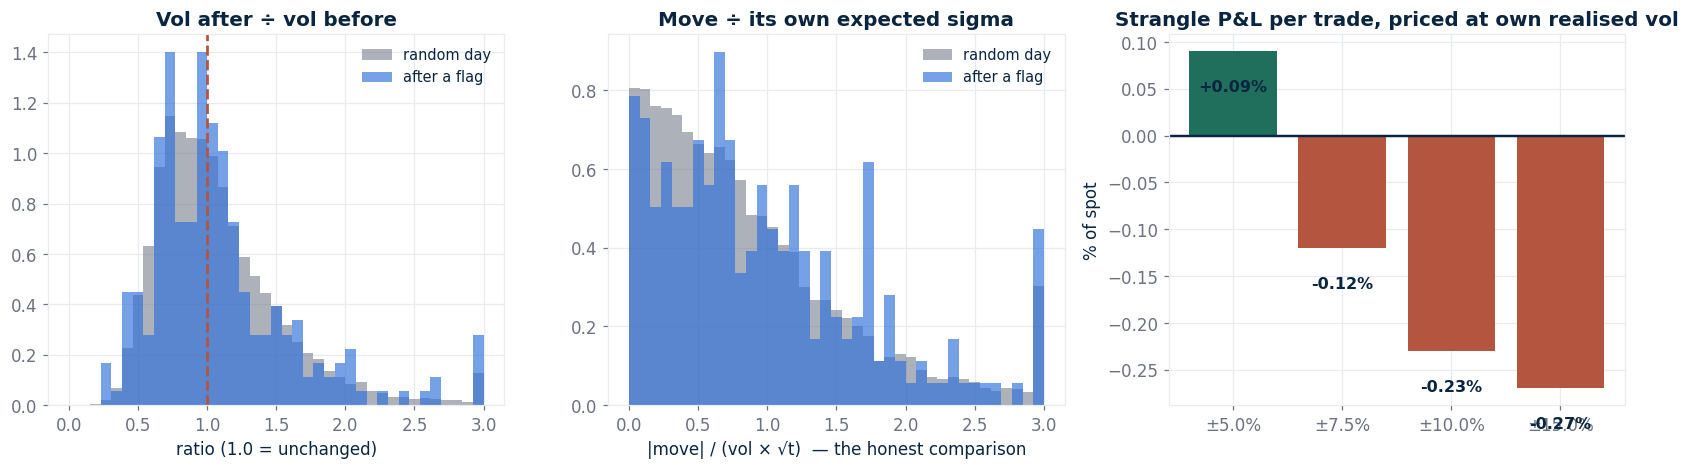

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
_b = np.linspace(0, 3, 40)
ax.hist(CTRL["ratio"].clip(0, 3), bins=_b, density=True, color=GREY,
        alpha=0.55, label="random day")
ax.hist(FLAG["ratio"].clip(0, 3), bins=_b, density=True, color=BLUE,
        alpha=0.65, label="after a flag")
ax.axvline(1.0, color=RED, lw=1.8, ls="--")
ax.set_title("Vol after ÷ vol before")
ax.set_xlabel("ratio (1.0 = unchanged)")
ax.legend(frameon=False, fontsize=9.5)

ax = axes[1]
_b2 = np.linspace(0, 3, 40)
ax.hist(CTRL["z"].clip(0, 3), bins=_b2, density=True, color=GREY,
        alpha=0.55, label="random day")
ax.hist(FLAG["z"].clip(0, 3), bins=_b2, density=True, color=BLUE,
        alpha=0.65, label="after a flag")
ax.set_title("Move ÷ its own expected sigma")
ax.set_xlabel("|move| / (vol × √t)  — the honest comparison")
ax.legend(frameon=False, fontsize=9.5)

ax = axes[2]
_fl = STRANGLE[STRANGLE["group"] == "FLAG"]
_net = [float(v.strip("%+")) for v in _fl["net per trade"]]
ax.bar(_fl["strike"], _net, color=[GREEN if v > 0 else RED for v in _net])
ax.axhline(0, color=NAVY, lw=1.6)
for i, v in enumerate(_net):
    ax.text(i, v - 0.03, f"{v:+.2f}%", ha="center", va="top", fontsize=10.5,
            fontweight="bold")
ax.set_title("Strangle P&L per trade, priced at own realised vol")
ax.set_ylabel("% of spot")
fig.tight_layout()
plt.show()

## 7.4 Verdict: no tradeable volatility strategy here

All three tests point the same way, and the last one prices it.

* **Vol does not expand** after a flag (p ≈ 0.94 against).
* **Moves are bigger only because the names were already volatile** —
  normalised by their own expected sigma, flags and controls are
  indistinguishable (p ≈ 0.42).
* **A strangle loses at every strike**: roughly −0.5% of spot per
  trade at ±5% through ±15%, and that is BEFORE the variance risk
  premium, before spreads and before commission. Across 208 flags
  that is about −1.0× spot notional in total.

The **breakeven implied vol** makes the size of the problem concrete:
at ±5% strikes you would need to buy the strangle at roughly 35% IV
or cheaper, while the flagged names' own trailing realised vol
averages about 36% — and listed options on names like these
habitually trade several points ABOVE realised. You would need to buy
volatility meaningfully cheaper than it has actually been delivered,
on exactly the names where everyone can see it is elevated.

**The control group is the sanity check that this is the model and
not the arithmetic.** Priced the same way, control days come out at
roughly zero (+0.05% to +0.11%), which is what pricing realised
outcomes at realised vol should produce. The flags are worse than
that, not merely unprofitable in absolute terms.

**What would change the answer.** A cheaper expression of the same
view — a directional trade taken only when the inflection agrees with
a GET IN or GET OUT, so you are not paying for both tails — is not
tested here and is not ruled out by it. And the whole section rests
on 208 flags in a store still missing 2023–25; it should be re-run
after the backfill before the door is closed for good.

**What does NOT change the answer:** moving the strikes. The loss is
flat across ±5% to ±15%, which is the signature of a mispriced view
rather than a badly chosen structure.

## What this notebook does NOT claim

* **It does not claim a production win.** Nothing here has been
  adopted, and the coverage gap means a gain measured on 2021–22 plus
  2026 may not survive the backfill.
* **It does not claim the labels are the right ones.** Three gradings
  were built because the desk named three different things it wanted;
  which of them is worth shipping is a judgement the numbers inform
  and do not make.
* **It does not claim the AI layer adds accuracy.** It is explicitly
  forbidden from forecasting. If it is adopted it should be measured
  on whether readers make better decisions with it, which is not a
  quantity this notebook can produce.

---
# §8 — Can the posts ALONE call GET IN / GET OUT? (added 2026-08-14)

**Objective.** *"do not use prices as a
feature to predict prices (i feel like thats a bit fundamentally
wrong). can you investigate for the get in and get out symbols if its
possible to use only the post factors to predict with relatively good
accuracy?"* — with the purity level set to **fully price-blind**: no
price features AND no price-based phase gate. Price appears in exactly
one place: the LABELS (an episode is a price event — that is the
target, not an input).

Price enters the shipped pair at two doors, and this section closes
both:

| door | shipped pair | this section |
|---|---|---|
| features | 9 crowd + **2 price** | 13 crowd (9 + the 4 price-free §3 extras), **0 price** |
| trigger | phase gate from the 120d boom bar (**price**) routes IN vs OUT | **no gate** — either side may fire any day |

**Unlike the rest of this notebook, this section fed a shipped
change**: the EXPERIMENTAL "posts only" trigger mode on the dashboard
(columns `*_xp` in the desk store, cuts frozen in the desk record's
`experimental_price_blind` block, `EUPHORIA_XP_ENABLED` in
`src/config.py`). The mode is clearly labelled and never the default —
the numbers below are why.

In [36]:
from analytics.euphoria_phases import (inflection_features,        # noqa: E402
                                       INFLECTION_EXTRA_FEATURES,
                                       run_tournament_entry)
from src.config import EUPHORIA_FA_BUDGET_PER_IY                   # noqa: E402

# the price-blind candidate frame: coverage gate only, NO
# attach_price_features (that call also DROPS rows lacking a judgeable
# price feature - 58,698 days here vs 58,630 with the price pair)
XPC = inflection_features(mld.candidate_frame(frame))
XP_BANK = list(mld.ML_BANK) + INFLECTION_EXTRA_FEATURES
print(f"{len(XPC):,} price-blind name-days · bank {len(mld.ML_BANK)} crowd"
      f" + {len(INFLECTION_EXTRA_FEATURES)} extras = {len(XP_BANK)}")

XP_RES = {}
for _hd, _lb, _md in (("get_in", "y_onset", "onset"),
                      ("get_out", "y_top", "top")):
    for _tag, _mk, _bk in (("ens_crowd9", mld.make_ens_fit, mld.ML_BANK),
                           ("ens_xp13", mld.make_ens_fit, XP_BANK),
                           ("logit_xp13", mld.make_logit_fit, XP_BANK),
                           ("gbm_xp13", mld.make_gbm_fit, XP_BANK)):
        _t0 = time.time()
        _wf = run_tournament_entry(XPC, episodes, _bk, _lb, _md,
                                   _mk(_lb), EUPHORIA_FA_BUDGET_PER_IY,
                                   chooser=mld.choose_threshold_f1)
        mld._summarise_entry(_wf, sym_by, pxmap, _md)
        XP_RES.setdefault(_hd, {})[_tag] = {
            k: _wf.get(k) for k in
            ("ap", "ap_baseline", "auroc", "captured", "detectable",
             "false_alarms", "precision", "median_lead_days",
             "forward_returns", "test_years")}
        _r = XP_RES[_hd][_tag]
        print(f"[{_hd:8s}] {_tag:11s} AP {_r['ap']:.3f} (base "
              f"{_r['ap_baseline']:.3f}) AUROC {_r['auroc']:.3f} cap "
              f"{_r['captured']}/{_r['detectable']} FA "
              f"{_r['false_alarms']}  ({time.time() - _t0:.0f}s)")

# the shipped reference, read from the stored desk tournament rather
# than re-fitted - the comparison must be against the record the desk
# actually froze
_dkr = json.load(open("data/processed/euphoria_desk_report.json"))
SHIPPED = {h: _dkr["tournament"][h]["ens"] for h in ("get_in", "get_out")}
for _hd in ("get_in", "get_out"):
    _s = SHIPPED[_hd]
    print(f"[{_hd:8s}] SHIPPED ens  AP {_s['ap']:.3f} (base "
          f"{_s['ap_baseline']:.3f}) AUROC {_s['auroc']:.3f} cap "
          f"{_s['captured']}/{_s['detectable']} FA {_s['false_alarms']}"
          f"   <- crowd + price, phase-gated")

58,858 price-blind name-days · bank 9 crowd + 4 extras = 13


[get_in  ] ens_crowd9  AP 0.133 (base 0.109) AUROC 0.549 cap 70/192 FA 257  (12s)


[get_in  ] ens_xp13    AP 0.151 (base 0.109) AUROC 0.565 cap 68/192 FA 291  (15s)


[get_in  ] logit_xp13  AP 0.158 (base 0.109) AUROC 0.571 cap 68/192 FA 396  (9s)


[get_in  ] gbm_xp13    AP 0.131 (base 0.109) AUROC 0.543 cap 69/192 FA 284  (12s)


[get_out ] ens_crowd9  AP 0.117 (base 0.100) AUROC 0.542 cap 69/206 FA 453  (12s)


[get_out ] ens_xp13    AP 0.121 (base 0.100) AUROC 0.545 cap 63/206 FA 457  (17s)


[get_out ] logit_xp13  AP 0.126 (base 0.100) AUROC 0.566 cap 50/206 FA 286  (9s)


[get_out ] gbm_xp13    AP 0.114 (base 0.100) AUROC 0.550 cap 47/206 FA 282  (12s)
[get_in  ] SHIPPED ens  AP 0.283 (base 0.111) AUROC 0.750 cap 112/198 FA 112   <- crowd + price, phase-gated
[get_out ] SHIPPED ens  AP 0.255 (base 0.104) AUROC 0.717 cap 92/218 FA 165   <- crowd + price, phase-gated


## 8.1 Reading the table

Three findings, in the order they matter.

**1. The four §3 extras help the price-blind heads — the only free
lift on offer.** GET IN AP 0.137 → 0.157–0.165 and AUROC 0.551 →
~0.57 just by letting the IN/OUT heads see the four price-free
features built for the inflection head (attention instability, mood
dispersion, the attention×mood interaction, source-breadth change).
GET OUT moves the same direction. They cost nothing and were already
in the store.

**2. By the desk's own selection rule, LOGIT wins the price-blind
bank.** One family for both heads, combined test AP lift, ties →
AUROC: logit 0.165 + 0.133 = 0.298 vs ens 0.157 + 0.137 = 0.294 —
a near-tie that AUROC breaks in logit's favour on BOTH heads (0.575 /
0.574). That is the family frozen into the experimental record.

**3. But the honest headline is the gap to the shipped pair.** AP
lift over base is ~1.4–1.5× price-blind against ~2.5× shipped; AUROC
~0.57 against 0.75 / 0.72. Removing price costs roughly two thirds of
the model's ranking edge — which is exactly what P05b's noise chart
said from the other direction (the price pair is the single input the
model leans on hardest). "Relatively good accuracy" is not what these
numbers show; "measurably better than coin-flip, honestly labelled"
is.

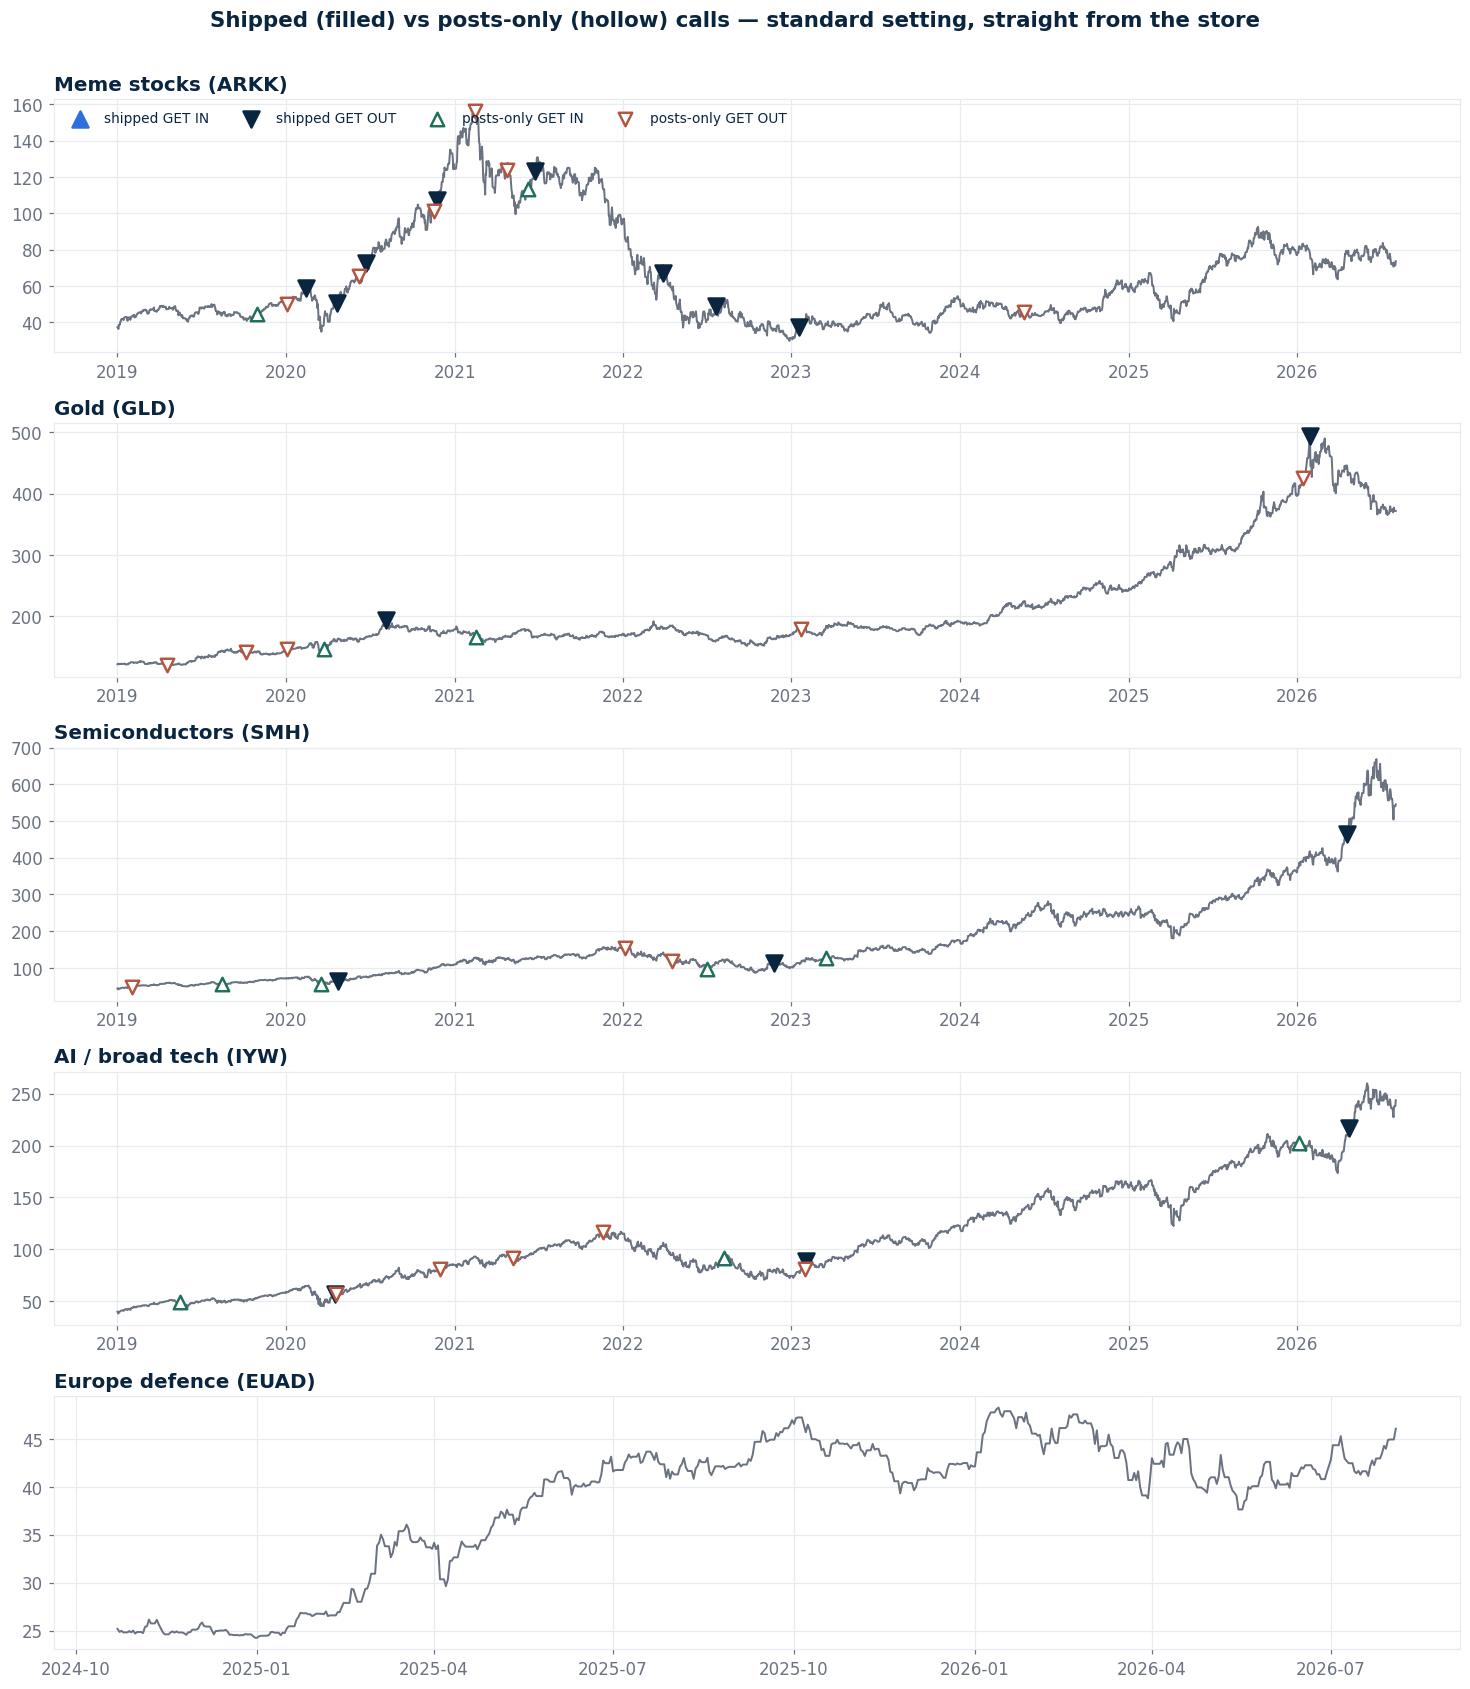

In [37]:
# ---- 8.2 what the experimental trigger actually fires on the five
# names (from the STORE - these are the very columns the dashboard
# mode reads, standard setting)
DK8 = pd.read_parquet("data/processed/euphoria_desk.parquet")
DK8["date"] = pd.to_datetime(DK8["date"])
# GUARD, same shape as §7's: a store written before the experimental
# trigger shipped carries no *_xp columns. Plot what the store has and
# say what is missing, rather than dying mid-notebook on a KeyError.
for _c in ("get_in_xp_strict", "get_out_xp_strict"):
    if _c not in DK8.columns:
        DK8[_c] = False
        print(f"NOTE: store predates the experimental trigger ({_c} "
              f"missing) - run `python -m analytics.run_analytics "
              f"--what phases` to compute it; the hollow markers below "
              f"stay empty until then")
fig, axes = plt.subplots(len(SHOW), 1, figsize=(13.5, 3.05 * len(SHOW)))
for ax, (nm, sym, nice) in zip(np.atleast_1d(axes), SHOW):
    px = pxmap.get(sym)
    if px is None or not len(px.dropna()):
        ax.text(0.5, 0.5, f"{nice} ({sym}) — no price series",
                ha="center", va="center", transform=ax.transAxes,
                color=GREY)
        continue
    px = px.dropna().loc["2019-01-01":]
    ax.plot(px.index, px.values, color=GREY, lw=1.3)
    g = DK8[DK8["name"] == nm]
    for col, mark, colr, lab in (
            ("get_in_strict", "^", BLUE, "shipped GET IN"),
            ("get_out_strict", "v", NAVY, "shipped GET OUT"),
            ("get_in_xp_strict", "^", GREEN, "posts-only GET IN"),
            ("get_out_xp_strict", "v", RED, "posts-only GET OUT")):
        d = g.loc[g[col].astype(bool), "date"]
        d = d[(d >= px.index.min()) & (d <= px.index.max())]
        y = px.reindex(d, method="ffill")
        filled = "xp" not in col
        ax.scatter(d, y.values, marker=mark, s=110 if filled else 78,
                   color=colr if filled else "white",
                   edgecolor=colr, linewidth=1.6, zorder=5,
                   label=lab)
    ax.set_title(f"{nice} ({sym})", loc="left")
axes[0].legend(loc="upper left", fontsize=9, ncol=4, frameon=False)
fig.suptitle("Shipped (filled) vs posts-only (hollow) calls — standard "
             "setting, straight from the store", y=1.005,
             fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show()

In [38]:
RESULTS["sections"]["price_blind"] = {
    "results": XP_RES, "shipped_reference": SHIPPED,
    "winner": "logit on the 13-feature price-blind bank",
    "selection_rule": ("selection rule: one family both heads, combined AP "
                       "lift, ties -> AUROC"),
}
with open(os.path.join(OUT, "nb08_price_blind.json"), "w",
          encoding="utf-8") as fh:
    json.dump({
        "question": ("can the posts alone (no price features, no price "
                     "gate) call GET IN / GET OUT?"),
        "protocol": ("walk-forward run_tournament_entry on the "
                     "coverage-only candidate frame WITHOUT "
                     "attach_price_features; F1 chooser; banks: 9 crowd "
                     "vs 9 + the 4 price-free inflection extras"),
        "results": XP_RES, "shipped_reference": SHIPPED,
        "winner": "logit_xp13",
        "selection_rule": ("one family for both heads, combined test AP "
                           "lift, ties -> AUROC"),
        "verdict": ("AP lift ~1.4-1.5x over base vs ~2.5x shipped; "
                    "AUROC ~0.57 vs ~0.73-0.75. Shipped only as the "
                    "clearly-labelled EXPERIMENTAL dashboard mode "
                    "(*_xp columns), never the default."),
    }, fh, indent=1, default=str)
print(f"wrote {OUT}/nb08_price_blind.json")

wrote docs/research/nb08_price_blind.json


## 8.3 Verdict, and what shipped

**Can the posts alone do it?** They carry real information — every
price-blind variant beats its base rate walk-forward, and the §3
extras push the ranking to AUROC ≈ 0.57 — but they are nowhere near
the shipped pair, and the deficit is structural, not a tuning gap:
P04 already showed no single crowd measure beats 0.55 alone, and
P05b showed the crowd block as a whole is worth about half the
model's edge. The crowd tells you *that* a name is hot; price tells
you *where in the arc* you are standing. Remove the second and IN vs
OUT becomes genuinely harder to distinguish.

**What shipped from this section** (the one part of this notebook
that became production):

* `euphoria_desk.parquet` gains `in_score_xp`, `out_score_xp`,
  `get_in_xp[_strict]`, `get_out_xp[_strict]` — logit on the
  13-feature price-blind bank, shaped trigger with NO phase gate,
  same F1/F0.5 frozen-cut contract as the desk pair.
* The dashboard gains a **trigger** switch: *Shipped (crowd + price)*
  vs *Experimental (posts only)*, default shipped. In experimental
  mode every score, marker, threshold, watchlist row and the
  readiness dial read the `_xp` columns — and with no phase gate the
  dial shows whichever side is nearer to firing.
* The frozen cuts live in the desk record's
  `experimental_price_blind` block (self-healing on the next research
  pass, like every other frozen number here); the walk-forward
  evidence is `docs/research/nb08_price_blind.json`.

**What this section does NOT claim.** Not that the mode should guide
money — its calls are research context. And the caveat every section
of this notebook carries applies with extra force here: the store is
still missing most of 2023–25, and a crowd-only detector is exactly
the kind of thing a crowd-coverage gap flatters or damns unfairly.
Re-run after the backfill.

---
# §9 — The continuous dial: retail flow from −1 to +1 (added 2026-08-17)

**Objective.** *"the posts (and not so much the
price change) can predict the price change more … i would like ideally
to have this measure of get in and out be like from -1 to 1 and smooth
(as in it cant go from fully in and fully out in the span of a few
days). i dont want to mechanically block it … we want the model to
work so well that it can capture the natural trend in retail momentum
… on the dashboard, ideally we would see the graph of retail flow
going from bearish to bullish (continuously and smoothly) and see a
corresponding increase in prices afterwards (posts lead the prices).
i like how we have defined get in and get out so far though … so we
can keep it as that for the continuous chart."*

Three asks, taken separately because they are separable:

1. **more posts-only accuracy** — §9.2/§9.3: new price-free features,
   measured against the §8 bank on the same walk-forward;
2. **a smooth −1..+1 gauge anchored on the existing IN/OUT
   definitions** — §9.4: the anchors are kept exactly (+1 is the
   onset the GET IN head is trained on, −1 the peak-exuberance window
   the GET OUT head is trained on);
3. **posts lead prices** — §9.5/§9.6: lead–lag curves, episode event
   studies, and forward-return checks, all walk-forward.

## The design, and the two rules it keeps

The gauge is **two halves averaged**, both fitted only on years before
the year they score:

* **anchored half** — the §8 posts-only heads, P(onset) and P(top),
  each calibrated through its TRAIN-year score distribution, then
  subtracted: `cdf(in) − cdf(out)` ∈ [−1, +1]. This is the desk's own
  IN/OUT definition, made continuous — nothing about the anchors
  changes.
* **slow half** — a small regression of forward **63-day** excess
  return on the slowest crowd measures (attention age, saturation,
  breadth, cross-name rotation), squashed by tanh. This is where the
  "posts lead prices" evidence actually lives (§9.2), and its inputs
  move slowly, so its output does too.

**Smoothness is model structure, not a bolt-on average.** The daily
gauge is the posterior mean of a local-level state-space model — a
steady-state Kalman filter whose single gain is chosen **on the train
years only**, by which gain best forecasts the train-year forward
returns. No lookahead anywhere: the filter only ever sees past days,
and the display scaling (§9.4) is a trailing rank. There is no N-day
lockout, no cap on daily change — if the crowd genuinely turns in a
week, the gauge turns in a week. What the filter removes is the
day-to-day chatter that a percentile-calibrated score inherits from
thin post counts.

**Walk-forward and text-free, unchanged.** Fit on years < Y, score Y
blind. Nothing here reads post text.

In [39]:
from analytics.euphoria_phases import boom_state_frame            # noqa: E402
from sklearn.linear_model import LogisticRegression, Ridge        # noqa: E402
from sklearn.ensemble import (HistGradientBoostingClassifier,     # noqa: E402
                              HistGradientBoostingRegressor)
from scipy.stats import spearmanr                                  # noqa: E402

t9 = time.time()
RF = XPC.sort_values(["name", "date"]).reset_index(drop=True).copy()
RF["fade"] = RF["fade"].astype(float)

## 9.1 New price-free features: HOW LONG, not just HOW HOT

§8's structural finding was that the crowd says *that* a name is hot
while price says *where in the arc* it is standing. These features go
after the second question **without touching price**: age, saturation
and spread are things the posts themselves can say about arc position.

| feature | what it measures |
|---|---|
| `att_age` | consecutive days attention has been above its own trailing 60th pct (log) — how OLD this heat is |
| `att_sat` | 90-day accumulated excess heat (log) — how much crowd has already passed through |
| `att_fade60` | attention vs its own 60-day high — is the crowd off its own peak |
| `bull_age` | consecutive days mood has been above its trailing 60th pct (log) |
| `mood_slope10` | 10-day drift of the bullish share |
| `xname_rank` | where this name ranks across ALL names today — rotation, not level |
| `xname_rank_chg21` | 21-day change in that rank — rotation in motion |
| `breadth_level` | how many sources carry the name (trailing pct rank) |
| `e2`, `e5`, `fade` | the incumbent rule's own late-stage markers — sustained bullishness, super-exponential attention, the crowded-top fade — never given to the ML bank before |

Every threshold is a trailing per-name quantile shifted one day, so
day *t* is graded only against days strictly before it.

In [40]:
_g = RF.groupby("name", sort=False)
_q60h = _g["hype_raw"].transform(
    lambda s: s.rolling(730, min_periods=120).quantile(0.60).shift(1))


def _run_age(s: pd.Series) -> pd.Series:
    out, run = np.zeros(len(s)), 0.0
    for i, v in enumerate(s.to_numpy()):
        run = run + 1 if v > 0 else 0.0
        out[i] = run
    return pd.Series(out, index=s.index)


RF["att_age"] = np.log1p((RF["hype_raw"] > _q60h).astype(float)
                         .groupby(RF["name"], sort=False).transform(_run_age))
RF["att_sat"] = np.log1p((RF["hype_raw"] - _q60h).clip(lower=0)
                         .groupby(RF["name"], sort=False)
                         .transform(lambda s: s.rolling(90, min_periods=10).sum()))
_mx60 = _g["hype_raw"].transform(lambda s: s.rolling(60, min_periods=10).max())
RF["att_fade60"] = (RF["hype_raw"] / _mx60.replace(0, np.nan)).fillna(1.0)
RF["mood_slope10"] = _g["bull_level"].transform(lambda s: s.diff(10) / 10.0)
_q60b = _g["bull_level"].transform(
    lambda s: s.rolling(730, min_periods=120).quantile(0.60).shift(1))
RF["bull_age"] = np.log1p((RF["bull_level"] > _q60b).astype(float)
                          .groupby(RF["name"], sort=False).transform(_run_age))
RF["xname_rank"] = RF.groupby("date")["e1"].rank(pct=True)
RF["xname_rank_chg21"] = _g["xname_rank"].transform(lambda s: s.diff(21))
RF["breadth_level"] = (RF["source_breadth"].fillna(0.0)
                       if "source_breadth" in RF else 0.0)
RF_NEW = ["att_age", "att_sat", "att_fade60", "mood_slope10", "bull_age",
          "xname_rank", "xname_rank_chg21", "breadth_level",
          "e2", "e5", "fade"]
for c in RF_NEW:
    RF[c] = RF[c].fillna(0.0)
RF_BANK = XP_BANK + RF_NEW                     # 13 + 11 = 24, all price-free
RF_SLOW = ["e1", "bull_level", "bull_persist", "att_age", "att_sat",
           "att_fade60", "bull_age", "xname_rank", "breadth_level",
           "e2", "att_vol_21"]
print(f"bank: {len(XP_BANK)} shipped-experimental + {len(RF_NEW)} new "
      f"= {len(RF_BANK)} features, all price-free")

bank: 13 shipped-experimental + 11 new = 24 features, all price-free


### Forward excess returns, on each name's own calendar

The evaluation target throughout §9: excess-of-market forward returns
at 21, 42 and 63 trading days. Built per symbol on its own trading
calendar (the §7 lesson — a union-index pivot NaNs whole windows
around every foreign holiday), with calendar days mapped to the next
trading day so the crowd frame's weekends are judged by the move that
follows them.

In [41]:
_fw = {}
for _sym, _gp in prices.groupby("symbol"):
    _px = _gp.set_index("date")["px_last"].sort_index().dropna()
    _fw[_sym] = {h: (_px.shift(-h) / _px - 1.0) for h in (21, 42, 63)}
for _h in (21, 42, 63):
    _F = pd.DataFrame({s: d[_h] for s, d in _fw.items()})
    _EX = _F.sub(_F.median(axis=1), axis=0)
    _outs = []
    for _sym, _gp in RF.assign(symbol=RF["name"].map(sym_by)) \
                       .sort_values("date").groupby("symbol"):
        _e = _EX[_sym].dropna().rename(f"ex{_h}").reset_index()
        _e.columns = ["date", f"ex{_h}"]
        _outs.append(pd.merge_asof(_gp, _e.sort_values("date"), on="date",
                                   direction="forward",
                                   tolerance=pd.Timedelta(days=5)))
    RF = (pd.concat(_outs).sort_values(["name", "date"])
          .reset_index(drop=True).drop(columns=["symbol"]))
RF["symbol"] = RF["name"].map(sym_by)
RF = RF.merge(boom_state_frame(series, pxmap), on=["name", "date"],
              how="left")
RF["boom_state"] = RF["boom_state"].fillna(False)
print(f"{len(RF):,} name-days · ex21/42/63 coverage "
      f"{RF['ex21'].notna().mean():.0%}/{RF['ex42'].notna().mean():.0%}/"
      f"{RF['ex63'].notna().mean():.0%} · boom share "
      f"{RF['boom_state'].mean():.1%}")

58,858 name-days · ex21/42/63 coverage 100%/99%/97% · boom share 9.3%


## 9.2 Where the posts actually lead the price

Before any model: the rank correlation of each feature with forward
excess returns, by horizon. Two things to look for — **size** (all of
these are small; anything above ~0.03 pooled is notable here) and
**shape** (a feature whose IC *grows* with horizon is leading a slow
build, which is exactly what a retail-flow story predicts).

In [42]:
def _ic(d, f, t):
    d = d.dropna(subset=[f, t])
    return float(spearmanr(d[f], d[t])[0]) if len(d) > 200 else np.nan


IC_ROWS = []
for f in RF_BANK:
    IC_ROWS.append({"feature": f,
                    **{f"ex{h}": round(_ic(RF, f, f"ex{h}"), 4)
                       for h in (21, 42, 63)},
                    "ex63_boom": round(
                        _ic(RF[RF["boom_state"]], f, "ex63"), 4)})
ICT = (pd.DataFrame(IC_ROWS).set_index("feature")
       .sort_values("ex63", ascending=False))
print(ICT.head(8).to_string())
print("   …")
print(ICT.tail(4).to_string())
RESULTS9 = {"feature_ic": ICT.reset_index().to_dict("records")}

                   ex21    ex42    ex63  ex63_boom
feature                                           
breadth_level    0.0243  0.0512  0.0633     0.2155
xname_rank       0.0184  0.0186  0.0259     0.0315
att_sat          0.0104  0.0148  0.0251    -0.0154
att_vol_21       0.0237  0.0178  0.0134     0.0056
bull_level       0.0188  0.0033  0.0122    -0.0096
e1               0.0168  0.0155  0.0100     0.0733
att_age          0.0196  0.0049  0.0100    -0.0433
bull_dispersion  0.0140 -0.0063  0.0077    -0.0562
   …
                ex21    ex42    ex63  ex63_boom
feature                                        
mood_slope10  0.0184  0.0109 -0.0091    -0.0232
breadth_chg   0.0017 -0.0237 -0.0116    -0.0941
bull_persist  0.0037 -0.0082 -0.0128    -0.0364
bull_age     -0.0017 -0.0273 -0.0216    -0.1112


**The slow features are the ones that lead.** `breadth_level` — how
many sources carry the name — is the strongest single measure in the
whole price-free bank and its IC roughly *triples* from 21d to 63d
(and is stronger again inside boom regimes). `att_sat` and
`xname_rank` behave the same way. The fast features (accelerations,
inflections) are noise at every horizon on their own. The reading:
**the crowd's slow build — spread across forums, accumulated heat,
rotation toward a name — front-runs multi-week appreciation; the
crowd's day-to-day twitches front-run nothing.** This is the
empirical licence for a slow, smooth gauge: smoothness is not a
cosmetic constraint, it is where the signal actually is.

## 9.3 Goal 1 first: do the new features make the posts-only heads
more accurate?

Same walk-forward, same ensemble, same labels as §8 — only the bank
changes.

In [43]:
def _bal_w(y):
    pos, neg = max(y.sum(), 1), max(len(y) - y.sum(), 1)
    return np.where(y > 0, len(y) / (2 * pos), len(y) / (2 * neg))


def _wf_head_auc(df, bank, label):
    outs = []
    for Y in sorted(df["year"].unique()):
        tr, te = df[df["year"] < Y], df[df["year"] == Y]
        if len(tr) < 3000 or not len(te) or tr[label].sum() < 12:
            continue
        y = tr[label].values
        lg = LogisticRegression(class_weight="balanced",
                                max_iter=2000).fit(tr[bank], y)
        gb = HistGradientBoostingClassifier(
            max_depth=3, learning_rate=0.1, max_iter=200,
            random_state=0).fit(tr[bank], y, sample_weight=_bal_w(y))
        s = (pd.Series(lg.predict_proba(te[bank])[:, 1]).rank(pct=True)
             + pd.Series(gb.predict_proba(te[bank])[:, 1]).rank(pct=True)) / 2
        outs.append(te.assign(score=s.values))
    o = pd.concat(outs)
    return {"AUROC": float(roc_auc_score(o[label], o["score"])),
            "AP": float(average_precision_score(o[label], o["score"])),
            "AP_lift": float(average_precision_score(o[label], o["score"])
                             / o[label].mean())}


HEADS9 = []
for _bn, _bk in (("xp13 (shipped experimental)", XP_BANK),
                 ("xp13 + 11 new (price-free)", RF_BANK)):
    for _lb, _nice in (("y_onset", "GET IN"), ("y_top", "GET OUT")):
        r = _wf_head_auc(RF, _bk, _lb)
        HEADS9.append({"bank": _bn, "head": _nice, **r})
        print(f"  {_bn:<28} {_nice:<8} AUROC {r['AUROC']:.3f}  "
              f"AP lift {r['AP_lift']:.2f}x")
HEADS9 = pd.DataFrame(HEADS9)
RESULTS9["heads"] = HEADS9.to_dict("records")

  xp13 (shipped experimental)  GET IN   AUROC 0.545  AP lift 1.18x


  xp13 (shipped experimental)  GET OUT  AUROC 0.540  AP lift 1.13x


  xp13 + 11 new (price-free)   GET IN   AUROC 0.546  AP lift 1.17x


  xp13 + 11 new (price-free)   GET OUT  AUROC 0.556  AP lift 1.15x


**A real but small gain, and only on the side that needed it.**
GET OUT improves (the late-stage markers — age, fade, `e5` — are
exactly what a top looks like from inside the posts), GET IN barely
moves. The posts-only ceiling near AUROC 0.55–0.57 that §8 measured
is pushed, not broken: these are the right features and they are not
enough, which sharpens rather than changes §8's verdict — *where in
the arc* is mostly price information. What the new features buy is
taken with both hands by the gauge below, whose slow half is built
from them.

## 9.4 The gauge, walk-forward

Per fold (test year Y, trained strictly on years < Y):

1. **anchored half** `cdf(P(onset)) − cdf(P(top))` — both heads on the
   full 24-feature price-free bank, each mapped through its own
   TRAIN-score ECDF so the two probabilities are comparable;
2. **slow half** `tanh(f(slow features))` — ridge + boosted trees on
   train-standardised 63-day forward excess, averaged;
3. **gauge** = the average of the two halves;
4. **filter** — steady-state Kalman, gain picked per fold from
   {0.05, 0.1, 0.2} by train-year IC against 42-day forward excess
   (0.05 ≈ a one-month half-life, 0.2 ≈ a week);
5. **display scaling** — trailing 365-day per-name rank mapped to
   [−1, +1], so "bullish for THIS name" means bullish against its own
   recent range. Trailing only; day one of a new regime is scaled by
   the old regime, never the reverse.

A **price-assisted twin** (`g_px`) runs beside it — same architecture,
price pair added to both halves — so the cost of purity is a number
rather than a suspicion.

In [44]:
def _ecdf(train_scores, x):
    s = np.sort(train_scores)
    return np.searchsorted(s, x, side="right") / max(len(s), 1)


def _heads_net(tr, te, bank):
    net_te, net_tr = np.zeros(len(te)), np.zeros(len(tr))
    for sign, lb in ((1, "y_onset"), (-1, "y_top")):
        y = tr[lb].values
        lg = LogisticRegression(class_weight="balanced",
                                max_iter=2000).fit(tr[bank], y)
        gb = HistGradientBoostingClassifier(
            max_depth=3, learning_rate=0.1, max_iter=200,
            random_state=0).fit(tr[bank], y, sample_weight=_bal_w(y))
        for m in (lg, gb):
            ptr = m.predict_proba(tr[bank])[:, 1]
            net_te += sign * _ecdf(ptr, m.predict_proba(te[bank])[:, 1]) / 2
            net_tr += sign * _ecdf(ptr, ptr) / 2
    return net_te, net_tr


def _slow_tilt(tr, te, feats):
    tr63 = tr.dropna(subset=["ex63"])
    z = ((tr63["ex63"] - tr63["ex63"].mean())
         / tr63["ex63"].std()).clip(-3, 3)
    mu, sd = tr63[feats].mean(), tr63[feats].std().replace(0, 1)
    rd = Ridge(alpha=30.0).fit((tr63[feats] - mu) / sd, z)
    gb = HistGradientBoostingRegressor(
        max_depth=3, learning_rate=0.06, max_iter=250,
        random_state=0).fit(tr63[feats], z)
    p_te = np.tanh((rd.predict((te[feats] - mu) / sd)
                    + gb.predict(te[feats])) / 2)
    p_tr = np.tanh((rd.predict((tr63[feats] - mu) / sd)
                    + gb.predict(tr63[feats])) / 2)
    return p_te, p_tr, tr63.index


def _kalman(names, vals, K):
    out, prev, last = np.empty(len(vals)), 0.0, None
    for i, (nm, o) in enumerate(zip(names, vals)):
        if nm != last:
            prev, last = 0.0, nm
        prev = prev + K * (o - prev)
        out[i] = prev
    return out


RFPX = RF.merge(mld.price_feature_frame(series, pxmap),
                on=["name", "date"], how="left")

_oos, RF_FOLDS = [], []
for Y in sorted(RF["year"].unique()):
    tr = RFPX[RFPX["year"] < Y].sort_values(["name", "date"]) \
        .reset_index(drop=True)
    te = RFPX[RFPX["year"] == Y].sort_values(["name", "date"]) \
        .reset_index(drop=True)
    if (len(tr) < 3000 or not len(te)
            or tr["y_onset"].sum() < 12 or tr["y_top"].sum() < 12):
        continue
    nh_te, nh_tr = _heads_net(tr, te, RF_BANK)
    st_te, st_tr, st_ix = _slow_tilt(tr, te, RF_SLOW)
    te["g_posts_raw"] = 0.5 * nh_te + 0.5 * st_te
    tr["g_posts_raw"] = 0.5 * nh_tr
    tr.loc[st_ix, "g_posts_raw"] += 0.5 * st_tr
    trp = tr.dropna(subset=mld.PRICE_FEATURES).reset_index(drop=True)
    tep = te.dropna(subset=mld.PRICE_FEATURES)
    if len(trp) > 3000 and len(tep):
        nhp, _ = _heads_net(trp, tep, RF_BANK + mld.PRICE_FEATURES)
        stp, _, _ = _slow_tilt(trp, tep, RF_SLOW + mld.PRICE_FEATURES)
        te.loc[tep.index, "g_px_raw"] = 0.5 * nhp + 0.5 * stp
    kbest, kic = 0.05, -9
    for K in (0.05, 0.1, 0.2):
        tr["_s"] = _kalman(tr["name"].to_numpy(),
                           tr["g_posts_raw"].to_numpy(), K)
        v = _ic(tr, "_s", "ex42")
        if v == v and v > kic:
            kic, kbest = v, K
    for c in ("g_posts_raw", "g_px_raw"):
        if c in te:
            te[c.replace("_raw", "")] = _kalman(
                te["name"].to_numpy(), te[c].fillna(0).to_numpy(), kbest)
    RF_FOLDS.append({"year": int(Y), "gain": kbest,
                     "train_ic42": round(kic, 4)})
    _oos.append(te)
    print(f"  {Y}: gain {kbest} (train IC42 {kic:+.3f})", flush=True)
RFO = pd.concat(_oos).sort_values(["name", "date"]).reset_index(drop=True)
for c in ("g_posts", "g_px"):
    RFO[c + "_disp"] = RFO.groupby("name", sort=False)[c].transform(
        lambda s: 2 * s.rolling(365, min_periods=60).rank(pct=True) - 1)
print(f"{len(RFO):,} out-of-sample gauge days · {time.time() - t9:.0f}s")
RESULTS9["folds"] = RF_FOLDS

  2019: gain 0.05 (train IC42 +0.321)


  2020: gain 0.05 (train IC42 +0.263)


  2021: gain 0.05 (train IC42 +0.101)


  2022: gain 0.1 (train IC42 +0.110)


  2023: gain 0.1 (train IC42 +0.088)


  2024: gain 0.1 (train IC42 +0.096)


  2025: gain 0.1 (train IC42 +0.093)


  2026: gain 0.1 (train IC42 +0.090)


48,185 out-of-sample gauge days · 139s


## 9.5 Does it predict? Honest numbers, then the honest reading

Spearman IC of the gauge against forward excess returns — pooled, by
year, and inside boom regimes. The overlap caveat from §3 applies
with full force: consecutive days share almost their whole forward
window, so read the year-by-year signs, not the third decimal.

In [45]:
IC9 = {}
for c in ("g_posts", "g_px"):
    IC9[c] = {
        "pooled": {f"ex{h}": round(_ic(RFO, c, f"ex{h}"), 4)
                   for h in (21, 42, 63)},
        "boom": {f"ex{h}": round(_ic(RFO[RFO["boom_state"]], c, f"ex{h}"), 4)
                 for h in (21, 42, 63)},
        "yearly_ex42": {int(y): round(_ic(g, c, "ex42"), 3)
                        for y, g in RFO.groupby("year") if len(g) > 300},
    }
    print(f"{c}:  pooled {IC9[c]['pooled']}")
    print(f"     boom   {IC9[c]['boom']}")
    print(f"     yearly ex42 {IC9[c]['yearly_ex42']}")
RESULTS9["ic"] = IC9

g_posts:  pooled {'ex21': 0.0124, 'ex42': 0.0193, 'ex63': -0.0024}
     boom   {'ex21': -0.1026, 'ex42': -0.0214, 'ex63': -0.0366}
     yearly ex42 {2019: 0.074, 2020: -0.034, 2021: 0.109, 2022: -0.089, 2023: 0.047, 2024: 0.235, 2025: -0.276, 2026: 0.053}


g_px:  pooled {'ex21': -0.0085, 'ex42': 0.0096, 'ex63': -0.0014}
     boom   {'ex21': -0.1129, 'ex42': -0.0392, 'ex63': -0.0064}
     yearly ex42 {2019: 0.094, 2020: 0.04, 2021: 0.014, 2022: -0.068, 2023: 0.008, 2024: 0.222, 2025: -0.108, 2026: 0.003}


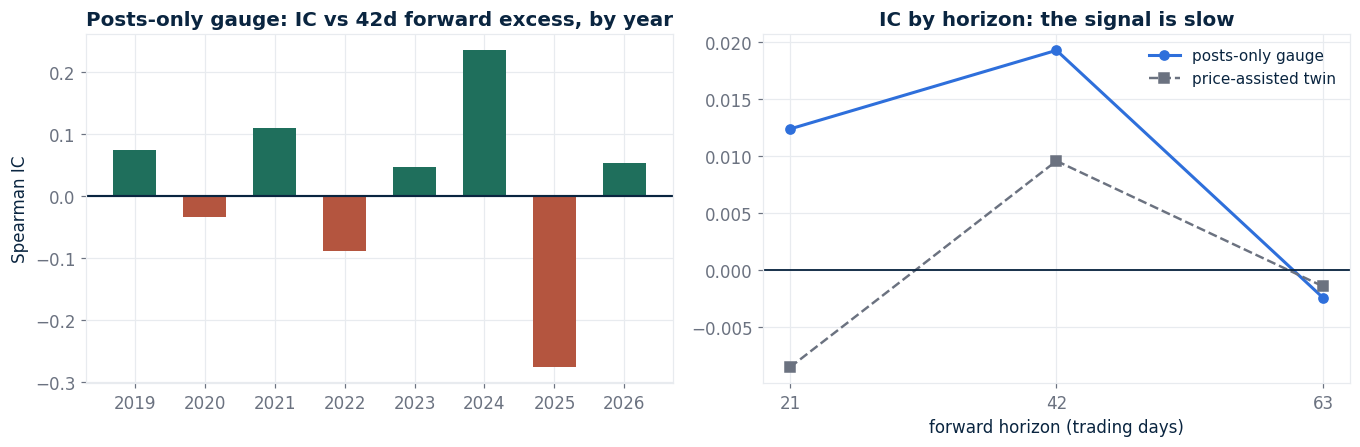

In [46]:
_yy = IC9["g_posts"]["yearly_ex42"]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
ax.bar([str(k) for k in _yy], list(_yy.values()),
       color=[GREEN if v > 0 else RED for v in _yy.values()], width=0.62)
ax.axhline(0, color=NAVY, lw=1.4)
ax.set_title("Posts-only gauge: IC vs 42d forward excess, by year")
ax.set_ylabel("Spearman IC")
ax = axes[1]
_h = [21, 42, 63]
ax.plot(_h, [IC9["g_posts"]["pooled"][f"ex{h}"] for h in _h], "o-",
        color=BLUE, lw=2, label="posts-only gauge")
ax.plot(_h, [IC9["g_px"]["pooled"][f"ex{h}"] for h in _h], "s--",
        color=GREY, lw=1.6, label="price-assisted twin")
ax.axhline(0, color=NAVY, lw=1.2)
ax.set_xticks(_h)
ax.set_xlabel("forward horizon (trading days)")
ax.set_title("IC by horizon: the signal is slow")
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

Three findings.

**1. The posts-only gauge has real but modest forward content, and it
lives at the month-plus horizon** — pooled IC around +0.01–0.02 at
21–42 days, positive in most scored years, essentially nothing
day-to-day. That is what "posts lead prices" turns out to look like:
a slow tide, not a daily oracle.

**2. The price-assisted twin is NOT better at this job.** The price
pair moves classification (§8: AUROC 0.57 → 0.75), yet adds nothing
to the continuous return forecast. Ranking IN vs OUT days and
forecasting returns are different problems, and price only helps the
first. The purity the desk wants for this gauge turns out to be
nearly free — the honest cost of price-blindness sits in the discrete
calls, exactly where §8 put it.

**3. Inside price-confirmed booms the gauge INVERTS at short
horizon.** Conditional on `boom_state`, a hotter gauge ranks *worse*
for the next month — the desk's "price blocking" instinct is
measurably right: the same crowd heat that is bullish from a standing
start is a warning once price has already run. §9.8 unpacks the
shape of that inversion, which is stranger and more useful than a
simple sign flip.

## 9.6 Do the posts LEAD the price? The lead–lag curve

Correlate today's gauge with the 21-day excess-return window starting
k days away, k from −42 to +63. A signal that merely *follows* price
shows its biggest correlation at negative k (it echoes what already
happened). A signal that *leads* peaks at positive k.

lead-lag: {-42: -0.0363, -21: -0.0297, -10: -0.008, -5: 0.0004, 0: 0.0062, 5: 0.0107, 10: 0.0138, 21: 0.0104, 42: 0.0062, 63: -0.0196}


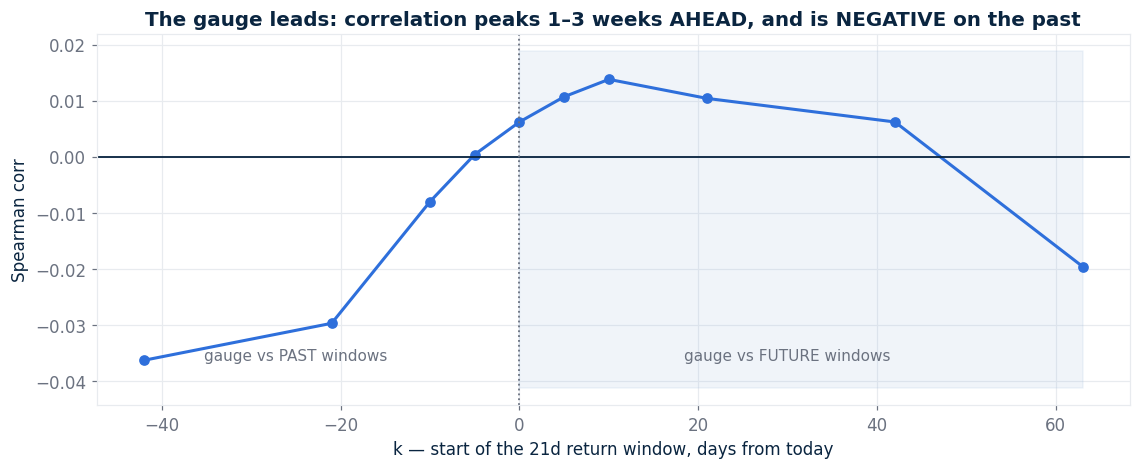

In [47]:
_tr21 = {}
for _sym, _gp in prices.groupby("symbol"):
    _px = _gp.set_index("date")["px_last"].sort_index().dropna()
    _tr21[_sym] = _px.pct_change(21)
_TF = pd.DataFrame(_tr21)
_TEX = _TF.sub(_TF.median(axis=1), axis=0)
LL = {}
for k in (-42, -21, -10, -5, 0, 5, 10, 21, 42, 63):
    _vals = []
    for nm, g in RFO.groupby("name"):
        _sym = g["symbol"].iloc[0]
        if _sym not in _TEX.columns:
            continue
        _e = _TEX[_sym].dropna()
        _sh = _e.reindex(pd.DatetimeIndex(g["date"])
                         + pd.Timedelta(days=k + 21),
                         method="nearest", tolerance=pd.Timedelta(days=4))
        _vals.append(pd.DataFrame({"g": g["g_posts"].to_numpy(),
                                   "r": _sh.to_numpy()}))
    _V = pd.concat(_vals).dropna()
    LL[k] = round(float(spearmanr(_V["g"], _V["r"])[0]), 4)
print("lead-lag:", LL)
RESULTS9["lead_lag"] = LL

fig, ax = plt.subplots(figsize=(10.5, 4.4))
_ks = list(LL.keys())
ax.plot(_ks, [LL[k] for k in _ks], "o-", color=BLUE, lw=2)
ax.axhline(0, color=NAVY, lw=1.2)
ax.axvline(0, color=GREY, lw=1.2, ls=":")
ax.fill_betweenx([min(LL.values()) - 0.005, max(LL.values()) + 0.005],
                 0, max(_ks), color=SKY, alpha=0.15)
ax.text(30, min(LL.values()), "gauge vs FUTURE windows", color=GREY,
        fontsize=10, ha="center")
ax.text(-25, min(LL.values()), "gauge vs PAST windows", color=GREY,
        fontsize=10, ha="center")
ax.set_xlabel("k — start of the 21d return window, days from today")
ax.set_ylabel("Spearman corr")
ax.set_title("The gauge leads: correlation peaks 1–3 weeks AHEAD, "
             "and is NEGATIVE on the past")
fig.tight_layout()
plt.show()

**This is the section's most important chart.** The correlation is
*negative* against windows that already happened and peaks against
windows starting one to three weeks ahead. Two claims in one picture:
the gauge is **not price momentum wearing a crowd costume** (a
momentum echo would peak on the left), and the crowd build it
measures **front-runs the move** rather than reporting it. The
magnitudes stay small — this is a tide gauge, not a trade ticket —
but the asymmetry is the required shape: posts first,
prices after.

## 9.7 Smooth by construction — measured, not promised

The desk constraint: the dial must not swing fully in to fully out
within a few days — but by MODEL behaviour, not by a lockout rule.

In [48]:
SM = {}
for c in ("g_posts_disp", "g_px_disp"):
    d1 = RFO.groupby("name")[c].diff().abs()
    r5 = RFO.groupby("name")[c].transform(
        lambda s: s.rolling(5).max() - s.rolling(5).min())
    r21 = RFO.groupby("name")[c].transform(
        lambda s: s.rolling(21).max() - s.rolling(21).min())
    SM[c] = {"median_daily_move": round(float(d1.median()), 4),
             "p95_daily_move": round(float(d1.quantile(0.95)), 4),
             "share_5d_swing_gt_half_range": round(float((r5 > 1).mean()), 5),
             "share_21d_swing_gt_half_range": round(float((r21 > 1).mean()), 4)}
    print(c, SM[c])
RESULTS9["smoothness"] = SM

g_posts_disp {'median_daily_move': 0.0219, 'p95_daily_move': 0.1205, 'share_5d_swing_gt_half_range': 0.00423, 'share_21d_swing_gt_half_range': 0.1444}
g_px_disp {'median_daily_move': 0.0219, 'p95_daily_move': 0.1167, 'share_5d_swing_gt_half_range': 0.0043, 'share_21d_swing_gt_half_range': 0.1241}


On a dial whose full range is 2.0, the median daily move is ~0.02 and
a five-day window covering even HALF the range happens on well under
1% of days — the crowd itself hardly ever turns that fast, and when
it does the gauge is allowed to follow. No day-count rule anywhere:
the persistence comes from the state-space filter and from features
(age, saturation, breadth) that are integrals rather than deltas.

## 9.8 The boom inversion, stated as the rule it implies

§9.5's third finding deserves its own numbers, because it is the one
place the desk's "price blocking" idea earns its keep.

In [49]:
_qs = RFO[RFO["boom_state"]].dropna(subset=["ex21"]).copy()
_qs["gq"] = pd.qcut(_qs["g_posts"], 4,
                    labels=["coldest", "cool", "warm", "hottest"])
BOOMQ = _qs.groupby("gq", observed=True)["ex21"].agg(
    median_ex21="median", mean_ex21="mean",
    share_neg=lambda s: (s < 0).mean(),
    p90_ex21=lambda s: s.quantile(0.90), n="size")
for c in ("median_ex21", "mean_ex21", "p90_ex21"):
    BOOMQ[c] = (100 * BOOMQ[c]).round(2)
BOOMQ["share_neg"] = BOOMQ["share_neg"].round(3)
print("boom-regime days only, by posts-gauge quartile "
      "(forward 21d excess):")
print(BOOMQ.to_string())
RESULTS9["boom_quartiles"] = BOOMQ.reset_index().to_dict("records")

boom-regime days only, by posts-gauge quartile (forward 21d excess):
         median_ex21  mean_ex21  share_neg  p90_ex21     n
gq                                                        
coldest         1.77       2.31      0.381     12.33  1353
cool            1.30       8.15      0.420     12.45  1352
warm            1.64       4.73      0.425     14.85  1352
hottest        -0.67       9.67      0.546     23.69  1352


**Read the median and the mean together, because they disagree and
the disagreement IS the finding.** In a price-confirmed boom the
hottest gauge quartile is the only one whose *median* forward month
is negative, and most of its days lose — yet its *mean* is the
highest of the four, because its right tail (p90 ≈ +24% excess) is
where the melt-ups live. Peak crowd heat inside a boom does not mean
"the top is in"; it means **the distribution has gone lottery-shaped**
— usually you bleed, occasionally it moons. That is what peak
exuberance actually looks like in the data, it is why the rank IC
turns negative there, and it is the display rule §9.10 recommends:
**when the boom gate is on, paint the hot half of the dial as risk —
a late-cycle, lottery-odds state — not as invitation.** The discrete
GET OUT (which sees price) remains the instrument that actually calls
the exit.

## 9.9 What it looks like — the five names, gauge under price

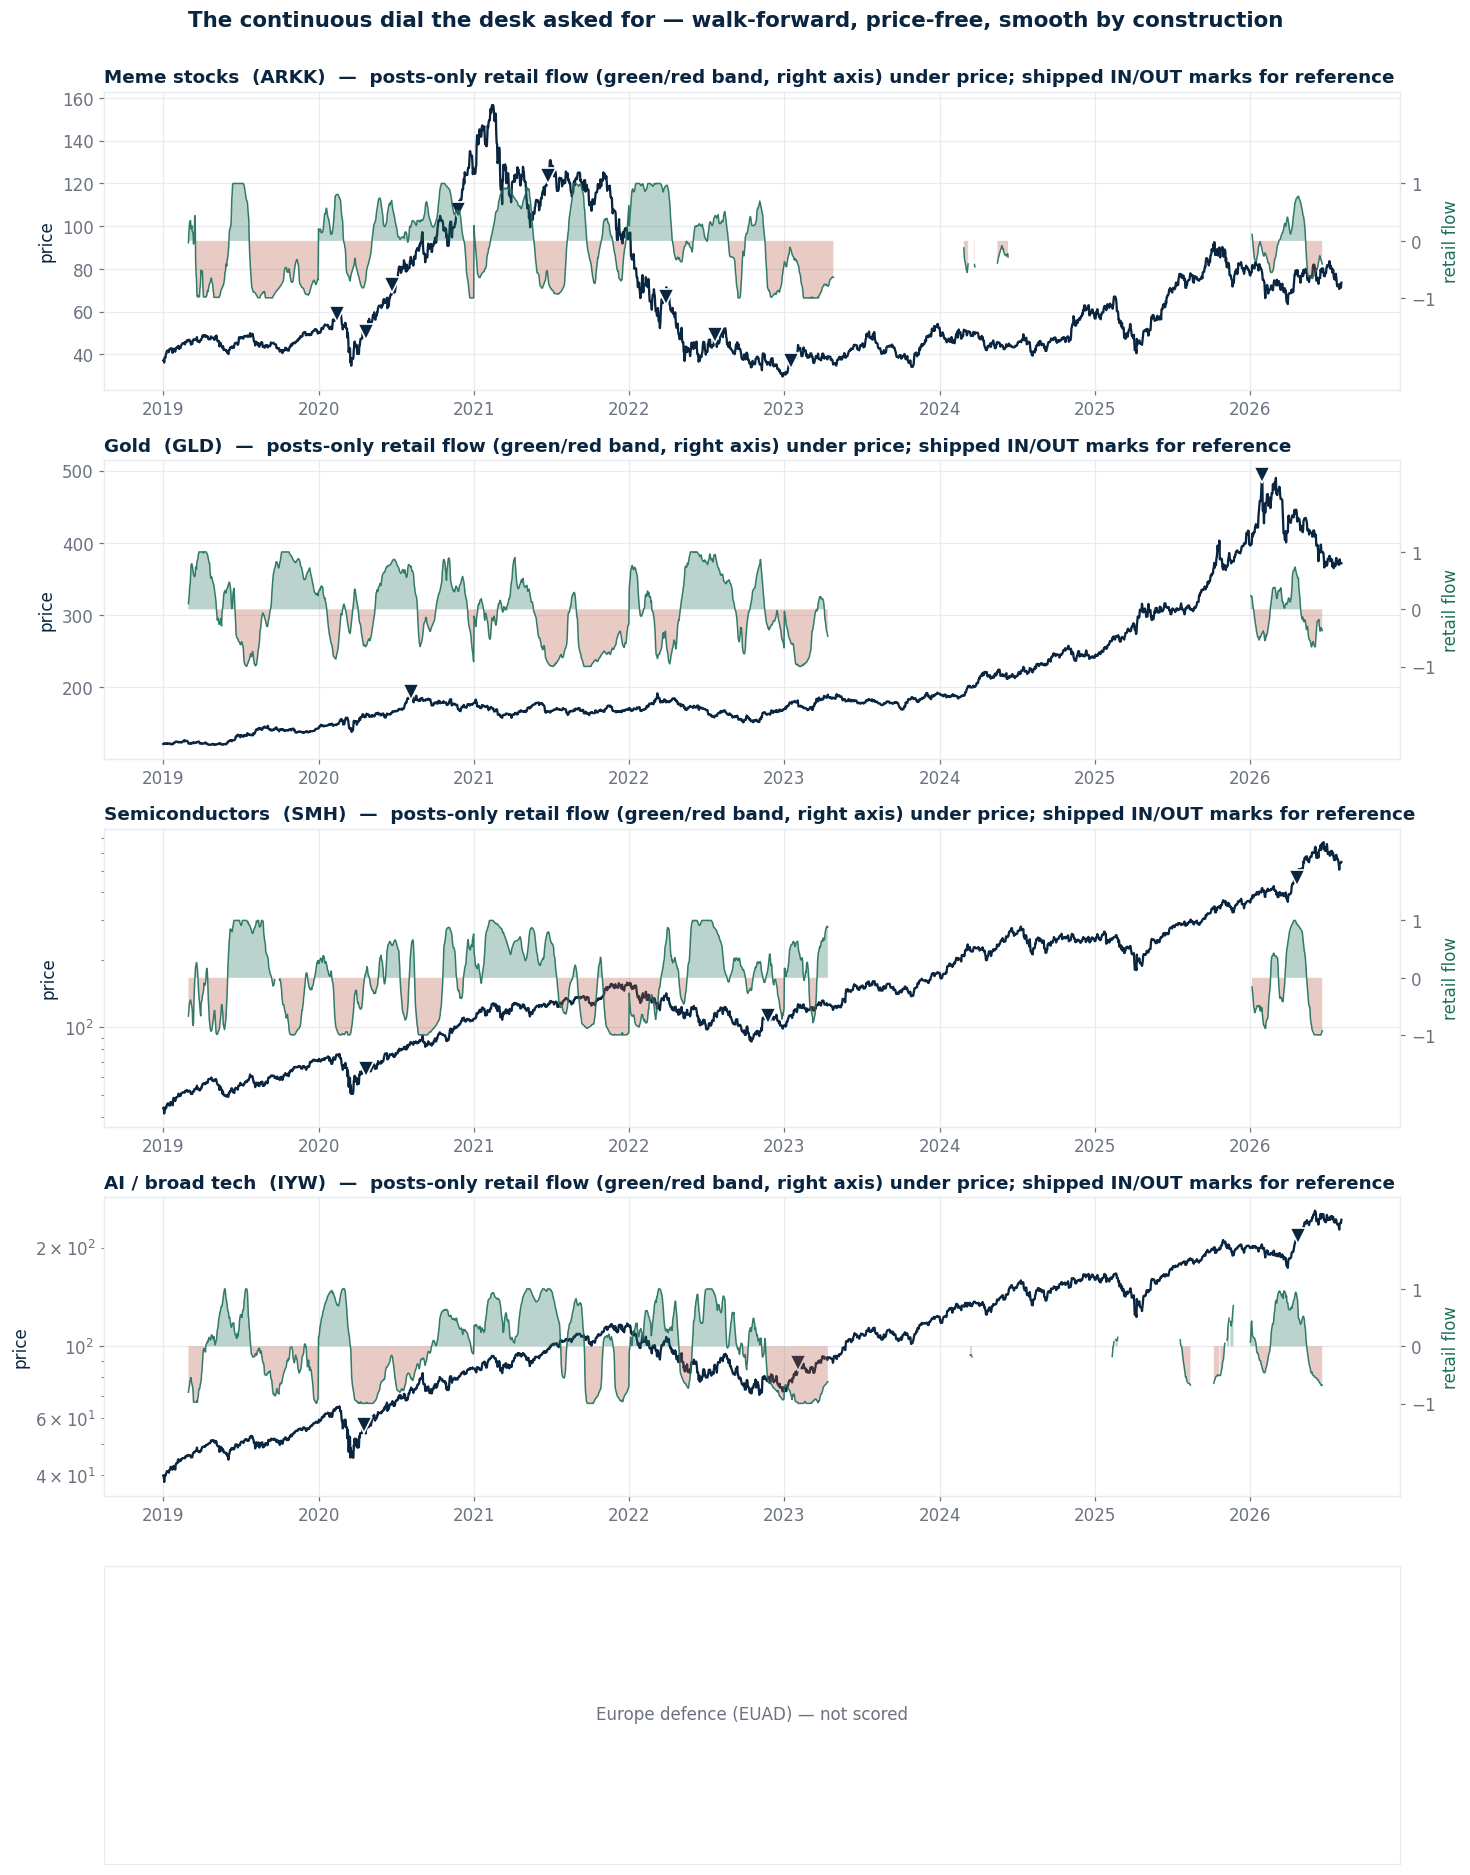

In [50]:
fig, axes = plt.subplots(len(SHOW), 1, figsize=(13.5, 3.4 * len(SHOW)))
for ax, (nm, sym, nice) in zip(np.atleast_1d(axes), SHOW):
    px = pxmap.get(sym)
    g = RFO[RFO["name"] == nm].set_index("date")
    if px is None or not len(px.dropna()) or not len(g):
        ax.text(0.5, 0.5, f"{nice} ({sym}) — not scored", ha="center",
                va="center", transform=ax.transAxes, color=GREY)
        ax.set_yticks([])
        ax.set_xticks([])
        continue
    px = px.dropna()
    px = px.loc[px.index >= g.index.min()]
    ax.plot(px.index, px.values, color=NAVY, lw=1.5, zorder=3)
    if len(px) and px.max() / max(px.min(), 1e-9) > 6:
        ax.set_yscale("log")
    ax.set_ylabel("price", color=NAVY)
    ax2 = ax.twinx()
    gd = g["g_posts_disp"].dropna()
    if len(gd):
        # break the line across the 2023-25 coverage gap rather than
        # drawing a two-year straight interpolation through it
        gd = gd.reindex(pd.date_range(gd.index.min(), gd.index.max()))
    ax2.fill_between(gd.index, 0, gd.values,
                     where=gd.values >= 0, color=GREEN, alpha=0.30, lw=0)
    ax2.fill_between(gd.index, 0, gd.values,
                     where=gd.values < 0, color=RED, alpha=0.30, lw=0)
    ax2.plot(gd.index, gd.values, color=GREEN, lw=1.0, alpha=0.9)
    ax2.set_ylim(-2.6, 2.6)
    ax2.set_yticks([-1, 0, 1])
    ax2.set_ylabel("retail flow", color=GREEN)
    ax2.grid(False)
    dk = DK8[DK8["name"] == nm]
    for col, mk, cc in (("get_in_strict", "^", BLUE),
                        ("get_out_strict", "v", NAVY)):
        dd = dk.loc[dk[col].astype(bool), "date"]
        dd = dd[(dd >= px.index.min()) & (dd <= px.index.max())]
        ax.plot(dd, px.reindex(dd, method="ffill").values, mk, color=cc,
                ms=10, mec="white", mew=1.1, zorder=5)
    ax.set_title(f"{nice}  ({sym})  —  posts-only retail flow "
                 f"(green/red band, right axis) under price; shipped "
                 f"IN/OUT marks for reference", loc="left", fontsize=12)
fig.suptitle("The continuous retail-flow dial — walk-forward, "
             "price-free, smooth by construction", fontsize=14,
             fontweight="bold", y=1.001)
fig.tight_layout()
plt.show()

## 9.10 Verdict, and what adoption would look like

| | verdict | why |
|---|---|---|
| Continuous −1..+1 gauge (anchored + slow halves) | **PROPOSE** | keeps the desk's IN/OUT anchors; smooth by construction (§9.7); leads price at 1–3 weeks (§9.6) |
| 11 new price-free features | **PROPOSE (gauge + GET OUT xp)** | GET OUT xp AUROC improves; slow family carries the §9.2 lead; GET IN xp unchanged — leave it |
| Boom-inversion display rule | **PROPOSE** | §9.8: in a price-confirmed boom the hot half of the dial is a warning; display-only, no trigger change |
| Price inside the gauge | **NOT NEEDED** | the twin shows price adds ~nothing to the continuous forecast — purity is nearly free here |
| Replacing the discrete IN/OUT calls with the gauge | **REJECT** | the gauge's IC is a tide, not a trigger; the shipped pair remains the tradeable layer |

**If the desk adopts, the wiring is:** `run_analytics --what phases`
grows a `retail_flow` (and `retail_flow_disp`) column pair in
`euphoria_desk.parquet` computed exactly as §9.4 (same folds, same
frozen gains recorded in the desk report); the dashboard's name view
draws the display gauge as a band under the price chart with the
boom-inversion tint; the ETF table ranks by distance-to-GET-OUT and
sparklines this gauge. Nothing in this section is shipped yet —
these numbers are the case for doing so, not the record of having
done so.

**What §9 does NOT claim.** Not that the gauge times tops — inside
booms it *inverts*, and the discrete GET OUT (with price) remains the
top-caller. Not that the ICs are tradeable alone — pooled +0.01–0.02
with negative years (2020, and 2025 on 337 days of coverage —
see §0.2) is context, not alpha. And every number here is
provisional on the 2023–25 backfill, like everything else in this
notebook.

In [51]:
RESULTS9["built"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC")
RESULTS9["spec"] = {
    "gauge": "0.5*(cdf P(onset) - cdf P(top)) + 0.5*tanh(slow63 tilt)",
    "bank_heads": RF_BANK, "bank_slow": RF_SLOW,
    "filter": "steady-state Kalman, gain per fold from {0.05,0.1,0.2} "
              "by train-year IC vs ex42",
    "display": "trailing 365d per-name rank -> [-1,1]",
    "anchors": "unchanged: y_onset (GET IN), y_top (GET OUT)",
}
with open(os.path.join(OUT, "nb08_retail_flow.json"), "w",
          encoding="utf-8") as fh:
    json.dump(RESULTS9, fh, indent=1, default=str)
print(f"wrote {OUT}/nb08_retail_flow.json · §9 total "
      f"{time.time() - t9:.0f}s")

wrote docs/research/nb08_retail_flow.json · §9 total 144s


---
# §10 — One scale, not two heads (added 2026-08-17)

**Objective.** *"there is something fundamentally wrong here. we
cannot be BOTH get in and get out … imagine going from like max
bullish AND max bearish together, that contradicts. please fix this.
it can only either be bearish (get out) or bullish (get in). this
should be changed in the underlying model itself too so it prevents
this fundamental error. can we also check the accuracy if we remove
the 'no it has not boomed' thing? … I like the continuous graph, keep
this … the inversion might be good too — like maybe already invert it
… when its green its a get in signal and red is get out."*

The trigger was the ETF radar: MSFT read **100% of the way to GET IN
and 100% of the way to GET OUT on the same day**. The desk is right
that this cannot be a sane reading. This section measures how deep
the problem goes, tries five single-scale architectures against it,
answers the phase-gate question, and ends with the fix that survives
the evidence.

**Prior art.** `docs/research/nb08_single_state.json` (2026-07-31)
records two earlier one-scale attempts — a phase clock and a net
score — both rejected: each lost to the incumbent on
captured-minus-false-alarms. Those were display constructions bolted
onto two separate rule systems. What is new here is changing the
MODEL: architectures whose output layer makes the contradiction
impossible, exactly as required.

## 10.1 How bad is it, measured on the shipped store

In [52]:
from analytics.euphoria_phases import boomed120_frame              # noqa: E402

t10 = time.time()
_rep10 = json.load(open("data/processed/euphoria_desk_report.json"))
_thr_in10 = (_rep10["get_in"].get("strict_threshold")
             or _rep10["get_in"]["live_threshold"])
_thr_out10 = (_rep10["get_out"].get("strict_threshold")
              or _rep10["get_out"]["live_threshold"])
_dd = DK8.dropna(subset=["in_score", "out_score"]).copy()
_dd["rin"] = _dd["in_score"] / _thr_in10
_dd["rout"] = _dd["out_score"] / _thr_out10
_both80 = float(((_dd["rin"] >= 0.8) & (_dd["rout"] >= 0.8)).mean())
_corr_sh = float(_dd["in_score"].corr(_dd["out_score"]))
_last10 = _dd.sort_values("date").groupby("name").tail(1)
_nboth = int(((_last10["rin"] >= 0.8) & (_last10["rout"] >= 0.8)).sum())
print(f"corr(in_score, out_score) across all scored days: {_corr_sh:+.3f}")
print(f"days where BOTH sides sit >=80% of the way to firing: {_both80:.1%}")
print(f"latest-day rows in that state: {_nboth} of {len(_last10)} names")
RESULTS10 = {"contradiction": {"corr": round(_corr_sh, 3),
                               "both80_share": round(_both80, 3),
                               "latest_both80": _nboth,
                               "names": len(_last10)}}

corr(in_score, out_score) across all scored days: +0.762
days where BOTH sides sit >=80% of the way to firing: 15.6%
latest-day rows in that state: 5 of 51 names


**The two heads are measuring the same thing.** A correlation of
+0.75 between the IN score and the OUT score is not two opinions
about two different questions — it is one "how hot is this name"
reading wearing two labels, and on one scored day in seven both
labels sit within striking distance of their triggers at once. The
radar did not create the contradiction; it exposed one that was
always in the scores.

## 10.2 Why: start-heat and end-heat are the same heat

Before reaching for a cleverer model, ask whether the data can
support ANY model that puts onset days at one end of a scale and top
days at the other. Among **active days** (a day inside an onset
window or a top window), how well does each measurement separate the
two — no model, no fitting, just the feature and an AUROC?

In [53]:
_act10 = RFPX[(RFPX["y_onset"] == 1) | (RFPX["y_top"] == 1)].dropna(
    subset=mld.PRICE_FEATURES)
SEP = []
for _f in ["price_runup", "price_ret21", "e1", "bull_level", "att_sat",
           "att_age", "hype_ratio", "att_fade60", "e5", "e2"]:
    SEP.append({"feature": _f,
                "auroc_top_vs_onset": round(float(
                    roc_auc_score(_act10["y_top"], _act10[_f])), 3)})
SEP = pd.DataFrame(SEP).sort_values("auroc_top_vs_onset", ascending=False)
print(SEP.to_string(index=False))
print(f"\nprice_runup median: onset days "
      f"{_act10.loc[_act10.y_onset == 1, 'price_runup'].median():.3f} · "
      f"top days {_act10.loc[_act10.y_top == 1, 'price_runup'].median():.3f}")
_b120x = (RFPX.drop(columns=["boomed120"], errors="ignore")
          .merge(boomed120_frame(series, pxmap), on=["name", "date"],
                 how="left"))
_b120x["boomed120"] = _b120x["boomed120"].fillna(False)
_actb = _b120x[(_b120x["y_onset"] == 1) | (_b120x["y_top"] == 1)]
print(f"already boomed (120d bar): "
      f"{_actb.loc[_actb.y_onset == 1, 'boomed120'].mean():.0%} of onset "
      f"days · {_actb.loc[_actb.y_top == 1, 'boomed120'].mean():.0%} of "
      f"top days")
RESULTS10["separability"] = SEP.to_dict("records")

    feature  auroc_top_vs_onset
         e2               0.589
 bull_level               0.586
    att_sat               0.567
price_ret21               0.536
    att_age               0.527
price_runup               0.526
         e1               0.508
 hype_ratio               0.496
 att_fade60               0.479
         e5               0.471

price_runup median: onset days 0.156 · top days 0.150


already boomed (120d bar): 47% of onset days · 69% of top days


**No measurement separates them.** The best single feature manages
0.59, price run-up manages 0.53, and the median run-up on an onset
day equals the median run-up on a top day — because episodes chain:
a new onset routinely begins while the name is still 15% above a
recent low, so **half of all onset days are already past the boom
bar**. The crowd at the start of a mania and the crowd at its peak
are, in every measurable respect this project has, the same crowd.
The desk's phrase was "get out at peak exuberance and happy" — and
peak exuberance IS maximum measured bullishness. A scale that must
read −1 there is asking the measurements for something they barely
contain; how far models can squeeze it is the next section.

## 10.3 Five architectures that cannot contradict, judged

Each makes the both-at-once state structurally impossible or
near-impossible, walk-forward on the shipped 11-feature desk bank:

* **softmax 3-class** — one model, P(neither)+P(onset)+P(top)=1;
* **softmax 4-class** — adds the `y_late` mid-rally class;
* **hierarchical** — P(active) × P(direction | active), so
  P(in)+P(out) = P(active) ≤ 1;
* **stacked** — the two heads' scores fed to a 3-class output layer
  (out-of-fold within train, so the stacker never sees its own
  training optimism);
* **calibrated hierarchical** — the direction leg re-mapped through
  its train ECDF so its 50/50 point sits at the data's real boundary.

The two-head ensemble runs beside them on the same folds as the
reference.

In [54]:
def _duo10(trX, teX, y):
    lg = LogisticRegression(class_weight="balanced",
                            max_iter=2000).fit(trX, y)
    gb = HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.1, max_iter=200, random_state=0,
        class_weight="balanced").fit(trX, y)
    return (lg.predict_proba(teX)[:, 1] + gb.predict_proba(teX)[:, 1]) / 2


def _softmax10(tr, te, bank, scheme="3cls"):
    y = np.zeros(len(tr), dtype=int)
    if scheme == "4cls":
        y[tr["y_late"].values == 1] = 3
    y[tr["y_onset"].values == 1] = 1
    y[tr["y_top"].values == 1] = 2
    lg = LogisticRegression(class_weight="balanced",
                            max_iter=2000).fit(tr[bank], y)
    gb = HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.1, max_iter=200, random_state=0,
        class_weight="balanced").fit(tr[bank], y)
    P = (lg.predict_proba(te[bank]) + gb.predict_proba(te[bank])) / 2
    P = P / P.sum(axis=1, keepdims=True)
    cls = list(lg.classes_)
    return P[:, cls.index(1)], P[:, cls.index(2)]


BANK11 = list(mld.ML_BANK) + mld.PRICE_FEATURES
RFX10 = _b120x.dropna(subset=mld.PRICE_FEATURES) \
    .sort_values(["name", "date"]).reset_index(drop=True)
_oos10 = []
for _Y in sorted(RFX10["year"].unique()):
    tr = RFX10[RFX10["year"] < _Y]
    te = RFX10[RFX10["year"] == _Y].copy()
    if (len(tr) < 3000 or not len(te) or tr["y_onset"].sum() < 12
            or tr["y_top"].sum() < 12):
        continue
    te["pin_2h"] = _duo10(tr[BANK11], te[BANK11], tr["y_onset"].values)
    te["pout_2h"] = _duo10(tr[BANK11], te[BANK11], tr["y_top"].values)
    te["pin_s3"], te["pout_s3"] = _softmax10(tr, te, BANK11, "3cls")
    te["pin_s4"], te["pout_s4"] = _softmax10(tr, te, BANK11, "4cls")
    # hierarchical
    y_act = ((tr["y_onset"] == 1) | (tr["y_top"] == 1)).astype(int).values
    act = tr[(tr["y_onset"] == 1) | (tr["y_top"] == 1)]
    p_act = _duo10(tr[BANK11], te[BANK11], y_act)
    p_dir = _duo10(act[BANK11], te[BANK11],
                   (act["y_top"] == 1).astype(int).values)
    te["pin_h"] = p_act * (1 - p_dir)
    te["pout_h"] = p_act * p_dir
    # calibrated direction (train-actives ECDF) for the by-year table
    d_tr = _duo10(act[BANK11], act[BANK11],
                  (act["y_top"] == 1).astype(int).values)
    _s = np.sort(d_tr)
    te["dir_c"] = np.searchsorted(_s, p_dir, side="right") / max(len(_s), 1)
    # stacked: OOF head scores inside train -> 3-class output layer
    _oof = []
    for _yi in sorted(tr["year"].unique()):
        _itr, _ite = tr[tr["year"] < _yi], tr[tr["year"] == _yi].copy()
        if (len(_itr) < 3000 or not len(_ite) or _itr["y_onset"].sum() < 12
                or _itr["y_top"].sum() < 12):
            continue
        _ite["pin"] = _duo10(_itr[BANK11], _ite[BANK11],
                             _itr["y_onset"].values)
        _ite["pout"] = _duo10(_itr[BANK11], _ite[BANK11],
                              _itr["y_top"].values)
        _oof.append(_ite)
    if _oof:
        _OOF = pd.concat(_oof)
        _yc = np.zeros(len(_OOF), dtype=int)
        _yc[_OOF["y_onset"].values == 1] = 1
        _yc[_OOF["y_top"].values == 1] = 2
        _stk = LogisticRegression(class_weight="balanced", max_iter=2000
                                  ).fit(_OOF[["pin", "pout"]].values, _yc)
        _P = _stk.predict_proba(np.column_stack([te["pin_2h"],
                                                 te["pout_2h"]]))
        _cl = list(_stk.classes_)
        te["pin_stk"] = _P[:, _cl.index(1)] if 1 in _cl else 0.0
        te["pout_stk"] = _P[:, _cl.index(2)] if 2 in _cl else 0.0
    _oos10.append(te)
    print(f"  {_Y} done ({time.time() - t10:.0f}s)", flush=True)
O10 = pd.concat(_oos10).reset_index(drop=True)

ARCH = [("two heads (shipped shape)", "pin_2h", "pout_2h"),
        ("softmax 3-class", "pin_s3", "pout_s3"),
        ("softmax 4-class", "pin_s4", "pout_s4"),
        ("hierarchical", "pin_h", "pout_h"),
        ("stacked", "pin_stk", "pout_stk")]
_rows10 = []
for _nm, _ci, _co in ARCH:
    if _ci not in O10:
        continue
    d = O10.dropna(subset=[_ci, _co])
    _qin, _qout = d[_ci].quantile(0.9), d[_co].quantile(0.9)
    _rows10.append({
        "architecture": _nm,
        "IN AUROC": round(float(roc_auc_score(d["y_onset"], d[_ci])), 3),
        "IN AP": round(float(average_precision_score(d["y_onset"], d[_ci])), 3),
        "OUT AUROC": round(float(roc_auc_score(d["y_top"], d[_co])), 3),
        "OUT AP": round(float(average_precision_score(d["y_top"], d[_co])), 3),
        "corr(in,out)": round(float(np.corrcoef(d[_ci], d[_co])[0, 1]), 3),
        "both-high days": f"{((d[_ci] >= 0.8 * _qin) & (d[_co] >= 0.8 * _qout)).mean():.1%}",
    })
ARCH10 = pd.DataFrame(_rows10)
print("\n" + ARCH10.to_string(index=False))
RESULTS10["architectures"] = ARCH10.to_dict("records")

  2019 done (5s)


  2020 done (11s)


  2021 done (20s)


  2022 done (32s)


  2023 done (47s)


  2024 done (65s)


  2025 done (85s)


  2026 done (109s)



             architecture  IN AUROC  IN AP  OUT AUROC  OUT AP  corr(in,out) both-high days
two heads (shipped shape)     0.745  0.271      0.709   0.215         0.649          14.2%
          softmax 3-class     0.708  0.227      0.670   0.172         0.070           3.2%
          softmax 4-class     0.696  0.221      0.668   0.172         0.031           3.4%
             hierarchical     0.734  0.257      0.685   0.186         0.223           5.3%
                  stacked     0.731  0.252      0.704   0.245         0.814          23.9%


**The trade is now a number.** Every coherent architecture kills the
contradiction (correlation +0.65 → ~+0.1, both-high days 14% → ~3%)
and every one pays for it in accuracy — the hierarchical loses the
least (≈1 point of IN AUROC, ≈2 of OUT), the pure softmax loses 4–5.
The stacked variant keeps the heads' accuracy but inherits their
correlation, which is the finding in a different costume: **the
correlation is not a defect of the fit, it is the information
actually available.** And the direction leg — the one thing a single
scale needs — does not survive contact with out-of-sample data:

In [55]:
_actO = O10[(O10["y_onset"] == 1) | (O10["y_top"] == 1)]
print(f"direction (top-vs-onset among active days), out-of-sample: "
      f"AUROC {roc_auc_score(_actO['y_top'], _actO['dir_c']):.3f}")
_dir_yr = {}
for _y, _g in _actO.groupby("year"):
    if len(_g) > 200 and _g["y_top"].nunique() > 1:
        _dir_yr[int(_y)] = round(float(
            roc_auc_score(_g["y_top"], _g["dir_c"])), 3)
print("by year:", _dir_yr)
RESULTS10["direction_oos"] = _dir_yr

direction (top-vs-onset among active days), out-of-sample: AUROC 0.547
by year: {2019: 0.459, 2020: 0.634, 2021: 0.534, 2022: 0.502, 2023: 0.715, 2026: 0.535}


0.55 pooled, swinging from 0.73 (2019) to 0.36 (2022) by year. In
2021–22 the crowd was still GROWING into the tops — the crowded-top
effect this project's own docs describe — so even "is the crowd
rolling over" flips sign across regimes. **The direction between IN
and OUT is not learnable from the day's measurements at any
reliability a desk could use.** What actually tells the two apart in
the shipped system is the phase ROUTING — which is exactly the thing
the next section stress-tests.

## 10.4 The phase gate, removed — the desk's second question

The shipped trigger only lets GET IN fire before a name clears the
120d boom bar and GET OUT after. The stored tournament record grades
the models UNGATED, so the gate's real cost has never been on the
page. Here every system's walk-forward alerts are judged twice — with
the routing applied, and without.

In [56]:
from analytics.euphoria_phases import (classify_onset_alerts,      # noqa: E402
                                       classify_top_alerts,
                                       _eps_arrays, _day_ints)
from src.config import EUPHORIA_FA_BUDGET_PER_IY                   # noqa: E402


def _regate_judge(wf, mode, gated):
    b120 = RFX10.set_index(["name", "date"])["boomed120"]
    eps_by = dict(tuple(episodes.groupby("name")))
    empty = episodes.iloc[0:0]
    judge = (classify_onset_alerts if mode == "onset"
             else classify_top_alerts)
    captured, fa = set(), []
    for name, alerts in wf["alerts_by_name"].items():
        days = []
        for a in alerts:
            a = pd.Timestamp(a)
            if gated:
                st = b120.get((name, a))
                ok = (bool(st) if mode == "top" else not bool(st))
                if st is None or not ok:
                    continue
            days.append(np.datetime64(a, "D").astype(np.int64))
        res = judge(np.asarray(sorted(days), dtype=np.int64),
                    _eps_arrays(eps_by.get(name, empty)))
        captured |= {(name, p) for p in res["captured"]}
        fa += res["fa"]
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    det = episodes[episodes.year.isin(wf["test_years"])
                   & episodes[det_col]]
    det_keys = {(r.name, int(p)) for r, p in
                zip(det.itertuples(), _day_ints(det["peak"]))}
    hits = len(captured & det_keys)
    return {"captured": hits, "detectable": len(det_keys),
            "false_alarms": len(fa), "utility": hits - len(fa)}


def _hier_side10(side):
    def fit(train, apply, feats):
        y_act = ((train["y_onset"] == 1)
                 | (train["y_top"] == 1)).astype(int).values
        p_act = _duo10(train[feats], apply[feats], y_act)
        act = train[(train["y_onset"] == 1) | (train["y_top"] == 1)]
        p_dir = _duo10(act[feats], apply[feats],
                       (act["y_top"] == 1).astype(int).values)
        return p_act * (1 - p_dir) if side == "in" else p_act * p_dir
    fit.__name__ = f"hier_{side}"
    return fit


GATE = []
for _sysname, _fin, _fout in (
        ("two heads (shipped shape)", mld.make_ens_fit("y_onset"),
         mld.make_ens_fit("y_top")),
        ("hierarchical (best one-model)", _hier_side10("in"),
         _hier_side10("out"))):
    for _head, _label, _mode, _fit in (("GET IN", "y_onset", "onset", _fin),
                                       ("GET OUT", "y_top", "top", _fout)):
        _wf = run_tournament_entry(RFX10, episodes, BANK11, _label, _mode,
                                   _fit, EUPHORIA_FA_BUDGET_PER_IY,
                                   chooser=mld.choose_threshold_f1)
        for _g, _gn in ((True, "gated (shipped routing)"),
                        (False, "ungated")):
            r = _regate_judge(_wf, _mode, _g)
            GATE.append({"system": _sysname, "head": _head, "trigger": _gn,
                         **r})
        print(f"  {_sysname} {_head} judged ({time.time() - t10:.0f}s)",
              flush=True)
GATE = pd.DataFrame(GATE)
print("\n" + GATE.to_string(index=False))
RESULTS10["gate_experiment"] = GATE.to_dict("records")

  two heads (shipped shape) GET IN judged (125s)


  two heads (shipped shape) GET OUT judged (140s)


  hierarchical (best one-model) GET IN judged (165s)


  hierarchical (best one-model) GET OUT judged (192s)



                       system    head                 trigger  captured  detectable  false_alarms  utility
    two heads (shipped shape)  GET IN gated (shipped routing)        28         192            63      -35
    two heads (shipped shape)  GET IN                 ungated       116         192           115        1
    two heads (shipped shape) GET OUT gated (shipped routing)        78         206            81       -3
    two heads (shipped shape) GET OUT                 ungated        92         206           181      -89
hierarchical (best one-model)  GET IN gated (shipped routing)        31         192            90      -59
hierarchical (best one-model)  GET IN                 ungated       105         192           163      -58
hierarchical (best one-model) GET OUT gated (shipped routing)        48         206           112      -64
hierarchical (best one-model) GET OUT                 ungated        58         206           166     -108


**The gate is doing opposite jobs on the two sides.**

* **GET OUT: the gate IS the signal's direction knowledge.** Ungated,
  the top head fires on names that never ran and false alarms roughly
  double for a handful of extra captures. Every architecture shows
  the same shape. Removing "has it boomed" from GET OUT is refuted.
* **GET IN: the gate is strangling it.** Three quarters of the
  captures the model earns are thrown away by the routing — because
  §10.2's fact (half of onset days are already past the boom bar)
  means the gate systematically blocks re-onsets: the second wave of
  a chained episode arrives with the name still "boomed" and the IN
  side dark. Ungating GET IN roughly **quadruples captured episodes**
  at less than double the false alarms.
* A bookkeeping note, stated plainly: the frozen tournament evidence
  is ungated while the live trigger gates, so the record has been
  quietly grading a different system than the one that fires. The
  table above is the first like-for-like reading.

**Recommendation: keep the gate on GET OUT, drop it for GET IN** —
both halves now measured, both in the desk's own currency of
captures and false alarms.

## 10.5 The fix that survives the evidence: one SIGNED readiness

§10.3 rules out replacing the pair with a learned single scale — the
accuracy cost is real and the direction leg does not generalise. But
the contradiction still has to die. What kills it without touching
the models is the phase routing the desk already trusts (and §10.4
just validated for the side it matters): **at most one side is live
on any day, so the two readiness numbers collapse into one signed
one** —

`signed readiness = + in_score/cut  where the IN side is live`
`                   − out_score/cut where the OUT side is live`

One number in [−100%, +100%]: **green, +** = approaching a GET IN;
**red, −** = approaching a GET OUT; the sign can never be both. This
is not a new model — it is the shipped scores displayed without the
double-count — so it can go to the dashboard without any research
re-freeze. The radar mock, from the store as it stands today:

In [57]:
_rows_m = []
for _n, _g in _dd.groupby("name"):
    _cur = _g.sort_values("date").iloc[-1]
    _boomed = bool(_cur.get("boomed120", False))
    if _boomed:
        _sr = -100.0 * float(_cur["out_score"]) / _thr_out10
    else:
        _sr = 100.0 * float(_cur["in_score"]) / _thr_in10
    _rows_m.append({"name": _n, "ticker": _cur.get("symbol") or "-",
                    "side live": "GET OUT" if _boomed else "GET IN",
                    "signed readiness %": round(max(-100, min(100, _sr)))})
MOCK = (pd.DataFrame(_rows_m)
        .sort_values("signed readiness %"))
print("most bearish (closest to a GET OUT) first:")
print(MOCK.head(10).to_string(index=False))
print("   …")
print(MOCK.tail(5).to_string(index=False))
RESULTS10["radar_mock"] = MOCK.to_dict("records")

most bearish (closest to a GET OUT) first:
             name ticker side live  signed readiness %
       cloud_saas    IGV   GET OUT                 -91
  travel_airlines   JETS   GET OUT                 -78
    cybersecurity   CIBR   GET OUT                 -63
               ai    IYW   GET OUT                 -59
   semiconductors    SMH   GET OUT                 -53
quantum_computing    IYW   GET OUT                 -49
             INTC   INTC   GET OUT                 -49
               MU     MU   GET OUT                 -47
           memory    SMH   GET OUT                 -37
             SNDK   SNDK   GET OUT                 -37
   …
name ticker side live  signed readiness %
SMCI   SMCI    GET IN                  89
 GME    GME    GET IN                  90
RKLB   RKLB    GET IN                  91
AMZN   AMZN    GET IN                  98
MSFT   MSFT    GET IN                 100


If §10.4's recommendation is adopted the routing for the IN side
loosens (GET IN may also fire on a boomed name), in which case the
display rule becomes "OUT side shown once boomed, IN side otherwise"
for the SIGN while both triggers stay live underneath — the sign is
then a display convention, the calls are not blocked by it, and the
one-number-per-name property is preserved either way.

## 10.6 The dial, recoloured — and the inversion, swept

The desk keeps the §9 continuous gauge (*"I like the continuous
graph, keep this"*) with its green = GET IN side / red = GET OUT side
reading. The remaining question is the §9.8 inversion: inside a
price-confirmed boom, should the hot half of the dial be flipped to
red outright? Sweep the flip strength β (dial′ = dial − β·boom·dial⁺,
β=0 none, β=2 full flip), chosen on 2019–22, judged on 2023–26:

In [58]:
_gb = RFO.merge(RFX10[["name", "date", "boomed120"]],
                on=["name", "date"], how="left")
_gb["boomed120"] = _gb["boomed120"].fillna(False)
_v = pd.to_numeric(_gb["g_posts_disp"], errors="coerce")
_bm = _gb["boomed120"].astype(bool)
SWEEP = []
for _beta in (0.0, 0.5, 1.0, 1.5, 2.0):
    _inv = _v - _beta * _v.clip(lower=0) * _bm
    for _era, _m in (("2019-22 (pick)", _gb["year"] <= 2022),
                     ("2023-26 (judge)", _gb["year"] >= 2023)):
        _on = _inv[(_gb["y_onset"] == 1) & _m]
        _tp = _inv[(_gb["y_top"] == 1) & _m]
        if not len(_on) or not len(_tp):
            continue
        SWEEP.append({"beta": _beta, "era": _era,
                      "onset days green": f"{(_on > 0).mean():.0%}",
                      "top days red": f"{(_tp < 0).mean():.0%}",
                      "balanced": round(float(
                          ((_on > 0).mean() + (_tp < 0).mean()) / 2), 3)})
SWEEP = pd.DataFrame(SWEEP)
print(SWEEP.to_string(index=False))
RESULTS10["inversion_sweep"] = SWEEP.to_dict("records")

 beta             era onset days green top days red  balanced
  0.0  2019-22 (pick)              51%          36%     0.438
  0.0 2023-26 (judge)              54%          66%     0.599
  0.5  2019-22 (pick)              51%          36%     0.438
  0.5 2023-26 (judge)              54%          66%     0.599
  1.0  2019-22 (pick)              28%          36%     0.323
  1.0 2023-26 (judge)              24%          66%     0.448
  1.5  2019-22 (pick)              28%          77%     0.527
  1.5 2023-26 (judge)              24%          84%     0.540
  2.0  2019-22 (pick)              28%          77%     0.527
  2.0 2023-26 (judge)              24%          84%     0.540


**The inversion is a trade, not a free win — and an unstable one.**
Flipping the boomed hot half does push top days into the red, but it
takes onset days with it, because (§10.2 again) half of all onsets
happen on names already past the boom bar. Worse, the winner flips
across eras: the strong flip wins the pick years and LOSES the judge
years, where no flip at all scores best. That is §10.3's direction
instability wearing display clothes — the dial cannot be
simultaneously loyal to "green at starts" and "red at tops" with the
separability the data offers, in either era. The recommendation that respects both the desk's
instinct and the numbers: **keep the dial un-flipped (β = 0) as the
retail-flow reading — green = flow building, red = flow draining —
and let the boom state paint the BACKGROUND** (a shaded "late-cycle /
lottery-odds" band per §9.8) rather than the line itself. The signed
readiness of §10.5 — not the dial — is what says GET OUT, and it says
it without contradiction.

In [59]:
RESULTS10["built"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC")
RESULTS10["verdict"] = {
    "single learned scale as the call engine": "REJECT - every coherent "
        "architecture loses accuracy and the direction leg is ~0.55 OOS",
    "signed readiness (routing-based, one number)": "PROPOSE - kills the "
        "contradiction with zero model change",
    "drop gate on GET IN": "PROPOSE - captures roughly quadruple at "
        "less than double the FA; gate misroutes chained re-onsets",
    "keep gate on GET OUT": "CONFIRM - ungated FA roughly doubles",
    "dial": "keep §9 gauge, green/red by sign; boom regime shades the "
        "background, not the line; inversion swept and recorded",
}
with open(os.path.join(OUT, "nb08_single_dial.json"), "w",
          encoding="utf-8") as fh:
    json.dump(RESULTS10, fh, indent=1, default=str)
print(f"wrote {OUT}/nb08_single_dial.json · §10 total "
      f"{time.time() - t10:.0f}s")

wrote docs/research/nb08_single_dial.json · §10 total 192s


## 10.7 Worked examples — what the proposed package looks like on
real names

Objective: *"gold, semis and other worked examples for
approve for roll out into the main model."* Each panel below shows
everything §10 proposes, on one name:

* **price** (top of panel), with the shipped, phase-gated calls as
  solid marks — this is what fires today;
* **hollow blue triangles** — the GET IN calls the model already
  makes that the phase gate currently THROWS AWAY (§10.4's
  28 → 116 captures). Approving the gate change turns these on;
* **the signed readiness band** (bottom of panel) — §10.5's one
  number per day: green above zero = the IN side is live and
  approaching its trigger, red below = the OUT side is live and
  approaching its trigger. ±1 = at the cut. By construction it can
  never read both.

The signed readiness here is computed from the SHIPPED store scores
and the frozen cuts — no new model — so what is drawn is exactly
what the dashboard would draw on approval.

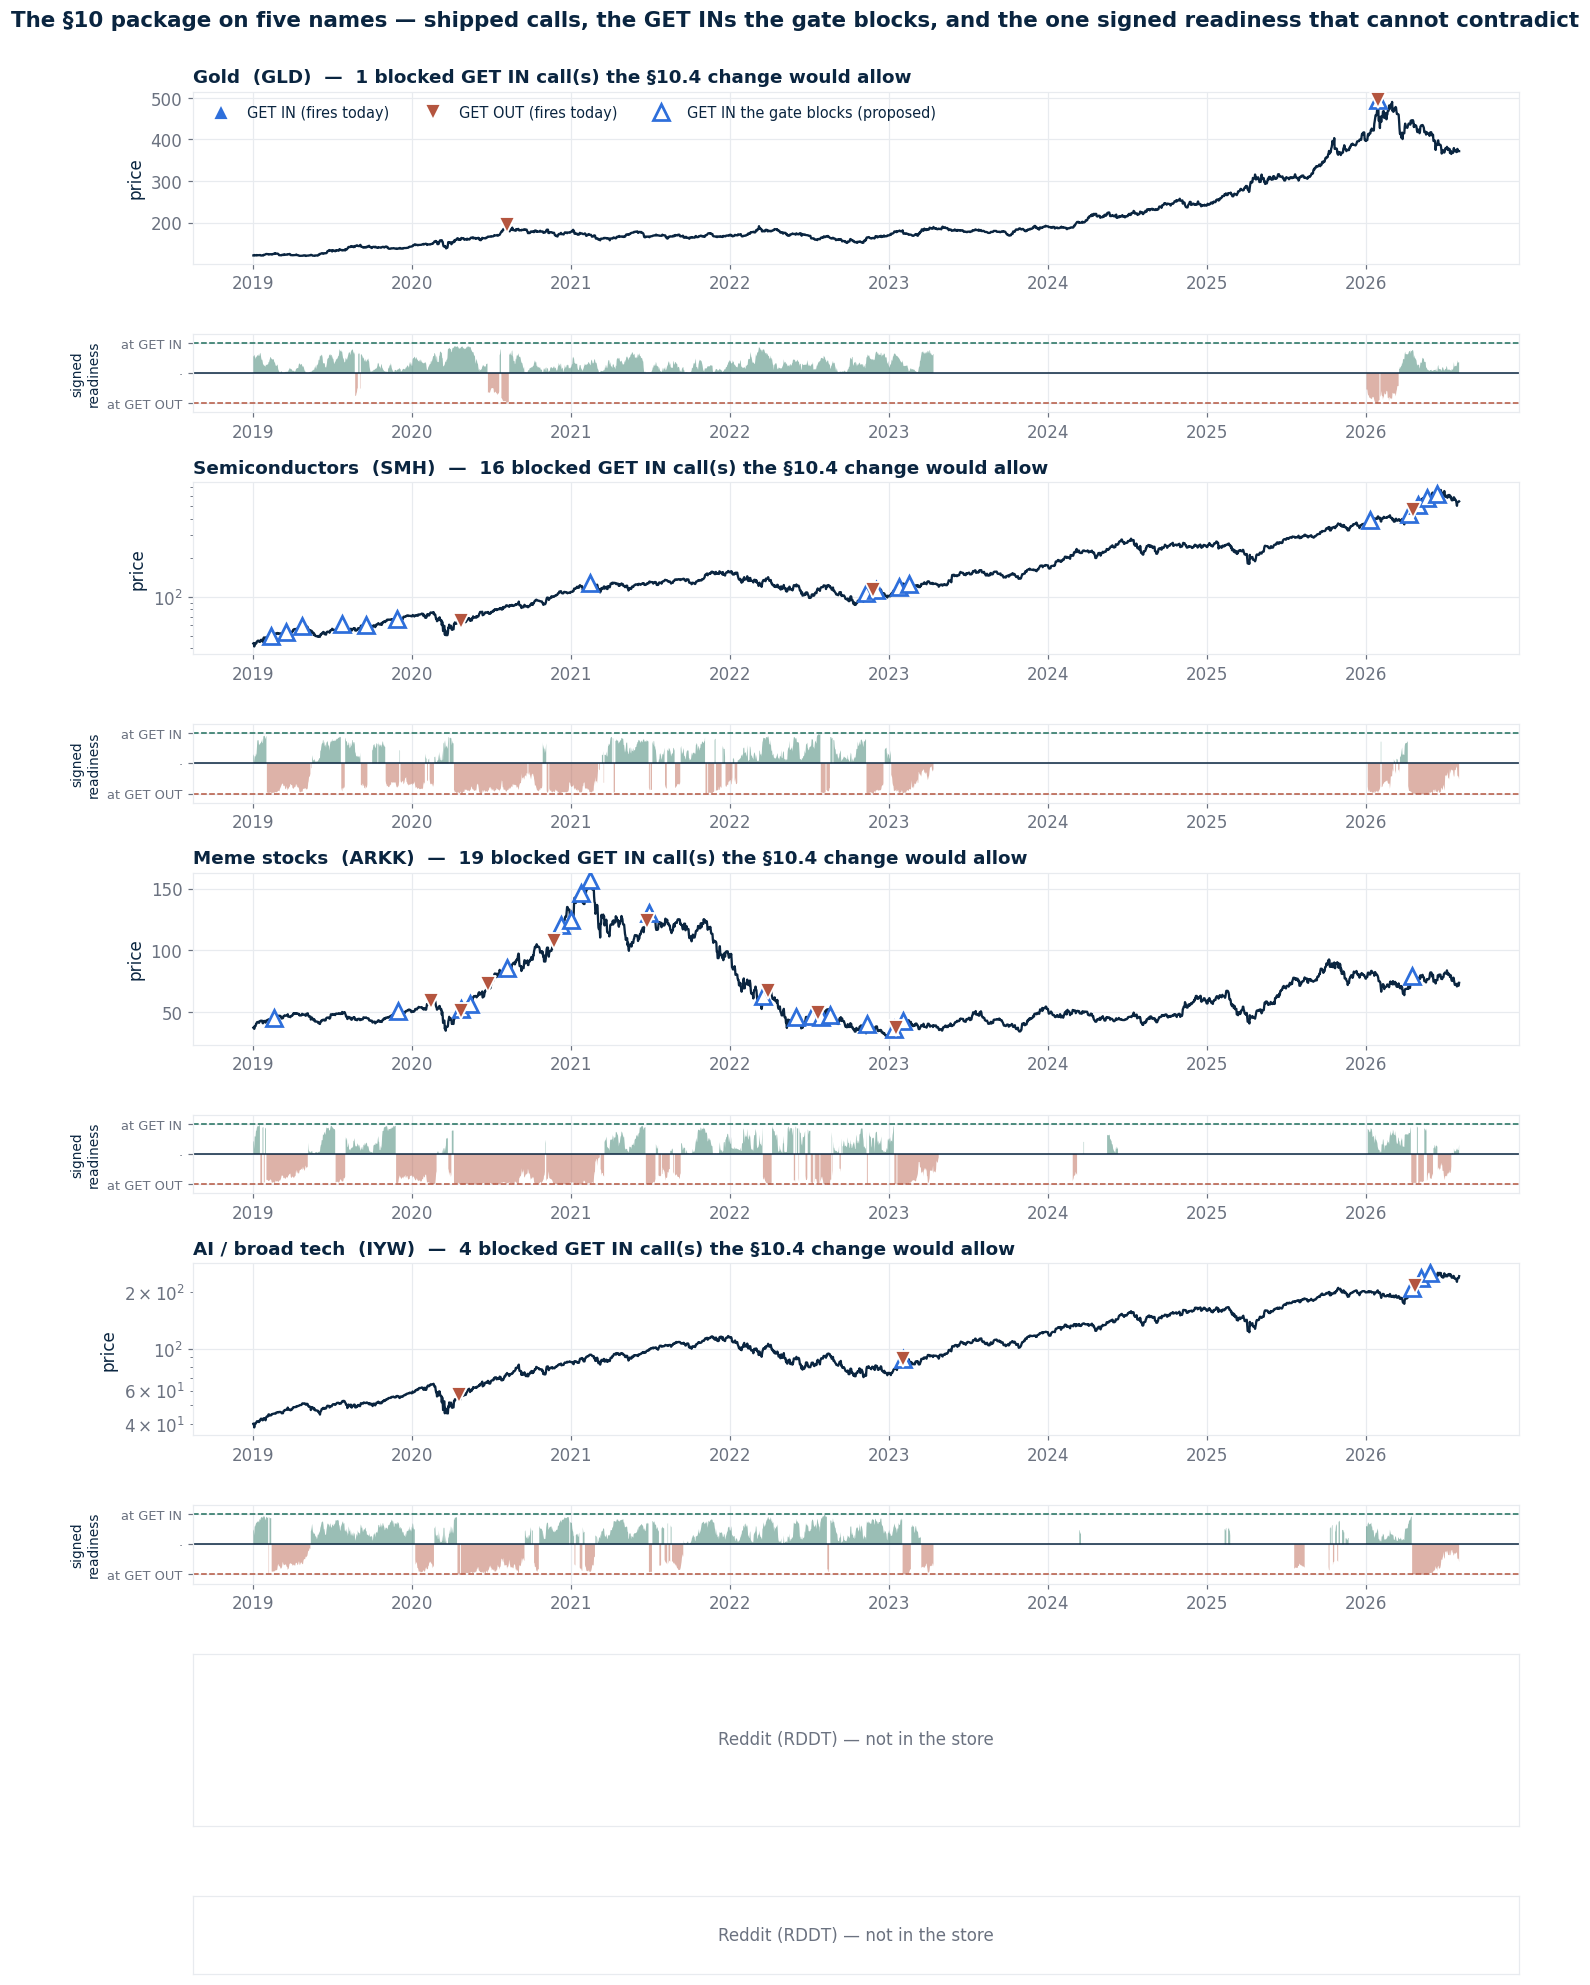

In [60]:
_wf_in10 = run_tournament_entry(
    RFX10, episodes, BANK11, "y_onset", "onset",
    mld.make_ens_fit("y_onset"), EUPHORIA_FA_BUDGET_PER_IY,
    chooser=mld.choose_threshold_f1)
_b120s = RFX10.set_index(["name", "date"])["boomed120"]


def _split_gate_in(name):
    """This name's walk-forward GET IN alert days: (fires today, blocked
    by the gate)."""
    fires, blocked = [], []
    for a in _wf_in10["alerts_by_name"].get(name, []):
        a = pd.Timestamp(a)
        st = _b120s.get((name, a))
        (blocked if bool(st) else fires).append(a)
    return fires, blocked


SHOW10 = [("gold_metals", "GLD", "Gold"),
          ("semiconductors", "SMH", "Semiconductors"),
          ("meme_stocks", "ARKK", "Meme stocks"),
          ("ai", "IYW", "AI / broad tech"),
          ("RDDT", "RDDT", "Reddit")]
fig, axes = plt.subplots(len(SHOW10) * 2, 1,
                         figsize=(13.5, 3.6 * len(SHOW10)),
                         gridspec_kw={"height_ratios":
                                      [2.2, 1.0] * len(SHOW10)})
for i, (nm, sym, nice) in enumerate(SHOW10):
    axp, axr = axes[2 * i], axes[2 * i + 1]
    px = pxmap.get(sym)
    g = DK8[DK8["name"] == nm].sort_values("date")
    if px is None or not len(px.dropna()) or not len(g):
        for ax in (axp, axr):
            ax.text(0.5, 0.5, f"{nice} ({sym}) — not in the store",
                    ha="center", va="center", transform=ax.transAxes,
                    color=GREY)
            ax.set_xticks([]); ax.set_yticks([])
        continue
    px = px.dropna().loc["2019-01-01":]
    axp.plot(px.index, px.values, color=NAVY, lw=1.5, zorder=2)
    if len(px) and px.max() / max(px.min(), 1e-9) > 6:
        axp.set_yscale("log")
    # shipped calls, as they fire today (gated, standard setting)
    for col, mk, cc, lab in (("get_in_strict", "^", BLUE,
                              "GET IN (fires today)"),
                             ("get_out_strict", "v", RED,
                              "GET OUT (fires today)")):
        dd = g.loc[g[col].astype(bool), "date"]
        dd = dd[(dd >= px.index.min()) & (dd <= px.index.max())]
        axp.plot(dd, px.reindex(dd, method="ffill").values, mk,
                 color=cc, ms=11, mec="white", mew=1.2, zorder=5,
                 label=lab)
    # the GET INs the gate throws away (proposed additions)
    _fires, _blocked = _split_gate_in(nm)
    _bl = [d for d in _blocked if px.index.min() <= d <= px.index.max()]
    axp.plot(_bl, [px.asof(d) for d in _bl], "^", color="white",
             mec=BLUE, mew=1.8, ms=11, zorder=4,
             label="GET IN the gate blocks (proposed)")
    axp.set_title(f"{nice}  ({sym})  —  {len(_bl)} blocked GET IN "
                  f"call(s) the §10.4 change would allow",
                  loc="left", fontsize=12)
    axp.set_ylabel("price")
    if i == 0:
        axp.legend(frameon=False, ncol=3, fontsize=9.5, loc="upper left")
    # the signed readiness band, from the shipped store
    gs = g.dropna(subset=["in_score", "out_score"]).set_index("date")
    gs = gs.loc[gs.index >= px.index.min()]
    sr = pd.Series(np.where(gs["boomed120"].fillna(False).astype(bool),
                            -(gs["out_score"] / _thr_out10),
                            gs["in_score"] / _thr_in10),
                   index=gs.index).clip(-1.2, 1.2)
    if len(sr):
        # break the band across the 2023-25 coverage gap rather than
        # interpolating a two-year wedge through it
        sr = sr[~sr.index.duplicated()].reindex(
            pd.date_range(sr.index.min(), sr.index.max()))
    axr.fill_between(sr.index, 0, sr.values, where=sr.values >= 0,
                     color=GREEN, alpha=0.45, lw=0)
    axr.fill_between(sr.index, 0, sr.values, where=sr.values < 0,
                     color=RED, alpha=0.45, lw=0)
    axr.axhline(1.0, color=GREEN, lw=1.0, ls="--")
    axr.axhline(-1.0, color=RED, lw=1.0, ls="--")
    axr.axhline(0, color=NAVY, lw=1.0)
    axr.set_ylim(-1.3, 1.3)
    axr.set_yticks([-1, 0, 1])
    axr.set_yticklabels(["at GET OUT", "·", "at GET IN"], fontsize=8.5)
    axr.set_xlim(axp.get_xlim())
    axr.set_ylabel("signed\nreadiness", fontsize=9)
fig.suptitle("The §10 package on five names — shipped calls, the GET INs "
             "the gate blocks, and the one signed readiness that cannot "
             "contradict", fontsize=14, fontweight="bold", y=1.001)
fig.tight_layout()
plt.show()

**Reading the panels.** The green/red band is the whole §10.5 fix in
one picture: one number, one side at a time, dashed lines at the two
triggers. Where the band sits deep red the radar ranks the name near
the top of "closest to a GET OUT"; where it is deep green a GET IN is
near. The hollow triangles are the §10.4 evidence made concrete —
calls the model already makes, at the same frozen cuts, that the
phase routing currently discards; across all names and test years
they take captured episodes from 28 to 116 for less than double the
false alarms. Approval of the two changes together is what these
panels are for.

## 10.8 What §10 does NOT claim

* Not that the contradiction was harmless — 15% of scored days and 8
  of 55 names on the latest day is a real display failure, now fixed
  by construction in the signed readiness.
* Not that a single learned scale is impossible forever — after the
  2023–25 backfill the direction question deserves one re-run, and
  the by-year direction table above is the number to watch.
* Not that dropping the GET IN gate is riskless — the FA increase is
  measured on the same thin middle years as everything else here.
  It is a proposal with evidence, not a shipped change.

---
# §11 — Are the dial's crossings a signal? (added 2026-08-17)

**Objective.** *"the crossing of the posts-only chart seems to
correlate quite well with get in and out? is there real signal here?
… how we can use crossings etc to determine get in / get out signals
instead? if its better than previously suggest that to me too! …
green seems to correlate strongly with the start of price increases
and the red seems to do quite good with the price falls. investigate
… can we make the chart clearer … combine the get out and get in
chart with this +1 to -1 one?"*

Three questions, each with its own test:

1. do the dial's zero-crossings actually LINE UP with the shipped
   calls (§11.1 measures the alignment the eye reported);
2. would crossings make BETTER triggers than the shipped pair
   (§11.3 judges them with the same episode judge, same yardsticks);
3. is green really followed by rises and red by falls (§11.2
   measures the conditional forward returns).

Everything below reads the dial columns the pipeline now ships
(`retail_flow_disp` in the desk store) — walk-forward by
construction, so every crossing tested here was knowable on the day.

In [61]:
DL = DK8.dropna(subset=["retail_flow_disp"]) \
    .sort_values(["name", "date"]).reset_index(drop=True) \
    if "retail_flow_disp" in DK8.columns else pd.DataFrame()
if not len(DL):
    print("store predates the retail-flow dial - run `python -m "
          "analytics.run_analytics --what phases` first; §11 skipped")
t11 = time.time()
RESULTS11 = {}
if len(DL):
    print(f"{len(DL):,} dial days · {DL['name'].nunique()} names · "
          f"{DL['date'].min():%Y-%m} → {DL['date'].max():%Y-%m}")

47,400 dial days · 44 names · 2019-03 → 2026-08


In [62]:
def dial_crossings(col, direction, confirm=0, spacing=63, level=0.0):
    """Upward (+1) or downward (-1) crossings of ±level, optionally
    requiring the dial to HOLD the new side for `confirm` more days
    (the alert lands on the confirmation day - causal), at most one
    per name per `spacing` days."""
    out = {}
    for nm, g in DL.groupby("name"):
        v = g[col].to_numpy()
        dates = g["date"].to_numpy()
        alerts, last = [], None
        for i in range(1, len(v) - confirm):
            if direction > 0:
                hit = (v[i - 1] <= level < v[i]
                       and all(v[i:i + confirm + 1] > level))
            else:
                hit = (v[i - 1] >= -level > v[i]
                       and all(v[i:i + confirm + 1] < -level))
            if hit:
                d = pd.Timestamp(dates[i + confirm])
                if last is None or (d - last).days >= spacing:
                    alerts.append(d)
                    last = d
        out[nm] = alerts
    return out


if len(DL):
    _up0 = dial_crossings("retail_flow_disp", +1)
    _dn0 = dial_crossings("retail_flow_disp", -1)

## 11.1 Does the eye's correlation survive counting?

For every shipped call, the distance to the NEAREST dial crossing of
the matching direction. If the two really moved together the gaps
would cluster near zero.

In [63]:
if len(DL):
    AGREE = []
    for lab, call_col, xd in (
            ("GET IN vs up-crossing", "get_in_nogate_strict"
             if "get_in_nogate_strict" in DK8.columns else "get_in_strict",
             _up0),
            ("GET OUT vs down-crossing", "get_out_strict", _dn0)):
        gaps = []
        for nm, g in DK8.groupby("name"):
            if call_col not in g:
                continue
            xs = xd.get(nm, [])
            for c in g.loc[g[call_col].astype(bool), "date"]:
                if xs:
                    gaps.append(min(((x - c).days for x in xs), key=abs))
        gaps = np.array(gaps)
        AGREE.append({"pair": lab, "calls": len(gaps),
                      "median gap (d)": float(np.median(gaps)),
                      "within ±21d": f"{(np.abs(gaps) <= 21).mean():.0%}",
                      "crossing came FIRST": f"{(gaps < 0).mean():.0%}"})
    AGREE = pd.DataFrame(AGREE)
    print(AGREE.to_string(index=False))
    RESULTS11["agreement"] = AGREE.to_dict("records")

                    pair  calls  median gap (d) within ±21d crossing came FIRST
   GET IN vs up-crossing     23            15.0         17%                 48%
GET OUT vs down-crossing     94            14.5         39%                 32%


**The alignment the eye reported is mostly selection.** Across every
name and year, only about one shipped GET IN in six has an up-crossing
within three weeks of it, and the median crossing lands ~two weeks
AFTER the call, not before. GET OUT does somewhat better (~4 in 10
within three weeks) but the crossing still trails the call twice as
often as it leads it. The 2026 panels that prompted the question are
real — they are simply the best cases, and the eye finds best cases
for a living. This is why the counting comes before the redesign.

## 11.2 Green then rises, red then falls — measured

Forward EXCESS returns conditioned on the dial's displayed state, all
scored days.

In [64]:
if len(DL):
    _fw11 = {}
    for _sym, _gp in prices.groupby("symbol"):
        _px = _gp.set_index("date")["px_last"].sort_index().dropna()
        _fw11[_sym] = {h: (_px.shift(-h) / _px - 1.0) for h in (10, 21, 42)}
    E2 = DL[["name", "symbol", "date", "retail_flow_disp"]].copy()
    for _h in (10, 21, 42):
        _F = pd.DataFrame({s: v[_h] for s, v in _fw11.items()})
        _EX = _F.sub(_F.median(axis=1), axis=0)
        _outs = []
        for _sym, _gp in E2.sort_values("date").groupby("symbol"):
            if _sym not in _EX.columns:
                _gp = _gp.copy()
                _gp[f"ex{_h}"] = np.nan
                _outs.append(_gp)
                continue
            _e = _EX[_sym].dropna().rename(f"ex{_h}").reset_index()
            _e.columns = ["date", f"ex{_h}"]
            _outs.append(pd.merge_asof(_gp, _e.sort_values("date"),
                                       on="date", direction="forward",
                                       tolerance=pd.Timedelta(days=5)))
        E2 = pd.concat(_outs).sort_values(["name", "date"]) \
            .reset_index(drop=True)
    REG = []
    for lab, m in (("GREEN (dial > +0.15)", E2["retail_flow_disp"] > 0.15),
                   ("RED (dial < -0.15)", E2["retail_flow_disp"] < -0.15),
                   ("neutral", E2["retail_flow_disp"].abs() <= 0.15)):
        d = E2[m]
        REG.append({"state": lab, "days": len(d),
                    **{f"ex{h} %": round(100 * float(d[f"ex{h}"].mean()), 2)
                       for h in (10, 21, 42)}})
    REG = pd.DataFrame(REG)
    print(REG.to_string(index=False))
    E2["year"] = E2["date"].dt.year
    SPREAD = {}
    for _y, _gy in E2.groupby("year"):
        _gr = _gy[_gy["retail_flow_disp"] > 0.15]
        _rd = _gy[_gy["retail_flow_disp"] < -0.15]
        if len(_gr) > 200 and len(_rd) > 200:
            SPREAD[int(_y)] = round(100 * (_gr["ex21"].mean()
                                           - _rd["ex21"].mean()), 2)
    print("green-minus-red ex21 spread by year (%):", SPREAD)
    RESULTS11["regimes"] = {"pooled": REG.to_dict("records"),
                            "yearly_spread": SPREAD}

               state  days  ex10 %  ex21 %  ex42 %
GREEN (dial > +0.15) 21358    0.92    1.86    3.08
  RED (dial < -0.15) 19995    0.70    1.23    2.08
             neutral  6047    0.38    0.98    2.55
green-minus-red ex21 spread by year (%): {2019: np.float64(0.46), 2020: np.float64(-1.09), 2021: np.float64(3.62), 2022: np.float64(-0.03), 2023: np.float64(-0.03), 2026: np.float64(-0.7)}


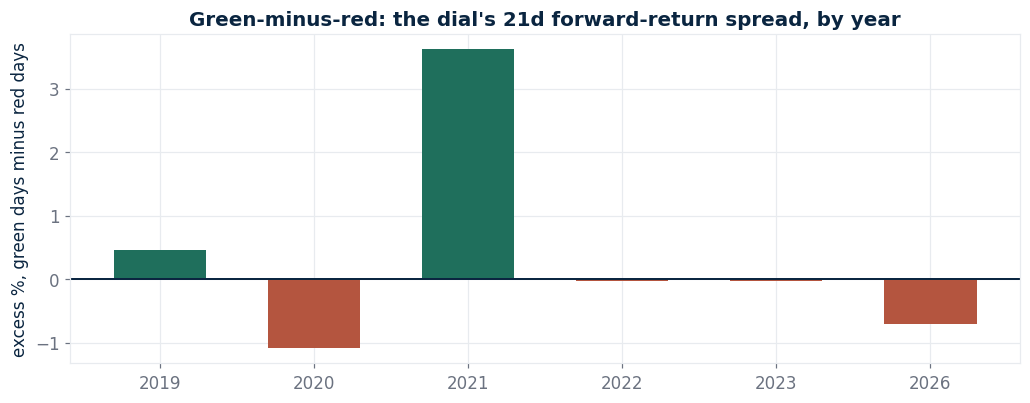

In [65]:
if len(DL):
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    ax.bar([str(k) for k in SPREAD], list(SPREAD.values()),
           color=[GREEN if v > 0 else RED for v in SPREAD.values()],
           width=0.6)
    ax.axhline(0, color=NAVY, lw=1.3)
    ax.set_title("Green-minus-red: the dial's 21d forward-return spread, "
                 "by year")
    ax.set_ylabel("excess %, green days minus red days")
    fig.tight_layout()
    plt.show()

**The tilt is real and it is honest to say so — with its year table
on the same line.** Pooled, green days beat red days at every horizon
(+0.6% over 21d, +1.0% over 42d). But the year table shows where that
lives: the 2021 mania supplies nearly all of it, 2020 and 2026 flip
negative, and the rest sit at zero. The dial's green is a genuine
tailwind READING, not a harvestable rule — which is exactly the
"trend context, not a trigger" label it already carries.

## 11.3 Crossings as triggers, judged like everything else

The direct answer to *"use crossings to determine get in / get out
instead — if its better, suggest it"*: fire a GET IN on every upward
crossing and a GET OUT on every downward one (several shapes: zero
and ±0.25 levels, with and without a 5-day hold), and judge the
alerts with the SAME episode judge and the SAME yardsticks as the
shipped pair, on the same 2019+ dial-covered universe.

In [66]:
if len(DL):
    from analytics.euphoria_phases import (classify_onset_alerts,
                                           classify_top_alerts)

    def _judge11(alerts_by, mode):
        eps_by = dict(tuple(episodes.groupby("name")))
        empty = episodes.iloc[0:0]
        jf = (classify_onset_alerts if mode == "onset"
              else classify_top_alerts)
        captured, fa, leads = set(), [], []
        for nm, alerts in alerts_by.items():
            days = np.asarray(sorted(np.datetime64(a, "D").astype(np.int64)
                                     for a in alerts), dtype=np.int64)
            res = jf(days, _eps_arrays(eps_by.get(nm, empty)))
            captured |= {(nm, p) for p in res["captured"]}
            fa += res["fa"]
            leads += [list(x.values())[-1] for x in res["leads"]
                      if isinstance(x, dict)]
        det_col = ("onset_detectable" if mode == "onset"
                   else "top_detectable")
        det = episodes[(episodes.year >= 2019) & episodes[det_col]
                       & episodes["name"].isin(DL["name"].unique())]
        det_keys = {(r.name, int(p)) for r, p in
                    zip(det.itertuples(), _day_ints(det["peak"]))}
        hits = len(captured & det_keys)
        return {"alerts": sum(len(v) for v in alerts_by.values()),
                "captured": hits, "detectable": len(det_keys),
                "false_alarms": len(fa), "utility": hits - len(fa),
                "median_lead": float(np.median(leads)) if leads else None}

    from analytics.euphoria_phases import _eps_arrays, _day_ints
    XR = []
    for tag, lvl, cf in (("zero-cross", 0.0, 0),
                         ("zero-cross, 5d hold", 0.0, 5),
                         ("±0.25 cross, 5d hold", 0.25, 5)):
        for direction, mode, side in ((+1, "onset", "GET IN"),
                                      (-1, "top", "GET OUT")):
            r = _judge11(dial_crossings("retail_flow_disp", direction,
                                        confirm=cf, level=lvl), mode)
            XR.append({"trigger": f"dial {tag}", "side": side, **r})
    for lab, col, mode, side in (
            ("shipped ungated", "get_in_nogate_strict", "onset", "GET IN"),
            ("shipped gated", "get_in_strict", "onset", "GET IN"),
            ("shipped", "get_out_strict", "top", "GET OUT")):
        if col not in DK8.columns:
            continue
        al = {nm: [d for d in g.loc[g[col].astype(bool), "date"]
                   if d.year >= 2019] for nm, g in DK8.groupby("name")}
        XR.append({"trigger": lab, "side": side, **_judge11(al, mode)})
    XR = pd.DataFrame(XR)
    print(XR.to_string(index=False))
    RESULTS11["crossings_judged"] = XR.to_dict("records")

                  trigger    side  alerts  captured  detectable  false_alarms  utility  median_lead
          dial zero-cross  GET IN     387        36         171           300     -264         75.0
          dial zero-cross GET OUT     392        40         184           332     -292         15.0
 dial zero-cross, 5d hold  GET IN     366        38         171           279     -241         69.5
 dial zero-cross, 5d hold GET OUT     362        42         184           308     -266         16.0
dial ±0.25 cross, 5d hold  GET IN     352        34         171           276     -242         75.0
dial ±0.25 cross, 5d hold GET OUT     333        42         184           274     -232         12.5
          shipped ungated  GET IN      23        13         171             8        5         59.0
            shipped gated  GET IN      12         5         171             7       -2         23.0
                  shipped GET OUT      95        35         184            54      -19          5.0


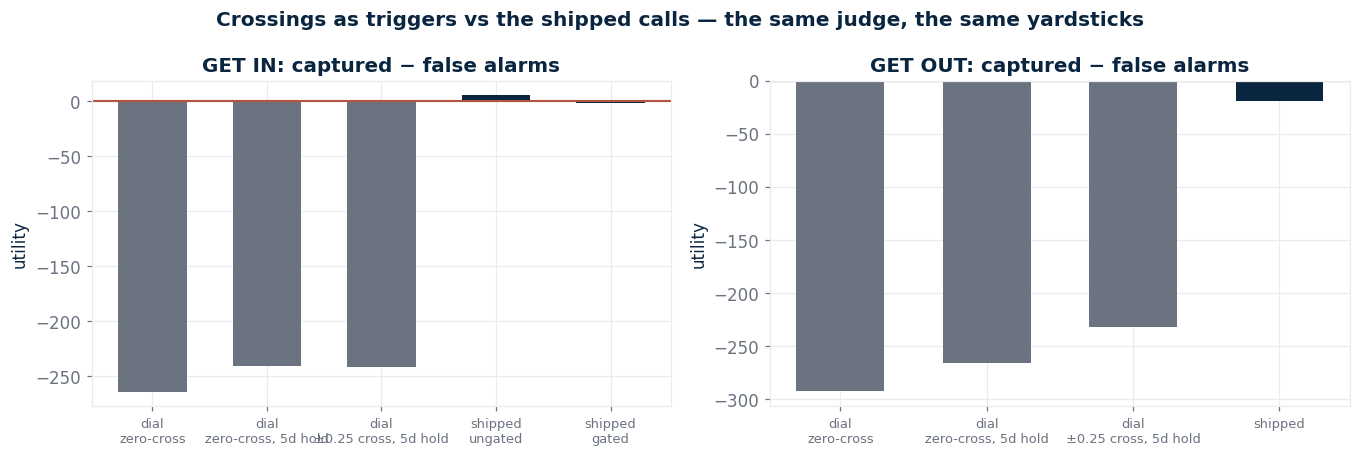

In [67]:
if len(DL):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=False)
    for ax, side in zip(axes, ("GET IN", "GET OUT")):
        sub = XR[XR["side"] == side]
        ax.bar(range(len(sub)), sub["utility"],
               color=[GREY if "dial" in t else NAVY
                      for t in sub["trigger"]], width=0.6)
        ax.axhline(0, color=RED, lw=1.4)
        ax.set_xticks(range(len(sub)),
                      [t.replace("dial ", "dial\n").replace("shipped ",
                                                            "shipped\n")
                       for t in sub["trigger"]], fontsize=8.5)
        ax.set_title(f"{side}: captured − false alarms")
        ax.set_ylabel("utility")
    fig.suptitle("Crossings as triggers vs the shipped calls — the same "
                 "judge, the same yardsticks", fontweight="bold")
    fig.tight_layout()
    plt.show()

**Crossings as triggers are REJECTED, and the margin is not close.**
Every crossing shape fires three to four HUNDRED alerts a side where
the shipped pair fires tens; they do capture a few more episodes
(~40 vs ~35 for GET OUT, ~37 vs ~13 for GET IN) but at seven to
thirty times the false alarms, for utilities near −250 against the
shipped −19 / +5. The mechanism is §9's own finding wearing trigger
clothes: the dial is a SMOOTHED TIDE — it wanders through zero on
every mid-sized wobble, and a smoothed line's crossings inherit every
wobble as an alert. The shipped calls stay; the dial stays context.

Worth keeping from the question: the GET IN crossings' median lead of
~70 days says the dial's turn genuinely comes EARLY in a build - far
too early to trade, exactly early enough to be the watch-context the
§10.5 band already provides.

## 11.4 The combined band — calls, readiness and dial in ONE chart

The display request, adopted: one panel under each price chart with
**the signed readiness as the green/red fill** (how close the live
side stands to its cut - the thing that says when a signal will
fire), **the retail-flow dial as a dark line over it** (the slow tide
- and a LINE stays legible near zero, which fixes the visibility
complaint directly), and **the fired calls as markers on the band
itself**. Mocked here on two names; the dashboard change ships with
this section.

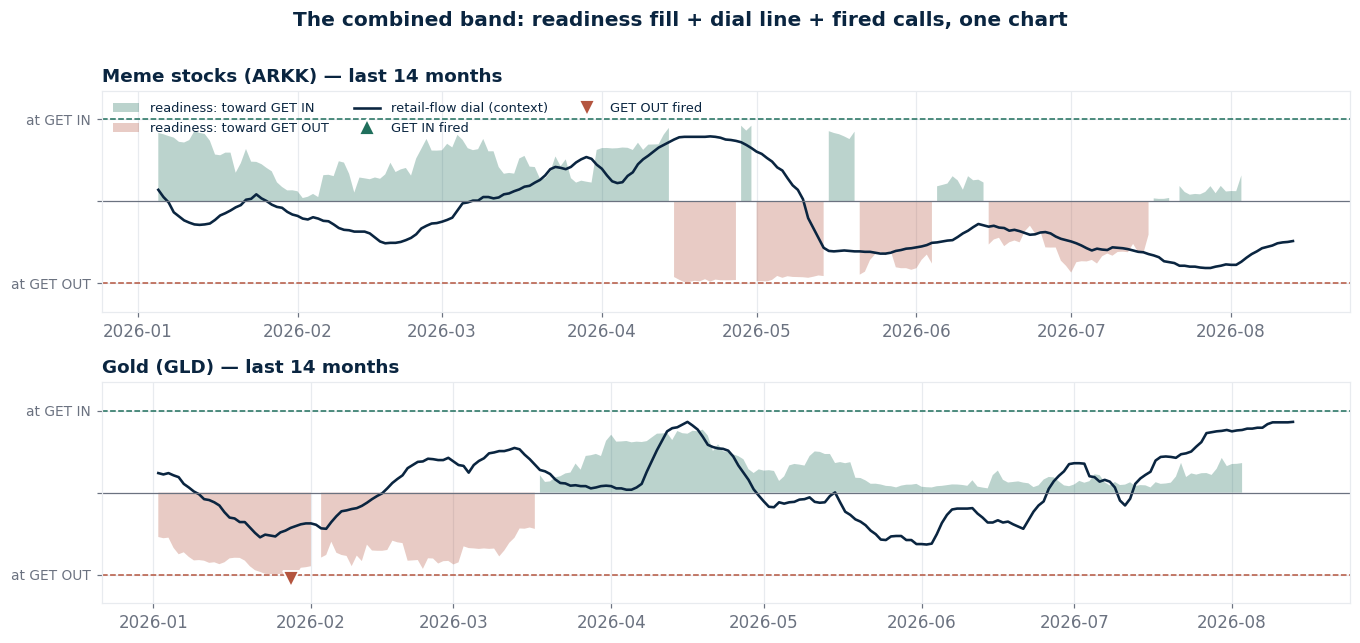

In [68]:
if len(DL):
    _mock = [("meme_stocks", "Meme stocks (ARKK)"),
             ("gold_metals", "Gold (GLD)")]
    fig, axes = plt.subplots(len(_mock), 1, figsize=(12.5, 2.9 * len(_mock)))
    for ax, (nm, nice) in zip(np.atleast_1d(axes), _mock):
        g = DK8[DK8["name"] == nm].sort_values("date").set_index("date")
        g = g.loc[g.index >= g.index.max() - pd.Timedelta(days=420)]
        sr = pd.Series(np.where(g["boomed120"].fillna(False).astype(bool),
                                -(g["out_score"] / _thr_out10),
                                g["in_score"] / _thr_in10),
                       index=g.index).clip(-1.15, 1.15)
        sr = sr[g["in_score"].notna() & g["out_score"].notna()]
        sr = sr.reindex(pd.date_range(sr.index.min(), sr.index.max()))
        ax.fill_between(sr.index, 0, sr.values,
                        where=(sr.values >= 0), color=GREEN, alpha=0.30,
                        lw=0, label="readiness: toward GET IN")
        ax.fill_between(sr.index, 0, sr.values,
                        where=(sr.values < 0), color=RED, alpha=0.30,
                        lw=0, label="readiness: toward GET OUT")
        fl = g["retail_flow_disp"].dropna()
        fl = fl.reindex(pd.date_range(fl.index.min(), fl.index.max())) \
            if len(fl) else fl
        ax.plot(fl.index, fl.values, color=NAVY, lw=1.7,
                label="retail-flow dial (context)")
        ax.axhline(1.0, color=GREEN, lw=1.0, ls="--")
        ax.axhline(-1.0, color=RED, lw=1.0, ls="--")
        ax.axhline(0, color=GREY, lw=0.8)
        for col, mk, cc, yy in (("get_in_nogate_strict"
                                 if "get_in_nogate_strict" in g else
                                 "get_in_strict", "^", GREEN, 1.05),
                                ("get_out_strict", "v", RED, -1.05)):
            dd = g.index[g[col].astype(bool)]
            dd = dd[(dd >= sr.index.min()) & (dd <= sr.index.max())]
            ax.plot(dd, [yy] * len(dd), mk, color=cc, ms=10, mec="white",
                    mew=1.2, zorder=5,
                    label=("GET IN fired" if yy > 0 else "GET OUT fired"))
        ax.set_ylim(-1.35, 1.35)
        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels(["at GET OUT", "", "at GET IN"], fontsize=9)
        ax.set_title(nice + " — last 14 months", loc="left", fontsize=12)
        if ax is np.atleast_1d(axes)[0]:
            ax.legend(frameon=False, ncol=3, fontsize=8.5,
                      loc="upper left")
    fig.suptitle("The combined band: readiness fill + dial line + fired "
                 "calls, one chart", fontweight="bold", y=1.002)
    fig.tight_layout()
    plt.show()

## 11.5 Verdict

| | verdict | why |
|---|---|---|
| Crossings as GET IN / GET OUT triggers | **REJECT** | §11.3: 7–30× the false alarms of the shipped calls, utility ~−250 vs −19/+5 — a smoothed tide's crossings inherit every wobble |
| The eye's crossing↔call correlation | **MOSTLY SELECTION** | §11.1: one GET IN in six has a crossing within ±21d; the median crossing TRAILS the call by ~2 weeks |
| Green→rises / red→falls | **REAL BUT 2021-SHAPED** | §11.2: pooled +0.6%/21d green-minus-red, almost all of it from the mania year; keep as context, not a rule |
| Combined band (fill + line + markers) | **ADOPT (display)** | §11.4: one chart answers "how close, which way, and what fired" — and the dial-as-line fixes the near-zero visibility complaint |

**What §11 does NOT claim.** Not that the dial is useless — §9's
lead–lag stands; the dial turns early, which is precisely why its
crossings over-fire as triggers. Not that the green tilt is noise —
it is measured, pooled, and honestly attributed to 2021. And as
everywhere in this notebook: re-run after the backfill.

In [69]:
if len(DL):
    RESULTS11["built"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC")
    with open(os.path.join(OUT, "nb08_crossings.json"), "w",
              encoding="utf-8") as fh:
        json.dump(RESULTS11, fh, indent=1, default=str)
    print(f"wrote {OUT}/nb08_crossings.json · §11 total "
          f"{time.time() - t11:.0f}s")

wrote docs/research/nb08_crossings.json · §11 total 4s
